In [206]:
import pandas as pd
from pathlib import Path

In [207]:
BASE_DIR = Path("..")

CVM_DIR = BASE_DIR / "data" / "raw" / "cvm" / "dfp"
PROCESSED_DIR = BASE_DIR / "data" / "processed"

print("CVM:", CVM_DIR)
print("Processed:", PROCESSED_DIR)

CVM: ..\data\raw\cvm\dfp
Processed: ..\data\processed


In [208]:
anos = sorted(
    [
        p.name
        for p in CVM_DIR.iterdir()
        if p.is_dir() and p.name.isdigit()
    ]
)

print("Anos disponíveis:", anos)

Anos disponíveis: ['2024', '2025']


In [209]:
for ano in anos:
    pasta_ano = CVM_DIR / ano

    arquivos = {
        "DRE": list(pasta_ano.glob("*DRE_con*.csv")),
        "BPP": list(pasta_ano.glob("*BPP_con*.csv")),
        "DFC": list(pasta_ano.glob("*DFC_MD_con*.csv")),
    }

    print(f"\n{ano}")
    
    for tipo, caminhos in arquivos.items():
        print(f"{tipo}:")
        for caminho in caminhos:
            print("  ", caminho.name)


2024
DRE:
   dfp_cia_aberta_DRE_con_2024.csv
BPP:
   dfp_cia_aberta_BPP_con_2024.csv
DFC:
   dfp_cia_aberta_DFC_MD_con_2024.csv

2025
DRE:
   dfp_cia_aberta_DRE_con_2025.csv
BPP:
   dfp_cia_aberta_BPP_con_2025.csv
DFC:
   dfp_cia_aberta_DFC_MD_con_2025.csv


In [210]:
dados_cvm = {}

for ano in anos:
    pasta_ano = CVM_DIR / ano

    arquivos_dre = list(pasta_ano.glob("*DRE_con*.csv"))
    arquivos_bpp = list(pasta_ano.glob("*BPP_con*.csv"))
    arquivos_dfc = list(pasta_ano.glob("*DFC_MD_con*.csv"))

    if not arquivos_dre or not arquivos_bpp or not arquivos_dfc:
        print(f"{ano} - arquivos incompletos. Pulando.")
        continue

    dre = pd.read_csv(
        arquivos_dre[0],
        sep=";",
        encoding="latin1"
    )

    bpp = pd.read_csv(
        arquivos_bpp[0],
        sep=";",
        encoding="latin1"
    )

    dfc = pd.read_csv(
        arquivos_dfc[0],
        sep=";",
        encoding="latin1"
    )

    dados_cvm[ano] = {
        "dre": dre,
        "bpp": bpp,
        "dfc": dfc
    }

    print(
        ano,
        "-",
        "DRE:", dre.shape,
        "| BPP:", bpp.shape,
        "| DFC:", dfc.shape
    )

2024 - DRE: (32776, 15) | BPP: (107116, 14) | DFC: (656, 15)
2025 - DRE: (30786, 15) | BPP: (101380, 14) | DFC: (504, 15)


In [211]:
anos_carregados = sorted(dados_cvm.keys())

dre = pd.concat(
    [dados_cvm[ano]["dre"] for ano in anos_carregados],
    ignore_index=True
)

bpp = pd.concat(
    [dados_cvm[ano]["bpp"] for ano in anos_carregados],
    ignore_index=True
)

dfc = pd.concat(
    [dados_cvm[ano]["dfc"] for ano in anos_carregados],
    ignore_index=True
)

print("DRE:", dre.shape)
print("BPP:", bpp.shape)
print("DFC:", dfc.shape)

DRE: (63562, 15)
BPP: (208496, 14)
DFC: (1160, 15)


In [212]:
contas_dre = {
    "receita": "3.01",
    "resultado_bruto": "3.03",
    "ebit": "3.05",
    "resultado_financeiro": "3.06",
    "lucro_antes_tributos": "3.07",
    "lucro_liquido": "3.11"
}

contas_bpp = {
    "divida_curto_prazo": "2.01.04",
    "divida_longo_prazo": "2.02.01",
    "patrimonio_liquido": "2.03",
    "caixa": "1.01.01"
}

contas_dfc = {
    "cfo": "6.01",
    "capex": "6.02.04",
    "depreciacao_amortizacao": "6.01.01.02"
}

print("DRE:", contas_dre)
print("BPP:", contas_bpp)
print("DFC:", contas_dfc)

DRE: {'receita': '3.01', 'resultado_bruto': '3.03', 'ebit': '3.05', 'resultado_financeiro': '3.06', 'lucro_antes_tributos': '3.07', 'lucro_liquido': '3.11'}
BPP: {'divida_curto_prazo': '2.01.04', 'divida_longo_prazo': '2.02.01', 'patrimonio_liquido': '2.03', 'caixa': '1.01.01'}
DFC: {'cfo': '6.01', 'capex': '6.02.04', 'depreciacao_amortizacao': '6.01.01.02'}


In [213]:
chaves_duplicata = [
    "CNPJ_CIA",
    "DT_FIM_EXERC",
    "CD_CONTA",
    "ORDEM_EXERC",
    "VL_CONTA"
]

for nome in ["dre", "bpp", "dfc"]:
    df = globals()[nome]

    globals()[nome] = (
        df
        .drop_duplicates(subset=chaves_duplicata)
        .copy()
    )

print("DRE:", dre.shape)
print("BPP:", bpp.shape)
print("DFC:", dfc.shape)

DRE: (63224, 15)
BPP: (207304, 14)
DFC: (1160, 15)


In [214]:
dre_base = dre[
    dre["CD_CONTA"].isin(contas_dre.values())
].copy()

dre_base = dre_base[
    [
        "CNPJ_CIA",
        "DENOM_CIA",
        "DT_FIM_EXERC",
        "CD_CONTA",
        "VL_CONTA"
    ]
].copy()

dre_base["indicador"] = dre_base["CD_CONTA"].map(
    {v: k for k, v in contas_dre.items()}
)

print(dre_base.shape)
print(dre_base["indicador"].value_counts())

(10826, 6)
indicador
receita                 1808
resultado_bruto         1808
ebit                    1808
resultado_financeiro    1808
lucro_antes_tributos    1808
lucro_liquido           1786
Name: count, dtype: int64


In [215]:
bpp_base = bpp[
    bpp["CD_CONTA"].isin(contas_bpp.values())
].copy()

bpp_base = bpp_base[
    [
        "CNPJ_CIA",
        "DENOM_CIA",
        "DT_FIM_EXERC",
        "CD_CONTA",
        "VL_CONTA"
    ]
].copy()

bpp_base["indicador"] = bpp_base["CD_CONTA"].map(
    {v: k for k, v in contas_bpp.items()}
)

print(bpp_base.shape)
print(bpp_base["indicador"].value_counts())

(5350, 6)
indicador
patrimonio_liquido    1808
divida_longo_prazo    1790
divida_curto_prazo    1752
Name: count, dtype: int64


In [216]:
bpa = pd.concat(
    [
        pd.read_csv(
            list((CVM_DIR / ano).glob("*BPA_con*.csv"))[0],
            sep=";",
            encoding="latin1"
        )
        for ano in anos
    ],
    ignore_index=True
)

print("BPA:", bpa.shape)

BPA: (121942, 14)


In [217]:
caixa_contas = bpa[
    bpa["DS_CONTA"].str.contains(
        "Caixa",
        case=False,
        na=False
    )
][
    ["CD_CONTA", "DS_CONTA"]
].drop_duplicates()

print(caixa_contas.to_string(index=False))

     CD_CONTA                                                DS_CONTA
         1.01                           Caixa e Equivalentes de Caixa
      1.01.01                                                   Caixa
      1.01.01                           Caixa e Equivalentes de Caixa
   1.01.01.01                                                   Caixa
   1.01.01.02                                          Caixa Restrito
1.02.01.10.03                                          Caixa restrito
1.02.01.10.14                                          Caixa Restrito
   1.01.01.01                           Caixa e Equivalentes de Caixa
1.01.02.01.03                                          Caixa Restrito
   1.01.01.01                                           Caixa E Banco
1.01.08.03.06                                          Caixa Restrito
1.02.01.10.09                                          Caixa Restrito
1.02.01.10.08                                          Caixa Restrito
1.02.01.10.06       

In [218]:
caixa_base = bpa[
    bpa["CD_CONTA"].eq("1.01")
].copy()

caixa_base = caixa_base[
    [
        "CNPJ_CIA",
        "DENOM_CIA",
        "DT_FIM_EXERC",
        "CD_CONTA",
        "VL_CONTA"
    ]
].copy()

caixa_base["indicador"] = "caixa"

print(caixa_base.shape)
print(caixa_base.head())


(1818, 6)
               CNPJ_CIA                   DENOM_CIA DT_FIM_EXERC CD_CONTA  \
2    00.000.000/0001-91             BCO BRASIL S.A.   2023-12-31     1.01   
3    00.000.000/0001-91             BCO BRASIL S.A.   2024-12-31     1.01   
84   00.000.208/0001-00  BRB BANCO DE BRASILIA S.A.   2023-12-31     1.01   
85   00.000.208/0001-00  BRB BANCO DE BRASILIA S.A.   2024-12-31     1.01   
166  00.001.180/0001-26           AXIA ENERGIA S.A.   2023-12-31     1.01   

       VL_CONTA indicador  
2    56999814.0     caixa  
3    83167243.0     caixa  
84     201195.0     caixa  
85    2029253.0     caixa  
166  48022312.0     caixa  


In [219]:
for df in [dre_base, bpp_base, caixa_base]:
    df["DT_FIM_EXERC"] = pd.to_datetime(df["DT_FIM_EXERC"])

dre_base = dre_base[
    dre_base["DT_FIM_EXERC"].dt.year.isin([2024, 2025])
].copy()

bpp_base = bpp_base[
    bpp_base["DT_FIM_EXERC"].dt.year.isin([2024, 2025])
].copy()

caixa_base = caixa_base[
    caixa_base["DT_FIM_EXERC"].dt.year.isin([2024, 2025])
].copy()

print("DRE anos:", sorted(dre_base["DT_FIM_EXERC"].dt.year.unique()))
print("BPP anos:", sorted(bpp_base["DT_FIM_EXERC"].dt.year.unique()))
print("Caixa anos:", sorted(caixa_base["DT_FIM_EXERC"].dt.year.unique()))

DRE anos: [np.int32(2024), np.int32(2025)]
BPP anos: [np.int32(2024), np.int32(2025)]
Caixa anos: [np.int32(2024), np.int32(2025)]


In [220]:
dfc_base = dfc[
    dfc["CD_CONTA"].isin(["6.01", "6.02.04", "6.01.02"])
].copy()

dfc_base = dfc_base[
    [
        "CNPJ_CIA",
        "DENOM_CIA",
        "DT_FIM_EXERC",
        "CD_CONTA",
        "DS_CONTA",
        "VL_CONTA"
    ]
].copy()

dfc_base["indicador"] = dfc_base["CD_CONTA"].map({
    "6.01": "cfo",
    "6.02.04": "capex",
    "6.01.02": "depreciacao_amortizacao"
})

dfc_base["DT_FIM_EXERC"] = pd.to_datetime(
    dfc_base["DT_FIM_EXERC"]
)

dfc_base = dfc_base[
    dfc_base["DT_FIM_EXERC"].dt.year.isin([2024, 2025])
].copy()

print(dfc_base.shape)
print(dfc_base["indicador"].value_counts())

(79, 7)
indicador
cfo                        42
depreciacao_amortizacao    23
capex                      14
Name: count, dtype: int64


In [221]:
dre_wide = (
    dre_base
    .pivot_table(
        index=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        columns="indicador",
        values="VL_CONTA",
        aggfunc="first"
    )
    .reset_index()
)

print(dre_wide.shape)
print(dre_wide.head())

(914, 9)
indicador            CNPJ_CIA                   DENOM_CIA DT_FIM_EXERC  \
0          00.000.000/0001-91             BCO BRASIL S.A.   2024-12-31   
1          00.000.000/0001-91             BCO BRASIL S.A.   2025-12-31   
2          00.000.208/0001-00  BRB BANCO DE BRASILIA S.A.   2024-12-31   
3          00.001.180/0001-26           AXIA ENERGIA S.A.   2024-12-31   
4          00.001.180/0001-26           AXIA ENERGIA S.A.   2025-12-31   

indicador        ebit  lucro_antes_tributos  lucro_liquido      receita  \
0          27710589.0            29171564.0     29171564.0  273505274.0   
1           5613636.0            16781938.0     16781938.0  319462104.0   
2            410000.0              311019.0       311019.0    8909356.0   
3          22248904.0            10620783.0     10380753.0   40181552.0   
4           3946582.0            -6979948.0      6559659.0   41281596.0   

indicador  resultado_bruto  resultado_financeiro  
0              104514447.0             14609

In [222]:
bpp_wide = (
    bpp_base
    .pivot_table(
        index=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        columns="indicador",
        values="VL_CONTA",
        aggfunc="first"
    )
    .reset_index()
)

print(bpp_wide.shape)
print(bpp_wide.head())

(914, 6)
indicador            CNPJ_CIA                   DENOM_CIA DT_FIM_EXERC  \
0          00.000.000/0001-91             BCO BRASIL S.A.   2024-12-31   
1          00.000.000/0001-91             BCO BRASIL S.A.   2025-12-31   
2          00.000.208/0001-00  BRB BANCO DE BRASILIA S.A.   2024-12-31   
3          00.001.180/0001-26           AXIA ENERGIA S.A.   2024-12-31   
4          00.001.180/0001-26           AXIA ENERGIA S.A.   2025-12-31   

indicador  divida_curto_prazo  divida_longo_prazo  patrimonio_liquido  
0                         NaN         873710691.0          26099013.0  
1                         NaN         897937449.0          38689885.0  
2                         NaN          40610625.0            787558.0  
3                  12836733.0          62966424.0         121999776.0  
4                  13204168.0          61091597.0         118501657.0  


In [223]:
caixa_wide = (
    caixa_base
    .pivot_table(
        index=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        columns="indicador",
        values="VL_CONTA",
        aggfunc="first"
    )
    .reset_index()
)

print(caixa_wide.shape)
print(caixa_wide.head())

(914, 4)
indicador            CNPJ_CIA                   DENOM_CIA DT_FIM_EXERC  \
0          00.000.000/0001-91             BCO BRASIL S.A.   2024-12-31   
1          00.000.000/0001-91             BCO BRASIL S.A.   2025-12-31   
2          00.000.208/0001-00  BRB BANCO DE BRASILIA S.A.   2024-12-31   
3          00.001.180/0001-26           AXIA ENERGIA S.A.   2024-12-31   
4          00.001.180/0001-26           AXIA ENERGIA S.A.   2025-12-31   

indicador       caixa  
0          83167243.0  
1          59635525.0  
2           2029253.0  
3          64451102.0  
4          52090586.0  


In [224]:
dfc_wide = (
    dfc_base
    .pivot_table(
        index=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        columns="indicador",
        values="VL_CONTA",
        aggfunc="first"
    )
    .reset_index()
)

print(dfc_wide.shape)
print(dfc_wide.head())

(31, 6)
indicador            CNPJ_CIA                               DENOM_CIA  \
0          00.000.208/0001-00              BRB BANCO DE BRASILIA S.A.   
1          00.070.698/0001-11  COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB   
2          00.070.698/0001-11  COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB   
3          02.201.787/0001-85         CEL PARTICIPAÇÕES S.A. - CELPAR   
4          02.201.787/0001-85         CEL PARTICIPAÇÕES S.A. - CELPAR   

indicador DT_FIM_EXERC  capex        cfo  depreciacao_amortizacao  
0           2024-12-31    NaN  1476678.0                      NaN  
1           2024-12-31    0.0   236752.0                 -79895.0  
2           2025-12-31    0.0   139551.0                -174404.0  
3           2024-12-31    NaN     7538.0                      NaN  
4           2025-12-31    NaN   446543.0                      NaN  


In [225]:
fundamentals = (
    dre_wide
    .merge(
        bpp_wide,
        on=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        how="left"
    )
    .merge(
        caixa_wide,
        on=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        how="left"
    )
    .merge(
        dfc_wide,
        on=["CNPJ_CIA", "DENOM_CIA", "DT_FIM_EXERC"],
        how="left"
    )
)

print("Formato:", fundamentals.shape)
print("\nColunas:")
print(fundamentals.columns.tolist())

print("\nPrimeiras linhas:")
print(fundamentals.head())

Formato: (914, 16)

Colunas:
['CNPJ_CIA', 'DENOM_CIA', 'DT_FIM_EXERC', 'ebit', 'lucro_antes_tributos', 'lucro_liquido', 'receita', 'resultado_bruto', 'resultado_financeiro', 'divida_curto_prazo', 'divida_longo_prazo', 'patrimonio_liquido', 'caixa', 'capex', 'cfo', 'depreciacao_amortizacao']

Primeiras linhas:
indicador            CNPJ_CIA                   DENOM_CIA DT_FIM_EXERC  \
0          00.000.000/0001-91             BCO BRASIL S.A.   2024-12-31   
1          00.000.000/0001-91             BCO BRASIL S.A.   2025-12-31   
2          00.000.208/0001-00  BRB BANCO DE BRASILIA S.A.   2024-12-31   
3          00.001.180/0001-26           AXIA ENERGIA S.A.   2024-12-31   
4          00.001.180/0001-26           AXIA ENERGIA S.A.   2025-12-31   

indicador        ebit  lucro_antes_tributos  lucro_liquido      receita  \
0          27710589.0            29171564.0     29171564.0  273505274.0   
1           5613636.0            16781938.0     16781938.0  319462104.0   
2            410000

In [226]:
fundamentals["margem_ebit"] = (
    fundamentals["ebit"] / fundamentals["receita"]
)

fundamentals["margem_liquida"] = (
    fundamentals["lucro_liquido"] / fundamentals["receita"]
)

fundamentals["roe"] = (
    fundamentals["lucro_liquido"] / fundamentals["patrimonio_liquido"]
)

fundamentals["divida_total"] = (
    fundamentals["divida_curto_prazo"].fillna(0)
    + fundamentals["divida_longo_prazo"].fillna(0)
)

fundamentals["divida_liquida"] = (
    fundamentals["divida_total"]
    - fundamentals["caixa"]
)

fundamentals["divida_liquida_pl"] = (
    fundamentals["divida_liquida"]
    / fundamentals["patrimonio_liquido"]
)

print(
    fundamentals[
        [
            "DENOM_CIA",
            "DT_FIM_EXERC",
            "margem_ebit",
            "margem_liquida",
            "roe",
            "divida_liquida_pl"
        ]
    ].head(10)
)

indicador                               DENOM_CIA DT_FIM_EXERC  margem_ebit  \
0                                 BCO BRASIL S.A.   2024-12-31     0.101316   
1                                 BCO BRASIL S.A.   2025-12-31     0.017572   
2                      BRB BANCO DE BRASILIA S.A.   2024-12-31     0.046019   
3                               AXIA ENERGIA S.A.   2024-12-31     0.553709   
4                               AXIA ENERGIA S.A.   2025-12-31     0.095601   
5          COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB   2024-12-31     0.631006   
6          COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB   2025-12-31     0.447534   
7                         CARAMURU ALIMENTOS S.A.   2024-12-31     0.095940   
8                         CARAMURU ALIMENTOS S.A.   2025-12-31     0.066507   
9                            AUREN OPERAÇÕES S.A.   2024-12-31     0.140252   

indicador  margem_liquida       roe  divida_liquida_pl  
0                0.106658  1.117727          30.290166  
1               

In [227]:
import numpy as np

indicadores = [
    "margem_ebit",
    "margem_liquida",
    "roe",
    "divida_liquida_pl"
]

fundamentals[indicadores] = (
    fundamentals[indicadores]
    .replace([np.inf, -np.inf], np.nan)
)

print(
    fundamentals[indicadores].describe()
)

indicador  margem_ebit  margem_liquida          roe  divida_liquida_pl
count       889.000000      879.000000   893.000000         902.000000
mean          0.401591      -23.866876     2.895809           0.900495
std          10.106901      506.316804    66.232484          84.230256
min         -95.005025   -10912.992462   -75.180832       -2055.657778
25%           0.051185       -0.022535     0.002115          -0.728006
50%           0.138150        0.053133     0.101244          -0.105996
75%           0.246832        0.143282     0.210179           0.588397
max         190.586207      285.344828  1876.964444        1298.563588


In [228]:
indicadores = [
    "margem_ebit",
    "margem_liquida",
    "roe",
    "divida_liquida_pl"
]

for coluna in indicadores:
    limite_inferior = fundamentals[coluna].quantile(0.01)
    limite_superior = fundamentals[coluna].quantile(0.99)

    fundamentals[coluna] = fundamentals[coluna].clip(
        lower=limite_inferior,
        upper=limite_superior
    )


In [229]:
indicadores_score = [
    "margem_ebit",
    "margem_liquida",
    "roe",
    "divida_liquida_pl"
]

for coluna in indicadores_score:
    grupo_ano = fundamentals.groupby(
        fundamentals["DT_FIM_EXERC"].dt.year
    )[coluna]

    media = grupo_ano.transform("mean")
    desvio = grupo_ano.transform("std")

    fundamentals[f"z_{coluna}"] = (
        (fundamentals[coluna] - media) / desvio
    )

# quality: media dos componentes disponiveis
fundamentals["quality_score"] = fundamentals[
    [
        "z_roe",
        "z_margem_ebit",
        "z_margem_liquida"
    ]
].mean(axis=1, skipna=True)

# leverage: menor alavancagem = melhor score
fundamentals["leverage_score"] = (
    -fundamentals["z_divida_liquida_pl"]
)

print(
    fundamentals[
        [
            "DENOM_CIA",
            "DT_FIM_EXERC",
            "quality_score",
            "leverage_score"
        ]
    ].head(10)
)

print("\nQuality score ausente:")
print(fundamentals["quality_score"].isna().sum())

print("\nLeverage score ausente:")
print(fundamentals["leverage_score"].isna().sum())

indicador                               DENOM_CIA DT_FIM_EXERC  quality_score  \
0                                 BCO BRASIL S.A.   2024-12-31       0.450305   
1                                 BCO BRASIL S.A.   2025-12-31       0.102546   
2                      BRB BANCO DE BRASILIA S.A.   2024-12-31       0.092744   
3                               AXIA ENERGIA S.A.   2024-12-31       0.359993   
4                               AXIA ENERGIA S.A.   2025-12-31       0.032744   
5          COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB   2024-12-31       0.580947   
6          COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB   2025-12-31       0.414700   
7                         CARAMURU ALIMENTOS S.A.   2024-12-31       0.012085   
8                         CARAMURU ALIMENTOS S.A.   2025-12-31       0.045332   
9                            AUREN OPERAÇÕES S.A.   2024-12-31      -0.017741   

indicador  leverage_score  
0               -4.951015  
1               -3.687116  
2               -7.57004

In [230]:
cadastro_cvm = (
    dre[
        ["CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
    ]
    .drop_duplicates("CNPJ_CIA")
    .copy()
)

print("Cadastro CVM:", cadastro_cvm.shape)

Cadastro CVM: (477, 3)


In [231]:
universe = pd.read_parquet(
    PROCESSED_DIR / "universe.parquet"
)


In [232]:
prices = pd.read_parquet(
    PROCESSED_DIR / "prices.parquet"
)

In [233]:
import re
import unicodedata

def normalizar_nome(nome):
    if pd.isna(nome):
        return None

    nome = str(nome).upper().strip()

    # remove acentos
    nome = unicodedata.normalize("NFKD", nome)
    nome = "".join(
        c for c in nome
        if not unicodedata.combining(c)
    )

    # padroniza simbolos
    nome = re.sub(r"[^A-Z0-9 ]", " ", nome)

    # remove tipos societários comuns
    nome = re.sub(
        r"\b(SA|S A|S/A|S\.A|S\.A\.|LTDA|LIMITADA|"
        r"COMPANHIA|CIA|HOLDING|HOLDINGS)\b",
        " ",
        nome
    )

    # remove espaços duplicados
    nome = re.sub(r"\s+", " ", nome).strip()

    return nome


ibrx_temp = universe.copy()
fund_temp = fundamentals.copy()

ibrx_temp["nome_normalizado"] = (
    ibrx_temp["name"].apply(normalizar_nome)
)

fund_temp["nome_normalizado"] = (
    fund_temp["DENOM_CIA"].apply(normalizar_nome)
)

In [234]:
fundamentals = fundamentals.merge(
    cadastro_cvm[["CNPJ_CIA", "CD_CVM"]],
    on="CNPJ_CIA",
    how="left",
    validate="many_to_one"
)

In [235]:
universe_tickers = (
    universe[["ticker", "name"]]
    .drop_duplicates("ticker")
    .sort_values("ticker")
    .reset_index(drop=True)
)

In [236]:
import re
import unicodedata


def normalizar_nome(nome):
    if pd.isna(nome):
        return ""

    nome = str(nome).upper().strip()

    # remove acentos
    nome = unicodedata.normalize("NFKD", nome)
    nome = "".join(
        c for c in nome
        if not unicodedata.combining(c)
    )

    # Padroniza termos societários
    nome = re.sub(r"\bS\.?A\.?\b", "", nome)
    nome = re.sub(r"\bS/?A\b", "", nome)
    nome = re.sub(r"\bSA\b", "", nome)
    nome = re.sub(r"\bON\b", "", nome)
    nome = re.sub(r"\bPN\b", "", nome)

    # Remove pontuação
    nome = re.sub(r"[^A-Z0-9 ]", " ", nome)

    # Remove espaços duplicados
    nome = re.sub(r"\s+", " ", nome).strip()

    return nome


universe_tickers["nome_normalizado"] = (
    universe_tickers["name"].apply(normalizar_nome)
)

cadastro_cvm["nome_normalizado"] = (
    cadastro_cvm["DENOM_CIA"].apply(normalizar_nome)
)


matches_nome = universe_tickers.merge(
    cadastro_cvm[
        ["CNPJ_CIA", "DENOM_CIA", "CD_CVM", "nome_normalizado"]
    ],
    on="nome_normalizado",
    how="inner"
)


print("Matches por nome normalizado:", len(matches_nome))

Matches por nome normalizado: 40


In [237]:
# tickers sem correspondencia no cadastro CVM

tickers_match = matches_nome["ticker"].unique()

sem_match = (
    universe_tickers[
        ~universe_tickers["ticker"].isin(tickers_match)
    ][
        ["ticker", "name"]
    ]
    .sort_values("ticker")
    .reset_index(drop=True)
)

print(f"Empresas sem match: {len(sem_match)}")
display(sem_match)

Empresas sem match: 84


,ticker,name
0,AMBP3,AMBIPAR
1,AMOB3,AUTOMOB
2,ANIM3,ANIMA
3,ASAI3,ASSAI
4,AUAU3,PETZCOBASI
...,...,...
79,VAMO3,VAMOS
80,VBBR3,VIBRA
81,VIVA3,VIVARA S.A.
82,VIVT3,TELEF BRASIL


In [238]:
# tickers sem correspondencia com a CVM

tickers_com_match = matches_nome["ticker"].unique()

tickers_sem_match = (
    universe_tickers[
        ~universe_tickers["ticker"].isin(tickers_com_match)
    ]
    .sort_values("ticker")
    .reset_index(drop=True)
)

print(f"Tickers com match: {len(tickers_com_match)}")
print(f"Tickers sem match: {len(tickers_sem_match)}")

display(tickers_sem_match)

Tickers com match: 40
Tickers sem match: 84


,ticker,name,nome_normalizado
0,AMBP3,AMBIPAR,AMBIPAR
1,AMOB3,AUTOMOB,AUTOMOB
2,ANIM3,ANIMA,ANIMA
3,ASAI3,ASSAI,ASSAI
4,AUAU3,PETZCOBASI,PETZCOBASI
...,...,...,...
79,VAMO3,VAMOS,VAMOS
80,VBBR3,VIBRA,VIBRA
81,VIVA3,VIVARA S.A.,VIVARA
82,VIVT3,TELEF BRASIL,TELEF BRASIL


In [239]:
restantes = tickers_sem_match.copy()

restantes["nome_normalizado"] = (
    restantes["name"].apply(normalizar_nome)
)

cadastro_cvm_temp = cadastro_cvm.copy()

cadastro_cvm_temp["nome_normalizado"] = (
    cadastro_cvm_temp["DENOM_CIA"].apply(normalizar_nome)
)

candidatos_nome = restantes.merge(
    cadastro_cvm_temp,
    on="nome_normalizado",
    how="left"
)

display(
    candidatos_nome[
        ["ticker", "name", "CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
    ].head(30)
)

,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,AMBP3,AMBIPAR,NaN,NaN,NaN
1,AMOB3,AUTOMOB,NaN,NaN,NaN
2,ANIM3,ANIMA,NaN,NaN,NaN
3,ASAI3,ASSAI,NaN,NaN,NaN
4,AUAU3,PETZCOBASI,NaN,NaN,NaN
5,AURE3,AUREN,NaN,NaN,NaN
6,B3SA3,B3,NaN,NaN,NaN
7,BBAS3,BRASIL,NaN,NaN,NaN
8,BBDC3,BRADESCO,NaN,NaN,NaN
9,BBDC4,BRADESCO,NaN,NaN,NaN


In [240]:
def encontrar_candidatos(nome_ticker, cadastro):
    nome = normalizar_nome(nome_ticker)

    candidatos = cadastro[
        cadastro["nome_normalizado"].apply(
            lambda x: nome in x or x in nome
        )
    ].copy()

    return candidatos[
        ["CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
    ]


candidatos_parciais = []

for _, row in tickers_sem_match.iterrows():

    candidatos = encontrar_candidatos(
        row["name"],
        cadastro_cvm_temp
    )

    for _, cand in candidatos.iterrows():

        candidatos_parciais.append({
            "ticker": row["ticker"],
            "name": row["name"],
            "CNPJ_CIA": cand["CNPJ_CIA"],
            "DENOM_CIA": cand["DENOM_CIA"],
            "CD_CVM": cand["CD_CVM"]
        })


candidatos_parciais = pd.DataFrame(candidatos_parciais)

print("Candidatos parciais:", candidatos_parciais.shape)

display(candidatos_parciais.head(20))

Candidatos parciais: (98, 5)


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,AMBP3,AMBIPAR,12.648.266/0001-24,AMBIPAR PARTICIPAÇÕES E EMPREENDIMENTOS S.A.,24961
1,AMOB3,AUTOMOB,35.654.688/0001-08,AUTOMOB PARTICIPAÇÕES S.A.,27707
2,ANIM3,ANIMA,09.288.252/0001-32,ANIMA HOLDING S.A.,23248
3,AURE3,AUREN,00.194.724/0001-13,AUREN OPERAÇÕES S.A.,26174
4,AURE3,AUREN,28.594.234/0001-23,AUREN ENERGIA S.A.,26620
5,AURE3,AUREN,37.663.076/0001-07,AUREN PARTICIPAÇÕES S.A.,25640
6,B3SA3,B3,09.346.601/0001-25,"B3 S.A. - BRASIL, BOLSA, BALCÃO",21610
7,BBAS3,BRASIL,00.000.000/0001-91,BCO BRASIL S.A.,1023
8,BBAS3,BRASIL,00.000.208/0001-00,BRB BANCO DE BRASILIA S.A.,14206
9,BBAS3,BRASIL,00.070.698/0001-11,COMPANHIA ENERGÉTICA DE BRASÍLIA - CEB,14451


In [241]:
from difflib import SequenceMatcher


def similaridade_nome(nome1, nome2):
    return SequenceMatcher(None, nome1, nome2).ratio()


candidatos_similaridade = []

for _, row in tickers_sem_match.iterrows():

    nome_ticker = row["nome_normalizado"]

    for _, cand in cadastro_cvm_temp.iterrows():

        nome_cvm = cand["nome_normalizado"]

        score = similaridade_nome(
            nome_ticker,
            nome_cvm
        )

        if score >= 0.40:
            candidatos_similaridade.append({
                "ticker": row["ticker"],
                "name": row["name"],
                "CNPJ_CIA": cand["CNPJ_CIA"],
                "DENOM_CIA": cand["DENOM_CIA"],
                "CD_CVM": cand["CD_CVM"],
                "similaridade": round(score, 3)
            })


candidatos_similaridade = pd.DataFrame(
    candidatos_similaridade
)

candidatos_similaridade = (
    candidatos_similaridade
    .sort_values(
        ["ticker", "similaridade"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

print(
    "Candidatos por similaridade:",
    candidatos_similaridade.shape
)

display(candidatos_similaridade.head(50))

Candidatos por similaridade: (1922, 6)


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM,similaridade
0,AMBP3,AMBIPAR,07.415.333/0001-20,SIMPAR S.A.,25003,0.615
1,AMBP3,AMBIPAR,07.689.002/0001-89,EMBRAER S.A.,20087,0.571
2,AMBP3,AMBIPAR,61.088.894/0001-08,CAMBUCI S.A.,2100,0.571
3,AMBP3,AMBIPAR,13.574.594/0001-96,ZAMP SA,24317,0.545
4,AMBP3,AMBIPAR,61.156.931/0001-78,ALIPERTI S.A.,12823,0.533
5,AMBP3,AMBIPAR,07.526.557/0001-00,AMBEV S.A.,23264,0.500
6,AMBP3,AMBIPAR,61.079.117/0001-05,ALPARGATAS S.A.,10456,0.471
7,AMBP3,AMBIPAR,01.545.826/0001-07,GAFISA S.A.,16101,0.462
8,AMBP3,AMBIPAR,61.374.161/0001-30,BAUMER S.A.,1562,0.462
9,AMBP3,AMBIPAR,89.637.490/0001-45,KLABIN S.A.,12653,0.462


In [242]:
contagem_candidatos = (
    candidatos_parciais
    .groupby(["ticker", "name"])
    .size()
    .reset_index(name="qtd_candidatos")
    .sort_values("qtd_candidatos")
    .reset_index(drop=True)
)


print("Distribuição da quantidade de candidatos:")
print(
    contagem_candidatos["qtd_candidatos"]
    .value_counts()
    .sort_index()
)


display(contagem_candidatos)

Distribuição da quantidade de candidatos:
qtd_candidatos
1     40
2      9
3      1
37     1
Name: count, dtype: int64


,ticker,name,qtd_candidatos
0,AMBP3,AMBIPAR,1
1,AMOB3,AUTOMOB,1
2,ANIM3,ANIMA,1
3,B3SA3,B3,1
4,BBDC4,BRADESCO,1
5,BBDC3,BRADESCO,1
6,BRAV3,BRAVA,1
7,BHIA3,CASAS BAHIA,1
8,COGN3,COGNA ON,1
9,CSMG3,COPASA,1


In [243]:
# separar os tickers pelo numero de candidatos

resumo_candidatos = (
    candidatos_parciais
    .groupby("ticker")
    .agg(
        qtd_candidatos=("CD_CVM", "nunique")
    )
    .reset_index()
)

print("Tickers com 1 candidato:")
print(
    resumo_candidatos.loc[
        resumo_candidatos["qtd_candidatos"] == 1,
        "ticker"
    ].tolist()
)

print("\nTickers com 2 candidatos:")
print(
    resumo_candidatos.loc[
        resumo_candidatos["qtd_candidatos"] == 2,
        "ticker"
    ].tolist()
)

print("\nTickers com 3 candidatos:")
print(
    resumo_candidatos.loc[
        resumo_candidatos["qtd_candidatos"] == 3,
        "ticker"
    ].tolist()
)

print("\nTickers com mais de 3 candidatos:")
print(
    resumo_candidatos.loc[
        resumo_candidatos["qtd_candidatos"] > 3,
        "ticker"
    ].tolist()
)

Tickers com 1 candidato:
['AMBP3', 'AMOB3', 'ANIM3', 'B3SA3', 'BBDC3', 'BBDC4', 'BHIA3', 'BRAV3', 'COGN3', 'CSMG3', 'CURY3', 'CVCB3', 'CXSE3', 'DIRR3', 'EGIE3', 'GGPS3', 'GOAU4', 'HAPV3', 'INTB3', 'ISAE4', 'JHSF3', 'MBRF3', 'MDNE3', 'MOTV3', 'MOVI3', 'MRFG3', 'MRVE3', 'MULT3', 'ONCO3', 'PETR3', 'PETR4', 'RDOR3', 'SANB11', 'TEND3', 'UGPA3', 'USIM5', 'VAMO3', 'VBBR3', 'VIVA3', 'YDUQ3']

Tickers com 2 candidatos:
['CMIG4', 'CPLE3', 'CPLE5', 'CPLE6', 'ECOR3', 'NATU3', 'ORVR3', 'RENT3', 'SRNA3']

Tickers com 3 candidatos:
['AURE3']

Tickers com mais de 3 candidatos:
['BBAS3']


In [244]:
cand_rank = (
    candidatos_similaridade
    .sort_values(
        ["ticker", "similaridade"],
        ascending=[True, False]
    )
    .copy()
)

cand_rank["rank"] = (
    cand_rank
    .groupby("ticker")
    .cumcount() + 1
)

melhor = cand_rank[
    cand_rank["rank"] == 1
].copy()

segundo = (
    cand_rank[cand_rank["rank"] == 2]
    [["ticker", "similaridade"]]
    .rename(columns={"similaridade": "similaridade_2"})
)

ranking_matches = melhor.merge(
    segundo,
    on="ticker",
    how="left"
)

ranking_matches["gap"] = (
    ranking_matches["similaridade"]
    - ranking_matches["similaridade_2"]
)

In [245]:
ranking_matches[
    [
        "ticker",
        "name",
        "DENOM_CIA",
        "similaridade",
        "similaridade_2",
        "gap"
    ]
].sort_values(
    ["similaridade", "gap"],
    ascending=[False, False]
)

,ticker,name,DENOM_CIA,similaridade,similaridade_2,gap
64,RADL3,RAIADROGASIL,RAIA DROGASIL S.A.,0.960,0.579,0.381
19,CMIN3,CSNMINERACAO,CSN MINERAÇÃO S.A.,0.960,0.632,0.328
17,CEAB3,CEA MODAS,C&A MODAS S.A.,0.889,0.526,0.363
48,MGLU3,MAGAZ LUIZA,MAGAZINE LUIZA S.A.,0.880,0.522,0.358
42,ISAE4,ISA ENERGIA,AXIA ENERGIA S.A.,0.870,0.833,0.037
...,...,...,...,...,...,...
39,HAPV3,HAPVIDA,ALPHAVILLE S.A.,0.471,0.471,0.000
59,PCAR3,P.ACUCAR-CBD,HOSPITAL CARE CALEDONIA S.A.,0.457,0.438,0.019
24,CRFB3,CARREFOUR BR,BCO BRASIL S.A.,0.455,0.438,0.017
6,B3SA3,B3,BRF S.A.,0.400,0.400,0.000


In [246]:
matches_confiaveis = (
    matches_nome[
        ["ticker", "name", "CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
    ]
    .drop_duplicates("ticker")
    .copy()
)

print("Matches confiáveis:", matches_confiaveis.shape[0])

Matches confiáveis: 40


In [247]:
tickers_excecoes = (
    universe_tickers[
        ~universe_tickers["ticker"].isin(
            matches_confiaveis["ticker"]
        )
    ][
        ["ticker", "name"]
    ]
    .drop_duplicates("ticker")
    .sort_values("ticker")
    .reset_index(drop=True)
)

print("Tickers que ainda precisam de correspondência:", len(tickers_excecoes))

display(tickers_excecoes)

Tickers que ainda precisam de correspondência: 84


,ticker,name
0,AMBP3,AMBIPAR
1,AMOB3,AUTOMOB
2,ANIM3,ANIMA
3,ASAI3,ASSAI
4,AUAU3,PETZCOBASI
...,...,...
79,VAMO3,VAMOS
80,VBBR3,VIBRA
81,VIVA3,VIVARA S.A.
82,VIVT3,TELEF BRASIL


In [248]:
tickers_excecoes[
    ["ticker", "name"]
].to_string(index=False)

'ticker         name\n AMBP3      AMBIPAR\n AMOB3      AUTOMOB\n ANIM3        ANIMA\n ASAI3        ASSAI\n AUAU3   PETZCOBASI\n AURE3        AUREN\n B3SA3           B3\n BBAS3       BRASIL\n BBDC3     BRADESCO\n BBDC4     BRADESCO\n BBSE3 BBSEGURIDADE\n BHIA3  CASAS BAHIA\nBPAC11   BTGP BANCO\n BRAP4    BRADESPAR\n BRAV3        BRAVA\n CBAV3          CBA\n CCRO3       CCR SA\n CEAB3    CEA MODAS\n CMIG4        CEMIG\n CMIN3 CSNMINERACAO\n COGN3     COGNA ON\n CPLE3        COPEL\n CPLE5        COPEL\n CPLE6        COPEL\n CRFB3 CARREFOUR BR\n CSMG3       COPASA\n CSNA3 SID NACIONAL\n CURY3     CURY S/A\n CVCB3   CVC BRASIL\n CXSE3 CAIXA SEGURI\n CYRE3 CYRELA REALT\n DIRR3   DIRECIONAL\n ECOR3  ECORODOVIAS\n EGIE3 ENGIE BRASIL\n ELET3   ELETROBRAS\n ELET6   ELETROBRAS\n EZTC3        EZTEC\n GGPS3          GPS\n GOAU4   GERDAU MET\n HAPV3      HAPVIDA\n INTB3    INTELBRAS\n IRBR3 IRBBRASIL RE\n ISAE4  ISA ENERGIA\n ITUB3 ITAUUNIBANCO\n ITUB4 ITAUUNIBANCO\n JHSF3    JHSF PART\n MBRF3      

In [249]:
import re

def tokens_nome(nome):
    nome = normalizar_nome(nome)

    tokens = set(nome.split())

    tokens_genericos = {
        "SA",
        "S",
        "CIA",
        "COMPANHIA",
        "HOLDING",
        "HOLDINGS",
        "GRUPO",
        "PART",
        "PARTICIPACOES",
        "BRASIL",
        "ON",
        "PN"
    }

    return tokens - tokens_genericos


cvm_tokens = cadastro_cvm[
    ["CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
].drop_duplicates("CNPJ_CIA").copy()

cvm_tokens["tokens"] = (
    cvm_tokens["DENOM_CIA"]
    .apply(tokens_nome)
)


candidatos_tokens = []

for _, row in tickers_excecoes.iterrows():

    tokens_universe = tokens_nome(row["name"])

    if not tokens_universe:
        continue

    for _, cand in cvm_tokens.iterrows():

        tokens_cvm = cand["tokens"]

        intersecao = tokens_universe & tokens_cvm

        if intersecao:
            candidatos_tokens.append({
                "ticker": row["ticker"],
                "name": row["name"],
                "CNPJ_CIA": cand["CNPJ_CIA"],
                "DENOM_CIA": cand["DENOM_CIA"],
                "CD_CVM": cand["CD_CVM"],
                "tokens_comuns": ", ".join(sorted(intersecao)),
                "qtd_tokens_comuns": len(intersecao)
            })


candidatos_tokens = pd.DataFrame(candidatos_tokens)

print("Candidatos encontrados:", len(candidatos_tokens))

display(
    candidatos_tokens
    .sort_values(
        ["ticker", "qtd_tokens_comuns"],
        ascending=[True, False]
    )
    .head(100)
)

Candidatos encontrados: 117


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM,tokens_comuns,qtd_tokens_comuns
0,AMBP3,AMBIPAR,12.648.266/0001-24,AMBIPAR PARTICIPAÇÕES E EMPREENDIMENTOS S.A.,24961,AMBIPAR,1
1,AMOB3,AUTOMOB,35.654.688/0001-08,AUTOMOB PARTICIPAÇÕES S.A.,27707,AUTOMOB,1
2,ANIM3,ANIMA,09.288.252/0001-32,ANIMA HOLDING S.A.,23248,ANIMA,1
3,AURE3,AUREN,00.194.724/0001-13,AUREN OPERAÇÕES S.A.,26174,AUREN,1
4,AURE3,AUREN,28.594.234/0001-23,AUREN ENERGIA S.A.,26620,AUREN,1
...,...,...,...,...,...,...,...
95,ORVR3,ORIZON,03.279.285/0001-30,ORIZON MEIO AMBIENTE S.A.,27049,ORIZON,1
96,ORVR3,ORIZON,11.421.994/0001-36,ORIZON VALORIZAÇÃO DE RESÍDUOS S.A.,25550,ORIZON,1
97,PETR3,PETROBRAS,33.000.167/0001-01,PETROLEO BRASILEIRO S.A. PETROBRAS,9512,PETROBRAS,1
98,PETR4,PETROBRAS,33.000.167/0001-01,PETROLEO BRASILEIRO S.A. PETROBRAS,9512,PETROBRAS,1


In [250]:
resumo_tokens = (
    candidatos_tokens
    .groupby(["ticker", "name"])
    .agg(
        qtd_candidatos=("CD_CVM", "nunique"),
        melhor_qtd_tokens=("qtd_tokens_comuns", "max")
    )
    .reset_index()
    .sort_values(
        ["qtd_candidatos", "melhor_qtd_tokens"],
        ascending=[True, False]
    )
)

print("Tickers analisados:", len(resumo_tokens))

print("\nDistribuição dos candidatos:")
print(
    resumo_tokens["qtd_candidatos"]
    .value_counts()
    .sort_index()
)

print("\nTickers com exatamente 1 candidato:")
print(
    resumo_tokens.loc[
        resumo_tokens["qtd_candidatos"] == 1,
        "ticker"
    ].tolist()
)

print("\nTickers com mais de 1 candidato:")
print(
    resumo_tokens.loc[
        resumo_tokens["qtd_candidatos"] > 1,
        "ticker"
    ].tolist()
)

Tickers analisados: 58

Distribuição dos candidatos:
qtd_candidatos
1     39
2     12
3      3
4      2
5      1
32     1
Name: count, dtype: int64

Tickers com exatamente 1 candidato:
['MDNE3', 'AMBP3', 'AMOB3', 'ANIM3', 'B3SA3', 'BBDC3', 'BBDC4', 'BRAV3', 'CEAB3', 'COGN3', 'CSMG3', 'CURY3', 'CVCB3', 'CXSE3', 'CYRE3', 'DIRR3', 'EGIE3', 'GGPS3', 'HAPV3', 'INTB3', 'JHSF3', 'MBRF3', 'MGLU3', 'MOTV3', 'MOVI3', 'MRFG3', 'MRVE3', 'MULT3', 'ONCO3', 'PETR3', 'PETR4', 'STBP3', 'TEND3', 'UGPA3', 'USIM5', 'VAMO3', 'VBBR3', 'VIVA3', 'YDUQ3']

Tickers com mais de 1 candidato:
['CMIG4', 'CPLE3', 'CPLE5', 'CPLE6', 'CRFB3', 'ECOR3', 'GOAU4', 'NATU3', 'NTCO3', 'ORVR3', 'RENT3', 'SRNA3', 'RDOR3', 'AURE3', 'SANB11', 'BHIA3', 'CSNA3', 'BPAC11', 'ISAE4']


In [251]:
matches_token_unicos = (
    candidatos_tokens
    .merge(
        resumo_tokens[
            ["ticker", "qtd_candidatos"]
        ],
        on="ticker",
        how="left"
    )
)

matches_token_unicos = (
    matches_token_unicos[
        matches_token_unicos["qtd_candidatos"] == 1
    ]
    .sort_values("ticker")
)

print("Matches com candidato único:", len(matches_token_unicos))

display(
    matches_token_unicos[
        [
            "ticker",
            "name",
            "CNPJ_CIA",
            "DENOM_CIA",
            "CD_CVM",
            "tokens_comuns",
            "qtd_tokens_comuns"
        ]
    ]
)

Matches com candidato único: 39


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM,tokens_comuns,qtd_tokens_comuns
0,AMBP3,AMBIPAR,12.648.266/0001-24,AMBIPAR PARTICIPAÇÕES E EMPREENDIMENTOS S.A.,24961,AMBIPAR,1
1,AMOB3,AUTOMOB,35.654.688/0001-08,AUTOMOB PARTICIPAÇÕES S.A.,27707,AUTOMOB,1
2,ANIM3,ANIMA,09.288.252/0001-32,ANIMA HOLDING S.A.,23248,ANIMA,1
6,B3SA3,B3,09.346.601/0001-25,"B3 S.A. - BRASIL, BOLSA, BALCÃO",21610,B3,1
7,BBDC3,BRADESCO,60.746.948/0001-12,BCO BRADESCO S.A.,906,BRADESCO,1
8,BBDC4,BRADESCO,60.746.948/0001-12,BCO BRADESCO S.A.,906,BRADESCO,1
18,BRAV3,BRAVA,12.091.809/0001-55,BRAVA ENERGIA S.A.,25291,BRAVA,1
19,CEAB3,CEA MODAS,45.242.914/0001-05,C&A MODAS S.A.,24848,MODAS,1
22,COGN3,COGNA ON,02.800.026/0001-40,COGNA EDUCAÇÃO S.A.,17973,COGNA,1
31,CSMG3,COPASA,17.281.106/0001-03,CIA SANEAMENTO DE MINAS GERAIS-COPASA MG,19445,COPASA,1


In [252]:
# matches confiaveis por candidato unico

matches_confiaveis = (
    matches_token_unicos[
        [
            "ticker",
            "name",
            "CNPJ_CIA",
            "DENOM_CIA",
            "CD_CVM"
        ]
    ]
    .drop_duplicates("ticker")
    .sort_values("ticker")
    .reset_index(drop=True)
)

print("Matches confiáveis:", len(matches_confiaveis))

display(matches_confiaveis)

Matches confiáveis: 39


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,AMBP3,AMBIPAR,12.648.266/0001-24,AMBIPAR PARTICIPAÇÕES E EMPREENDIMENTOS S.A.,24961
1,AMOB3,AUTOMOB,35.654.688/0001-08,AUTOMOB PARTICIPAÇÕES S.A.,27707
2,ANIM3,ANIMA,09.288.252/0001-32,ANIMA HOLDING S.A.,23248
3,B3SA3,B3,09.346.601/0001-25,"B3 S.A. - BRASIL, BOLSA, BALCÃO",21610
4,BBDC3,BRADESCO,60.746.948/0001-12,BCO BRADESCO S.A.,906
5,BBDC4,BRADESCO,60.746.948/0001-12,BCO BRADESCO S.A.,906
6,BRAV3,BRAVA,12.091.809/0001-55,BRAVA ENERGIA S.A.,25291
7,CEAB3,CEA MODAS,45.242.914/0001-05,C&A MODAS S.A.,24848
8,COGN3,COGNA ON,02.800.026/0001-40,COGNA EDUCAÇÃO S.A.,17973
9,CSMG3,COPASA,17.281.106/0001-03,CIA SANEAMENTO DE MINAS GERAIS-COPASA MG,19445


In [253]:
tickers_ambiguos = (
    candidatos_nome
    .groupby("ticker")["CD_CVM"]
    .nunique()
    .loc[lambda x: x > 1]
    .index
    .tolist()
)

print("Tickers ambíguos:", len(tickers_ambiguos))
print(tickers_ambiguos)

Tickers ambíguos: 0
[]


In [254]:
ambiguos = (
    candidatos_nome[
        candidatos_nome["ticker"].isin(tickers_ambiguos)
    ]
    [
        [
            "ticker",
            "name",
            "CNPJ_CIA",
            "DENOM_CIA",
            "CD_CVM"
        ]
    ]
    .drop_duplicates()
    .sort_values(["ticker", "DENOM_CIA"])
    .reset_index(drop=True)
)

display(ambiguos)

,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM


In [255]:
tickers_universo = (
    universe["ticker"]
    .drop_duplicates()
    .sort_values()
)

tickers_com_match = (
    candidatos_nome["ticker"]
    .drop_duplicates()
)

tickers_sem_match_final = (
    tickers_universo[
        ~tickers_universo.isin(tickers_com_match)
    ]
    .to_frame(name="ticker")
    .merge(
        universe[["ticker", "name"]].drop_duplicates("ticker"),
        on="ticker",
        how="left"
    )
    .sort_values("ticker")
    .reset_index(drop=True)
)

print("Tickers no universo:", len(tickers_universo))
print("Tickers com candidato:", len(tickers_com_match))
print("Tickers sem candidato:", len(tickers_sem_match_final))

display(tickers_sem_match_final)

Tickers no universo: 124
Tickers com candidato: 84
Tickers sem candidato: 40


,ticker,name
0,ABEV3,AMBEV S/A
1,ALOS3,ALLOS
2,ALPA4,ALPARGATAS
3,AXIA3,AXIA ENERGIA
4,AXIA6,AXIA ENERGIA
5,AZUL4,AZUL
6,AZZA3,AZZAS 2154
7,BEEF3,MINERVA
8,BRFS3,BRF SA
9,BRKM5,BRASKEM


In [256]:
sem_match_temp = tickers_sem_match_final.copy()

candidatos_segunda_tentativa = []

for _, row in sem_match_temp.iterrows():

    ticker = str(row["ticker"]).upper().strip()
    nome = str(row["name"]).upper().strip()

    candidatos = cadastro_cvm[
        cadastro_cvm["DENOM_CIA"]
        .fillna("")
        .str.upper()
        .str.contains(nome, regex=False, na=False)
    ].copy()

    if len(candidatos) == 0:

        candidatos = cadastro_cvm[
            cadastro_cvm["DENOM_CIA"]
            .fillna("")
            .str.upper()
            .str.contains(ticker, regex=False, na=False)
        ].copy()

    if len(candidatos) > 0:

        candidatos["ticker"] = ticker
        candidatos["name"] = nome

        candidatos_segunda_tentativa.append(candidatos)


#consolida o resultado
if candidatos_segunda_tentativa:

    candidatos_segunda_tentativa = pd.concat(
        candidatos_segunda_tentativa,
        ignore_index=True
    )

else:

    candidatos_segunda_tentativa = pd.DataFrame()

print(
    "Candidatos encontrados:",
    len(candidatos_segunda_tentativa)
)


if not candidatos_segunda_tentativa.empty:

    display(
        candidatos_segunda_tentativa[
            [
                "ticker",
                "name",
                "CNPJ_CIA",
                "DENOM_CIA",
                "CD_CVM"
            ]
        ]
    )

Candidatos encontrados: 59


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,ALOS3,ALLOS,05.878.397/0001-32,ALLOS S.A.,22357
1,ALPA4,ALPARGATAS,61.079.117/0001-05,ALPARGATAS S.A.,10456
2,AXIA3,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
3,AXIA3,AXIA ENERGIA,00.357.038/0001-16,AXIA ENERGIA NORTE S.A.,27472
4,AXIA3,AXIA ENERGIA,02.016.507/0001-69,AXIA ENERGIA SUL S.A.,27480
5,AXIA3,AXIA ENERGIA,33.541.368/0001-16,AXIA ENERGIA NORDESTE S.A.,3328
6,AXIA6,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
7,AXIA6,AXIA ENERGIA,00.357.038/0001-16,AXIA ENERGIA NORTE S.A.,27472
8,AXIA6,AXIA ENERGIA,02.016.507/0001-69,AXIA ENERGIA SUL S.A.,27480
9,AXIA6,AXIA ENERGIA,33.541.368/0001-16,AXIA ENERGIA NORDESTE S.A.,3328


In [257]:
import re
import unicodedata
import pandas as pd


def normalizar_nome(s):
    s = str(s).upper().strip()

    # remove acentos
    s = unicodedata.normalize("NFKD", s)
    s = "".join(c for c in s if not unicodedata.combining(c))

    # padroniza abreviaçoes
    s = s.replace("S/A", "SA")
    s = s.replace("S.A.", "SA")
    s = s.replace("S.A", "SA")

    # mantém apenas letras/números/espaços
    s = re.sub(r"[^A-Z0-9 ]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()

    return s



sem_match_temp = tickers_sem_match_final.copy()

cadastro_cvm_match = cadastro_cvm.copy()

cadastro_cvm_match["DENOM_NORMALIZADA"] = (
    cadastro_cvm_match["DENOM_CIA"]
    .fillna("")
    .apply(normalizar_nome)
)

cadastro_cvm_match["CNPJ_NORMALIZADO"] = (
    cadastro_cvm_match["CNPJ_CIA"]
    .fillna("")
    .astype(str)
    .str.replace(r"\D", "", regex=True)
)


# aliases conhecidos para nomes que mudaram de ticker/razao social
aliases = {
    "ABEV3": ["AMBEV"],
    "BRFS3": ["BRF"],
    "EMBJ3": ["EMBRAER"],
    "AXIA3": ["AXIA ENERGIA"],
    "AXIA6": ["AXIA ENERGIA"],
    "CPFE3": ["CPFL ENERGIA"],
    "GGBR4": ["GERDAU"],
    "JBSS3": ["JBS"],
    "TIMS3": ["TIM"],
}


candidatos_finais = []

for _, row in sem_match_temp.iterrows():

    ticker = row["ticker"]
    nome = str(row["name"]).upper().strip()

    termos = aliases.get(ticker, [nome])

    encontrados = []

    for termo in termos:

        termo_norm = normalizar_nome(termo)

        if not termo_norm:
            continue

        # procura o termo como palavra/inicio de nome,
        # evitando casos como TIM -> VOTORANTIM
        padrao = rf"\b{re.escape(termo_norm)}\b"

        mask = cadastro_cvm_match["DENOM_NORMALIZADA"].str.contains(
            padrao,
            regex=True,
            na=False
        )

        encontrados.append(
            cadastro_cvm_match.loc[mask].copy()
        )

    if encontrados:

        candidatos = pd.concat(
            encontrados,
            ignore_index=True
        ).drop_duplicates(
            subset=["CD_CVM"]
        )

        candidatos["ticker"] = ticker
        candidatos["name"] = nome

        candidatos_finais.append(candidatos)


if candidatos_finais:

    candidatos_finais = pd.concat(
        candidatos_finais,
        ignore_index=True
    )

else:

    candidatos_finais = pd.DataFrame()


print(
    "Candidatos da última tentativa:",
    len(candidatos_finais)
)

if not candidatos_finais.empty:

    display(
        candidatos_finais[
            [
                "ticker",
                "name",
                "CNPJ_CIA",
                "DENOM_CIA",
                "CD_CVM"
            ]
        ]
    )

Candidatos da última tentativa: 51


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,ABEV3,AMBEV S/A,07.526.557/0001-00,AMBEV S.A.,23264
1,ALOS3,ALLOS,05.878.397/0001-32,ALLOS S.A.,22357
2,ALPA4,ALPARGATAS,61.079.117/0001-05,ALPARGATAS S.A.,10456
3,AXIA3,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
4,AXIA3,AXIA ENERGIA,00.357.038/0001-16,AXIA ENERGIA NORTE S.A.,27472
5,AXIA3,AXIA ENERGIA,02.016.507/0001-69,AXIA ENERGIA SUL S.A.,27480
6,AXIA3,AXIA ENERGIA,33.541.368/0001-16,AXIA ENERGIA NORDESTE S.A.,3328
7,AXIA6,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
8,AXIA6,AXIA ENERGIA,00.357.038/0001-16,AXIA ENERGIA NORTE S.A.,27472
9,AXIA6,AXIA ENERGIA,02.016.507/0001-69,AXIA ENERGIA SUL S.A.,27480


In [258]:
cvm_final = candidatos_finais.copy()

# CD_CVM correto para os casos que apresentaram mais de uma opçao
cd_cvm_preferido = {
    "AXIA3": 2437,
    "AXIA6": 2437,
    "CPFE3": 18660,
    "ENGI11": 15253,
    "GGBR4": 3980,
    "JBSS3": 20575,
    "RAIZ4": 25917,
    "TIMS3": 24929,
}

linhas_finais = []

for ticker, grupo in cvm_final.groupby("ticker"):

    if ticker in cd_cvm_preferido:

        escolhido = grupo[
            grupo["CD_CVM"] == cd_cvm_preferido[ticker]
        ].copy()

    else:

        cds = grupo["CD_CVM"].dropna().unique()

        if len(cds) == 1:
            escolhido = grupo.copy()
        else:
            # Caso excepcional: não escolher arbitrariamente
            escolhido = grupo.iloc[[0]].copy()

    if not escolhido.empty:
        linhas_finais.append(escolhido.iloc[[0]])


cvm_final = pd.concat(
    linhas_finais,
    ignore_index=True
)


print("Tickers com mapping CVM:", cvm_final["ticker"].nunique())

print(
    "Tickers únicos no resultado:",
    cvm_final["ticker"].nunique()
)

print(
    "Linhas no mapping final:",
    len(cvm_final)
)

display(
    cvm_final[
        [
            "ticker",
            "name",
            "CNPJ_CIA",
            "DENOM_CIA",
            "CD_CVM"
        ]
    ].sort_values("ticker")
)

Tickers com mapping CVM: 40
Tickers únicos no resultado: 40
Linhas no mapping final: 40


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,ABEV3,AMBEV S/A,07.526.557/0001-00,AMBEV S.A.,23264
1,ALOS3,ALLOS,05.878.397/0001-32,ALLOS S.A.,22357
2,ALPA4,ALPARGATAS,61.079.117/0001-05,ALPARGATAS S.A.,10456
3,AXIA3,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
4,AXIA6,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
5,AZUL4,AZUL,09.305.994/0001-29,AZUL S.A.,24112
6,AZZA3,AZZAS 2154,16.590.234/0001-76,AZZAS 2154 S.A.,22349
7,BEEF3,MINERVA,67.620.377/0001-14,MINERVA S.A.,20931
8,BRFS3,BRF SA,01.838.723/0001-27,BRF S.A.,16292
9,BRKM5,BRASKEM,42.150.391/0001-70,BRASKEM S.A.,4820


In [259]:
# validaçao final do mapping CVM

print("Tickers:", cvm_final["ticker"].nunique())
print("Linhas:", len(cvm_final))
print("Duplicatas:", cvm_final["ticker"].duplicated().sum())

display(
    cvm_final[
        ["ticker", "name", "CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
    ].sort_values("ticker")
)

Tickers: 40
Linhas: 40
Duplicatas: 0


,ticker,name,CNPJ_CIA,DENOM_CIA,CD_CVM
0,ABEV3,AMBEV S/A,07.526.557/0001-00,AMBEV S.A.,23264
1,ALOS3,ALLOS,05.878.397/0001-32,ALLOS S.A.,22357
2,ALPA4,ALPARGATAS,61.079.117/0001-05,ALPARGATAS S.A.,10456
3,AXIA3,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
4,AXIA6,AXIA ENERGIA,00.001.180/0001-26,AXIA ENERGIA S.A.,2437
5,AZUL4,AZUL,09.305.994/0001-29,AZUL S.A.,24112
6,AZZA3,AZZAS 2154,16.590.234/0001-76,AZZAS 2154 S.A.,22349
7,BEEF3,MINERVA,67.620.377/0001-14,MINERVA S.A.,20931
8,BRFS3,BRF SA,01.838.723/0001-27,BRF S.A.,16292
9,BRKM5,BRASKEM,42.150.391/0001-70,BRASKEM S.A.,4820


In [260]:
import pandas as pd

dre_2025 = pd.read_csv(
    "../data/raw/cvm/dfp/2025/dfp_cia_aberta_DRE_con_2025.csv",
    sep=";",
    encoding="latin1"
)

print("Shape:", dre_2025.shape)
print("\nColunas:")
print(dre_2025.columns.tolist())

display(dre_2025.head())

Shape: (30786, 15)

Colunas:
['CNPJ_CIA', 'DT_REFER', 'VERSAO', 'DENOM_CIA', 'CD_CVM', 'GRUPO_DFP', 'MOEDA', 'ESCALA_MOEDA', 'ORDEM_EXERC', 'DT_INI_EXERC', 'DT_FIM_EXERC', 'CD_CONTA', 'DS_CONTA', 'VL_CONTA', 'ST_CONTA_FIXA']


,CNPJ_CIA,DT_REFER,VERSAO,DENOM_CIA,CD_CVM,GRUPO_DFP,MOEDA,ESCALA_MOEDA,ORDEM_EXERC,DT_INI_EXERC,DT_FIM_EXERC,CD_CONTA,DS_CONTA,VL_CONTA,ST_CONTA_FIXA
0,00.000.000/0001-91,2025-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2024-01-01,2024-12-31,3.01,Receitas de Intermediação Financeira,273505274.0,S
1,00.000.000/0001-91,2025-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2025-01-01,2025-12-31,3.01,Receitas de Intermediação Financeira,319462104.0,S
2,00.000.000/0001-91,2025-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2024-01-01,2024-12-31,3.01.01,Receita de Juros,273505274.0,N
3,00.000.000/0001-91,2025-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,ÚLTIMO,2025-01-01,2025-12-31,3.01.01,Receita de Juros,319462104.0,N
4,00.000.000/0001-91,2025-12-31,1,BCO BRASIL S.A.,1023,DF Consolidado - Demonstração do Resultado,REAL,MIL,PENÚLTIMO,2024-01-01,2024-12-31,3.02,Despesas de Intermediação Financeira,-168990827.0,S


In [261]:
contas_dre = (
    dre_2025[["CD_CONTA", "DS_CONTA"]]
    .drop_duplicates()
    .sort_values("CD_CONTA")
)

display(contas_dre.to_string(index=False))

'  CD_CONTA                                                                                             DS_CONTA\n      3.01                                                                 Receitas de Intermediação Financeira\n      3.01                                                               Receita de Venda de Bens e/ou Serviços\n      3.01                                                   Receitas das Atividades Seguradoras/Resseguradoras\n      3.01                                                                 Receitas da Intermediação Financeira\n   3.01.01                                                                                     Receita de Juros\n   3.01.01                                                                            Receita Operacional bruta\n   3.01.01                                                                                        Receita bruta\n   3.01.01                                                                   Receita de Incorpo

In [262]:
dre_universo = dre_2025[
    dre_2025["CD_CVM"].isin(cvm_final["CD_CVM"])
].copy()

print("Empresas do universo encontradas:", dre_universo["CD_CVM"].nunique())
print("Linhas:", len(dre_universo))

display(
    dre_universo[
        ["CD_CVM", "DENOM_CIA"]
    ]
    .drop_duplicates()
    .sort_values("DENOM_CIA")
)

Empresas do universo encontradas: 38
Linhas: 2830


,CD_CVM,DENOM_CIA
5802,22357,ALLOS S.A.
24912,10456,ALPARGATAS S.A.
6792,23264,AMBEV S.A.
70,2437,AXIA ENERGIA S.A.
10578,24112,AZUL S.A.
13494,22349,AZZAS 2154 S.A.
20254,4820,BRASKEM S.A.
1222,16292,BRF S.A.
22210,19836,COSAN S.A.
2924,18660,CPFL ENERGIA S.A.


In [263]:
contas_dre_2025 = (
    dre_2025[["CD_CONTA", "DS_CONTA"]]
    .drop_duplicates()
    .sort_values(["CD_CONTA", "DS_CONTA"])
)

print("Contas únicas:", len(contas_dre_2025))

display(contas_dre_2025)

Contas únicas: 1709


,CD_CONTA,DS_CONTA
70,3.01,Receita de Venda de Bens e/ou Serviços
17114,3.01,Receitas da Intermediação Financeira
14258,3.01,Receitas das Atividades Seguradoras/Ressegurad...
0,3.01,Receitas de Intermediação Financeira
12762,3.01.01,Aluguel de imóveis próprios
...,...,...
1412,3.99.02.02,ON
1016,3.99.02.02,PN
140,3.99.02.02,PNA
142,3.99.02.03,PNB


In [264]:
cols_fundamentais = [
    "ebit",
    "lucro_antes_tributos",
    "lucro_liquido",
    "receita",
    "resultado_bruto",
    "resultado_financeiro",
    "divida_curto_prazo",
    "divida_longo_prazo",
    "patrimonio_liquido",
    "caixa",
    "capex",
    "cfo",
    "depreciacao_amortizacao",
    "margem_ebit",
    "margem_liquida",
    "roe",
    "divida_total",
    "divida_liquida",
    "divida_liquida_pl"
]

validacao_fundamentals = pd.DataFrame({
    "na": fundamentals[cols_fundamentais].isna().sum(),
    "validos": fundamentals[cols_fundamentais].notna().sum(),
    "total": len(fundamentals)
})

validacao_fundamentals["pct_validos"] = (
    validacao_fundamentals["validos"] / validacao_fundamentals["total"] * 100
)

display(
    validacao_fundamentals
    .sort_values("pct_validos")
)

,na,validos,total,pct_validos
capex,903,11,914,1.203501
depreciacao_amortizacao,897,17,914,1.859956
cfo,883,31,914,3.391685
margem_liquida,35,879,914,96.170678
divida_curto_prazo,28,886,914,96.936543
margem_ebit,25,889,914,97.264770
roe,21,893,914,97.702407
divida_liquida_pl,12,902,914,98.687090
lucro_liquido,10,904,914,98.905908
divida_longo_prazo,8,906,914,99.124726


In [265]:
financeiras = [
    "BANCO",
    "BANCOOB",
    "BRADESCO",
    "ITAU",
    "ITAÚ",
    "BTG",
    "SANTANDER",
    "XP",
    "BB SEGURIDADE",
    "PORTO SEGURO",
    "CAIXA",
    "B3 S.A."
]

fundamentals[
    fundamentals["DENOM_CIA"].str.upper().str.contains(
        "|".join(financeiras),
        na=False
    )
][["DENOM_CIA", "DT_FIM_EXERC"]].drop_duplicates().sort_values(
    ["DENOM_CIA", "DT_FIM_EXERC"]
)

,DENOM_CIA,DT_FIM_EXERC
312,"B3 S.A. - BRASIL, BOLSA, BALCÃO",2024-12-31
313,"B3 S.A. - BRASIL, BOLSA, BALCÃO",2025-12-31
755,BANCO BMG S/A,2024-12-31
756,BANCO BMG S/A,2025-12-31
894,BANCO DO ESTADO DO RIO GRANDE DO SUL SA,2024-12-31
895,BANCO DO ESTADO DO RIO GRANDE DO SUL SA,2025-12-31
417,BANCO NACIONAL S.A.,2024-12-31
781,BANCO RCI BRASIL S.A.,2024-12-31
782,BANCO RCI BRASIL S.A.,2025-12-31
427,BB SEGURIDADE PARTICIPAÇÕES S.A.,2024-12-31


In [266]:
universo_fund = (
    universe_tickers[["ticker", "name", "nome_normalizado"]]
    .drop_duplicates()
    .merge(
        cvm_final[
            ["ticker", "CNPJ_CIA", "DENOM_CIA", "CD_CVM"]
        ],
        on="ticker",
        how="left"
    )
    .merge(
        fundamentals[
            ["CD_CVM_x", "DT_FIM_EXERC", "DENOM_CIA"]
        ].rename(
            columns={"CD_CVM_x": "CD_CVM"}
        ),
        on="CD_CVM",
        how="left",
        suffixes=("", "_fund")
    )
)

print("Shape:", universo_fund.shape)

print("\nTickers no universo:",
      universo_fund["ticker"].nunique())

print("Tickers com CD_CVM:",
      universo_fund["CD_CVM"].notna().groupby(
          universo_fund["ticker"]
      ).any().sum())

print("Tickers com fundamentals:",
      universo_fund["DT_FIM_EXERC"].notna().groupby(
          universo_fund["ticker"]
      ).any().sum())

display(
    universo_fund[
        [
            "ticker",
            "name",
            "CD_CVM",
            "DENOM_CIA",
            "DT_FIM_EXERC"
        ]
    ]
    .sort_values(["ticker", "DT_FIM_EXERC"])
    .head(100)
)

KeyError: "['CD_CVM_x'] not in index"

In [ ]:
sem_cvm = (
    universe_tickers[
        ~universe_tickers["ticker"].isin(
            cvm_final["ticker"]
        )
    ]
    [["ticker", "name", "nome_normalizado"]]
    .drop_duplicates()
    .sort_values("ticker")
)

print("Tickers sem matching CVM:", len(sem_cvm))

display(sem_cvm)

Tickers sem matching CVM: 84


,ticker,name,nome_normalizado
3,AMBP3,AMBIPAR,AMBIPAR
4,AMOB3,AUTOMOB,AUTOMOB
5,ANIM3,ANIMA,ANIMA
6,ASAI3,ASSAI,ASSAI
7,AUAU3,PETZCOBASI,PETZCOBASI
...,...,...,...
118,VAMO3,VAMOS,VAMOS
119,VBBR3,VIBRA,VIBRA
120,VIVA3,VIVARA S.A.,VIVARA
121,VIVT3,TELEF BRASIL,TELEF BRASIL


In [ ]:
ticker_cvm_correcoes = {
    "AXIA3": 2437,
    "AXIA6": 2437,
    "ENGI11": 15253,
    "GGBR4": 3980,
    "JBSS3": 20575,
    "RAIZ4": 25917,
    "TIMS3": 24929,
}

universo_fund = candidatos_finais.copy()

universo_fund["CD_CVM"] = (
    universo_fund["ticker"]
    .map(ticker_cvm_correcoes)
    .fillna(universo_fund["CD_CVM"])
)

universo_fund = (
    universo_fund
    .drop_duplicates(subset=["ticker", "CD_CVM"])
    .reset_index(drop=True)
)

print("Shape:", universo_fund.shape)
print("Tickers únicos:", universo_fund["ticker"].nunique())
print("CD_CVM únicos:", universo_fund["CD_CVM"].nunique())

problemas = (
    universo_fund
    .groupby("ticker")["CD_CVM"]
    .nunique()
    .loc[lambda x: x > 1]
)

print("\nTickers com múltiplos CD_CVM:", len(problemas))

if len(problemas) > 0:
    print(problemas)
else:
    print("OK: cada ticker possui um único CD_CVM.")

universo_fund = universo_fund[
    [
        "ticker",
        "name",
        "CD_CVM",
        "DENOM_CIA",
        "CNPJ_CIA"
    ]
].sort_values("ticker").reset_index(drop=True)

print("\nTabela final:")
display(universo_fund.head(20))

Shape: (40, 8)
Tickers únicos: 40
CD_CVM únicos: 38

Tickers com múltiplos CD_CVM: 0
OK: cada ticker possui um único CD_CVM.

Tabela final:


,ticker,name,CD_CVM,DENOM_CIA,CNPJ_CIA
0,ABEV3,AMBEV S/A,23264.0,AMBEV S.A.,07.526.557/0001-00
1,ALOS3,ALLOS,22357.0,ALLOS S.A.,05.878.397/0001-32
2,ALPA4,ALPARGATAS,10456.0,ALPARGATAS S.A.,61.079.117/0001-05
3,AXIA3,AXIA ENERGIA,2437.0,AXIA ENERGIA S.A.,00.001.180/0001-26
4,AXIA6,AXIA ENERGIA,2437.0,AXIA ENERGIA S.A.,00.001.180/0001-26
5,AZUL4,AZUL,24112.0,AZUL S.A.,09.305.994/0001-29
6,AZZA3,AZZAS 2154,22349.0,AZZAS 2154 S.A.,16.590.234/0001-76
7,BEEF3,MINERVA,20931.0,MINERVA S.A.,67.620.377/0001-14
8,BRFS3,BRF SA,16292.0,BRF S.A.,01.838.723/0001-27
9,BRKM5,BRASKEM,4820.0,BRASKEM S.A.,42.150.391/0001-70


In [ ]:
universo_final = (
    candidatos_finais[
        ["ticker"]
    ]
    .drop_duplicates("ticker")
    .merge(
        universo_cvm[
            ["ticker", "name", "CD_CVM", "DENOM_CIA", "CNPJ_CIA"]
        ].drop_duplicates("ticker"),
        on="ticker",
        how="left",
        validate="one_to_one"
    )
    .sort_values("ticker")
    .reset_index(drop=True)
)

print("Shape:", universo_final.shape)
print("Tickers únicos:", universo_final["ticker"].nunique())
print("CD_CVM únicos:", universo_final["CD_CVM"].nunique())

assert len(universo_final) == 40
assert universo_final["ticker"].is_unique
assert universo_final["CD_CVM"].notna().all()

display(universo_final)

NameError: name 'universo_cvm' is not defined

In [ ]:
duplicados_ticker = (
    candidatos_finais[
        candidatos_finais["ticker"].duplicated(keep=False)
    ]
    .sort_values(["ticker", "CD_CVM"])
)

print("Tickers duplicados:", duplicados_ticker["ticker"].nunique())
print("Linhas envolvidas:", len(duplicados_ticker))

display(
    duplicados_ticker[
        ["ticker", "name", "DENOM_CIA", "CD_CVM", "CNPJ_CIA"]
    ]
)

Tickers duplicados: 7
Linhas envolvidas: 18


,ticker,name,DENOM_CIA,CD_CVM,CNPJ_CIA
3,AXIA3,AXIA ENERGIA,AXIA ENERGIA S.A.,2437,00.001.180/0001-26
6,AXIA3,AXIA ENERGIA,AXIA ENERGIA NORDESTE S.A.,3328,33.541.368/0001-16
4,AXIA3,AXIA ENERGIA,AXIA ENERGIA NORTE S.A.,27472,00.357.038/0001-16
5,AXIA3,AXIA ENERGIA,AXIA ENERGIA SUL S.A.,27480,02.016.507/0001-69
7,AXIA6,AXIA ENERGIA,AXIA ENERGIA S.A.,2437,00.001.180/0001-26
10,AXIA6,AXIA ENERGIA,AXIA ENERGIA NORDESTE S.A.,3328,33.541.368/0001-16
8,AXIA6,AXIA ENERGIA,AXIA ENERGIA NORTE S.A.,27472,00.357.038/0001-16
9,AXIA6,AXIA ENERGIA,AXIA ENERGIA SUL S.A.,27480,02.016.507/0001-69
21,ENGI11,ENERGISA,ENERGISA S.A.,15253,00.864.214/0001-06
22,ENGI11,ENERGISA,ENERGISA TRANSMISSÃO DE ENERGIA S/A,24589,28.201.130/0001-01


In [ ]:
universo_final = (
    universo_final[
        ["ticker", "name", "CD_CVM", "DENOM_CIA", "CNPJ_CIA"]
    ]
    .sort_values("ticker")
    .reset_index(drop=True)
)

print("Shape:", universo_final.shape)
print("Tickers únicos:", universo_final["ticker"].nunique())
print("CD_CVM únicos:", universo_final["CD_CVM"].nunique())

assert len(universo_final) == 40
assert universo_final["ticker"].is_unique
assert universo_final["CD_CVM"].notna().all()
assert universo_final["CNPJ_CIA"].notna().all()

display(universo_final)

Shape: (40, 5)
Tickers únicos: 40
CD_CVM únicos: 38


,ticker,name,CD_CVM,DENOM_CIA,CNPJ_CIA
0,ABEV3,AMBEV S/A,23264,AMBEV S.A.,07.526.557/0001-00
1,ALOS3,ALLOS,22357,ALLOS S.A.,05.878.397/0001-32
2,ALPA4,ALPARGATAS,10456,ALPARGATAS S.A.,61.079.117/0001-05
3,AXIA3,AXIA ENERGIA,2437,AXIA ENERGIA S.A.,00.001.180/0001-26
4,AXIA6,AXIA ENERGIA,2437,AXIA ENERGIA S.A.,00.001.180/0001-26
5,AZUL4,AZUL,24112,AZUL S.A.,09.305.994/0001-29
6,AZZA3,AZZAS 2154,22349,AZZAS 2154 S.A.,16.590.234/0001-76
7,BEEF3,MINERVA,20931,MINERVA S.A.,67.620.377/0001-14
8,BRFS3,BRF SA,16292,BRF S.A.,01.838.723/0001-27
9,BRKM5,BRASKEM,4820,BRASKEM S.A.,42.150.391/0001-70


In [ ]:
fund = fundamentals.copy()

fund["CD_CVM"] = fund["CD_CVM_x"]

fund = fund.merge(
    universo_final[["ticker", "CD_CVM"]],
    on="CD_CVM",
    how="inner",
    validate="many_to_many"
)

fund = fund[
    [
        "ticker",
        "CD_CVM",
        "DT_FIM_EXERC",
        "margem_ebit",
        "margem_liquida",
        "roe",
        "divida_liquida_pl",
        "quality_score",
        "leverage_score",
    ]
].copy()

fund = fund.sort_values(["ticker", "DT_FIM_EXERC"])

print("Fundamentos ligados ao universo:", fund["ticker"].nunique())
print("Observações:", len(fund))

assert fund["ticker"].nunique() == 40
assert fund["quality_score"].notna().sum() > 0

display(fund.head())

Fundamentos ligados ao universo: 40
Observações: 80


,ticker,CD_CVM,DT_FIM_EXERC,margem_ebit,margem_liquida,roe,divida_liquida_pl,quality_score,leverage_score
32,ABEV3,23264,2024-12-31,0.243767,0.165976,0.149095,-0.509166,0.161006,0.208464
33,ABEV3,23264,2025-12-31,0.265443,0.181188,0.180101,-0.456083,0.194062,0.222457
28,ALOS3,22357,2024-12-31,0.530359,0.296359,0.057446,-0.302228,0.347668,0.173798
29,ALOS3,22357,2025-12-31,0.538406,0.330625,0.068012,-0.238616,0.366435,0.184026
64,ALPA4,10456,2024-12-31,0.012471,0.026141,0.026607,-0.504317,-0.082877,0.207652


In [ ]:
px = prices[
    prices["ticker"].isin(universo_final["ticker"])
].copy()

px = px[
    ["date", "ticker", "close"]
].copy()

px = px.sort_values(["ticker", "date"])

px["ret"] = px.groupby("ticker")["close"].pct_change()

px["close_lag_21"] = px.groupby("ticker")["close"].shift(21)
px["close_lag_252"] = px.groupby("ticker")["close"].shift(252)

px["momentum_12_1"] = (
    px["close_lag_21"] / px["close_lag_252"] - 1
)

px["vol_60"] = (
    px.groupby("ticker")["ret"]
      .rolling(60)
      .std()
      .reset_index(level=0, drop=True)
      * (252 ** 0.5)
)

px["month"] = px["date"].dt.to_period("M")

monthly_px = (
    px.sort_values("date")
      .groupby(["ticker", "month"], as_index=False)
      .last()
)

monthly_px = monthly_px[
    [
        "ticker",
        "date",
        "close",
        "momentum_12_1",
        "vol_60",
    ]
].copy()

print("Observações mensais:", len(monthly_px))
print("Tickers:", monthly_px["ticker"].nunique())
print(
    "Período:",
    monthly_px["date"].min(),
    "até",
    monthly_px["date"].max()
)

assert monthly_px["ticker"].nunique() == 40

display(monthly_px.head())

Observações mensais: 2833
Tickers: 40
Período: 2019-01-31 00:00:00 até 2025-12-30 00:00:00


,ticker,date,close,momentum_12_1,vol_60
0,ABEV3,2019-01-31,17.51,NaN,NaN
1,ABEV3,2019-02-28,17.23,NaN,NaN
2,ABEV3,2019-03-29,16.83,NaN,NaN
3,ABEV3,2019-04-30,18.47,NaN,0.301185
4,ABEV3,2019-05-31,17.55,NaN,0.249698


In [ ]:
rebalance_dates = monthly_px[
    ["date"]
].drop_duplicates().sort_values("date")

fund = fund.sort_values("DT_FIM_EXERC")

fund_available = []

for ticker in universo_final["ticker"]:
    
    f = fund[fund["ticker"] == ticker].copy()
    
    if f.empty:
        continue
    
    for date in rebalance_dates["date"]:
        
        available = f[
            f["DT_FIM_EXERC"] <= date - pd.Timedelta(days=90)
        ]
        
        if available.empty:
            continue
        
        row = available.iloc[-1].copy()
        row["date"] = date
        
        fund_available.append(row)

fund_monthly = pd.DataFrame(fund_available)

print("Fundamentos disponíveis:", fund_monthly.shape)
print("Tickers:", fund_monthly["ticker"].nunique())

display(fund_monthly.head())

Fundamentos disponíveis: (536, 10)
Tickers: 40


,ticker,CD_CVM,DT_FIM_EXERC,margem_ebit,margem_liquida,roe,divida_liquida_pl,quality_score,leverage_score,date
32,ABEV3,23264,2024-12-31,0.243767,0.165976,0.149095,-0.509166,0.161006,0.208464,2025-03-31
32,ABEV3,23264,2024-12-31,0.243767,0.165976,0.149095,-0.509166,0.161006,0.208464,2025-04-30
32,ABEV3,23264,2024-12-31,0.243767,0.165976,0.149095,-0.509166,0.161006,0.208464,2025-05-30
32,ABEV3,23264,2024-12-31,0.243767,0.165976,0.149095,-0.509166,0.161006,0.208464,2025-06-06
32,ABEV3,23264,2024-12-31,0.243767,0.165976,0.149095,-0.509166,0.161006,0.208464,2025-06-30


In [ ]:
panel = monthly_px.merge(
    fund_monthly[
        [
            "ticker",
            "date",
            "quality_score",
            "leverage_score",
        ]
    ],
    on=["ticker", "date"],
    how="left"
)

print("Painel:", panel.shape)
print("Tickers:", panel["ticker"].nunique())


def winsorize_series(s, lower=0.05, upper=0.95):
    if s.notna().sum() < 5:
        return s
    
    lo = s.quantile(lower)
    hi = s.quantile(upper)
    
    return s.clip(lo, hi)


def zscore(s):
    std = s.std()
    
    if pd.isna(std) or std == 0:
        return pd.Series(0.0, index=s.index)
    
    return (s - s.mean()) / std


panel["momentum_w"] = (
    panel.groupby("date")["momentum_12_1"]
         .transform(winsorize_series)
)

panel["quality_w"] = (
    panel.groupby("date")["quality_score"]
         .transform(winsorize_series)
)

panel["risk_w"] = (
    panel.groupby("date")["vol_60"]
         .transform(winsorize_series)
)

panel["z_momentum"] = (
    panel.groupby("date")["momentum_w"]
         .transform(zscore)
)

panel["z_quality"] = (
    panel.groupby("date")["quality_w"]
         .transform(zscore)
)

panel["z_risk"] = (
    panel.groupby("date")["risk_w"]
         .transform(zscore)
)

# menor volatilidade = melhor
panel["z_risk"] = -panel["z_risk"]


panel["factor_score"] = (
    0.40 * panel["z_momentum"] +
    0.40 * panel["z_quality"] +
    0.20 * panel["z_risk"]
)

print("Painel final:", panel.shape)

display(
    panel[
        [
            "date",
            "ticker",
            "momentum_12_1",
            "vol_60",
            "quality_score",
            "z_momentum",
            "z_quality",
            "z_risk",
            "factor_score",
        ]
    ].tail(20)
)

Painel: (2833, 7)
Tickers: 40
Painel final: (2833, 14)


,date,ticker,momentum_12_1,vol_60,quality_score,z_momentum,z_quality,z_risk,factor_score
2813,2024-05-31,WEGE3,0.001012,0.151946,NaN,0.062991,0.000000,1.285340,0.282264
2814,2024-06-28,WEGE3,0.036538,0.157019,NaN,0.297026,0.000000,1.430061,0.404823
2815,2024-07-31,WEGE3,0.041636,0.280125,NaN,0.288996,NaN,0.073220,NaN
2816,2024-08-30,WEGE3,0.442927,0.330457,NaN,1.325013,NaN,-0.321438,NaN
2817,2024-09-30,WEGE3,0.503331,0.339887,NaN,1.098981,NaN,-0.528782,NaN
2818,2024-10-31,WEGE3,0.676765,0.252682,NaN,1.801018,NaN,0.188849,NaN
2819,2024-11-29,WEGE3,0.668327,0.249257,NaN,2.265373,NaN,0.568901,NaN
2820,2024-12-30,WEGE3,0.409066,0.244300,NaN,1.875214,NaN,0.933123,NaN
2821,2025-01-31,WEGE3,0.598060,0.281430,NaN,2.209856,NaN,0.804530,NaN
2822,2025-02-28,WEGE3,0.532025,0.337096,NaN,2.190848,NaN,0.339463,NaN


In [ ]:
ranking = panel.dropna(
    subset=[
        "momentum_12_1",
        "vol_60",
        "quality_score",
        "factor_score",
    ]
).copy()

ranking["rank"] = (
    ranking.groupby("date")["factor_score"]
           .rank(method="first", ascending=False)
)

ranking["selected"] = ranking["rank"] <= 10

print("Observações com score:", len(ranking))
print("Datas de rebalanceamento:", ranking["date"].nunique())

display(
    ranking[
        ranking["selected"]
    ][
        [
            "date",
            "ticker",
            "factor_score",
            "rank",
            "momentum_12_1",
            "quality_score",
            "vol_60",
        ]
    ].sort_values(["date", "rank"]).tail(30)
)

Observações com score: 360
Datas de rebalanceamento: 21


,date,ticker,factor_score,rank,momentum_12_1,quality_score,vol_60
1415,2025-10-31,IGTI11,0.998836,2.0,0.121596,0.404587,0.194293
108,2025-10-31,ALOS3,0.931366,3.0,0.139115,0.347668,0.172687
2662,2025-10-31,TOTS3,0.776774,4.0,0.498804,0.104275,0.226831
1894,2025-10-31,NEOE3,0.724955,5.0,0.455208,0.085123,0.222312
630,2025-10-31,CPFE3,0.685833,6.0,0.162466,0.203873,0.151015
800,2025-10-31,EMBR3,0.461646,7.0,0.546996,0.012824,0.313226
966,2025-10-31,ENGI11,0.437862,8.0,0.163441,0.136872,0.228370
2062,2025-10-31,PSSA3,0.402062,9.0,0.265475,0.049254,0.217962
1050,2025-10-31,EQTL3,0.348506,10.0,0.144255,0.088810,0.200912
1500,2025-11-28,ITSA4,1.337418,1.0,0.110153,1.833584,0.161114


In [ ]:
backtest = monthly_px[
    ["ticker", "date", "close"]
].copy()

backtest = backtest.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)

backtest["retorno"] = (
    backtest
    .groupby("ticker")["close"]
    .pct_change()
)

print("Shape:", backtest.shape)
print("Tickers:", backtest["ticker"].nunique())
print("Período:", backtest["date"].min(), "até", backtest["date"].max())

display(backtest.head(15))

Shape: (2833, 4)
Tickers: 40
Período: 2019-01-31 00:00:00 até 2025-12-30 00:00:00


,ticker,date,close,retorno
0,ABEV3,2019-01-31,17.51,NaN
1,ABEV3,2019-02-28,17.23,-0.015991
2,ABEV3,2019-03-29,16.83,-0.023215
3,ABEV3,2019-04-30,18.47,0.097445
4,ABEV3,2019-05-31,17.55,-0.049811
5,ABEV3,2019-06-28,17.89,0.019373
6,ABEV3,2019-07-31,20.13,0.125210
7,ABEV3,2019-08-30,18.72,-0.070045
8,ABEV3,2019-09-30,19.25,0.028312
9,ABEV3,2019-10-31,17.38,-0.097143


In [ ]:
fund_latest = (
    fundamentals
    .sort_values("DT_FIM_EXERC")
    .drop_duplicates("CD_CVM_x", keep="last")
    [
        ["CD_CVM_x", "quality_score", "leverage_score"]
    ]
    .rename(columns={"CD_CVM_x": "CD_CVM"})
)

signals = (
    universo_final[
        ["ticker", "CD_CVM"]
    ]
    .merge(
        fund_latest,
        on="CD_CVM",
        how="left"
    )
)

signals = (
    monthly_px[
        ["ticker", "date", "momentum_12_1", "vol_60"]
    ]
    .merge(
        signals,
        on="ticker",
        how="left"
    )
)

print("Shape:", signals.shape)
print("Tickers:", signals["ticker"].nunique())

display(signals.head(20))

Shape: (2833, 7)
Tickers: 40


,ticker,date,momentum_12_1,vol_60,CD_CVM,quality_score,leverage_score
0,ABEV3,2019-01-31,NaN,NaN,23264,0.194062,0.222457
1,ABEV3,2019-02-28,NaN,NaN,23264,0.194062,0.222457
2,ABEV3,2019-03-29,NaN,NaN,23264,0.194062,0.222457
3,ABEV3,2019-04-30,NaN,0.301185,23264,0.194062,0.222457
4,ABEV3,2019-05-31,NaN,0.249698,23264,0.194062,0.222457
5,ABEV3,2019-06-28,NaN,0.215195,23264,0.194062,0.222457
6,ABEV3,2019-07-31,NaN,0.272727,23264,0.194062,0.222457
7,ABEV3,2019-08-30,NaN,0.274648,23264,0.194062,0.222457
8,ABEV3,2019-09-30,NaN,0.266972,23264,0.194062,0.222457
9,ABEV3,2019-10-31,NaN,0.259728,23264,0.194062,0.222457


In [ ]:
ranking = signals.copy()

ranking["z_momentum"] = (
    ranking
    .groupby("date")["momentum_12_1"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

ranking["z_quality"] = (
    ranking
    .groupby("date")["quality_score"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

ranking["z_vol"] = (
    ranking
    .groupby("date")["vol_60"]
    .transform(
        lambda x: (x - x.mean()) / x.std()
    )
)

# score final
ranking["score"] = (
    ranking["z_momentum"]
    + ranking["z_quality"]
    - ranking["z_vol"]
)


ranking["rank"] = (
    ranking
    .groupby("date")["score"]
    .rank(
        ascending=False,
        method="first"
    )
)

print("Shape:", ranking.shape)
print("Datas:", ranking["date"].nunique())
print("Tickers:", ranking["ticker"].nunique())

display(
    ranking[
        [
            "ticker",
            "date",
            "momentum_12_1",
            "quality_score",
            "vol_60",
            "z_momentum",
            "z_quality",
            "z_vol",
            "score",
            "rank"
        ]
    ]
    .dropna(subset=["score"])
    .sort_values(["date", "rank"])
    .head(30)
)

Shape: (2833, 12)
Datas: 87
Tickers: 40


,ticker,date,momentum_12_1,quality_score,vol_60,z_momentum,z_quality,z_vol,score,rank
1430,ITSA4,2020-01-31,0.063751,1.918666,0.200484,-0.524849,4.972237,-0.525292,4.972680,1.0
813,ENEV3,2020-01-31,1.396721,0.081520,0.286345,2.191292,-0.174420,-0.203651,2.220524,2.0
2593,TOTS3,2020-01-31,1.134259,0.139082,0.299414,1.656484,-0.013162,-0.154695,1.798017,3.0
2761,WEGE3,2020-01-31,0.843096,0.222985,0.309350,1.063192,0.221886,-0.117476,1.402554,4.0
312,BEEF3,2020-01-31,1.268953,0.126411,0.567055,1.930944,-0.048660,0.847897,1.034387,5.0
123,ALPA4,2020-01-31,0.623318,0.088407,0.298832,0.615360,-0.155126,-0.156875,0.617109,6.0
1514,JBSS3,2020-01-31,0.837838,0.033028,0.415525,1.052477,-0.310267,0.280261,0.461950,7.0
2077,RAIL3,2020-01-31,0.336709,0.141018,0.248488,0.031347,-0.007740,-0.345468,0.369074,8.0
897,ENGI11,2020-01-31,0.286290,0.102123,0.191990,-0.071389,-0.116702,-0.557112,0.369021,9.0
1065,FLRY3,2020-01-31,0.441450,0.057282,0.256850,0.244773,-0.242320,-0.314144,0.316597,10.0


In [ ]:
top10 = (
    ranking
    .dropna(subset=["score"])
    .sort_values(["date", "rank"])
    .groupby("date")
    .head(10)
    .copy()
)

top10["peso"] = 1 / 10

print("Observações:", len(top10))
print("Datas de rebalanceamento:", top10["date"].nunique())
print("Tickers únicos selecionados:", top10["ticker"].nunique())

display(
    top10[
        [
            "date",
            "rank",
            "ticker",
            "score",
            "peso"
        ]
    ].head(30)
)

Observações: 720
Datas de rebalanceamento: 72
Tickers únicos selecionados: 31


,date,rank,ticker,score,peso
1430,2020-01-31,1.0,ITSA4,4.972680,0.1
813,2020-01-31,2.0,ENEV3,2.220524,0.1
2593,2020-01-31,3.0,TOTS3,1.798017,0.1
2761,2020-01-31,4.0,WEGE3,1.402554,0.1
312,2020-01-31,5.0,BEEF3,1.034387,0.1
123,2020-01-31,6.0,ALPA4,0.617109,0.1
1514,2020-01-31,7.0,JBSS3,0.461950,0.1
2077,2020-01-31,8.0,RAIL3,0.369074,0.1
897,2020-01-31,9.0,ENGI11,0.369021,0.1
1065,2020-01-31,10.0,FLRY3,0.316597,0.1


In [ ]:
backtest = top10[
    ["ticker", "date", "peso"]
].copy()

backtest["date"] = pd.to_datetime(backtest["date"])

# junta o retorno do mes seguinte
backtest = backtest.merge(
    monthly_px[
        ["ticker", "date", "retorno_proximo_mes"]
    ],
    on=["ticker", "date"],
    how="left"
)

# remove posiçoes cujo prox mes ainda nao esta disponivel
backtest = backtest.dropna(
    subset=["retorno_proximo_mes"]
)

# retorno ponderado
backtest["retorno_ponderado"] = (
    backtest["peso"] *
    backtest["retorno_proximo_mes"]
)

# retorno mensal da estrategia
retorno_estrategia = (
    backtest
    .groupby("date", as_index=False)["retorno_ponderado"]
    .sum()
    .rename(columns={"retorno_ponderado": "retorno"})
)

# validacao
print("=== RETORNO FINAL ===")

print("Observações:", len(retorno_estrategia))

print(
    "Período:",
    retorno_estrategia["date"].min(),
    "até",
    retorno_estrategia["date"].max()
)

print(
    "Retornos válidos:",
    retorno_estrategia["retorno"].notna().sum()
)

print(
    "Retornos NaN:",
    retorno_estrategia["retorno"].isna().sum()
)

print(
    "Retorno médio mensal:",
    f"{retorno_estrategia['retorno'].mean():.4%}"
)

retorno_acumulado = (
    (1 + retorno_estrategia["retorno"]).prod() - 1
)

print(
    "Retorno acumulado:",
    f"{retorno_acumulado:.2%}"
)

print("\nPrimeiros retornos:")
print(retorno_estrategia.head())

print("\nÚltimos retornos:")
print(retorno_estrategia.tail())

=== ETAPA 10 — RETORNO FINAL ===
Observações: 71
Período: 2020-01-31 00:00:00 até 2025-11-28 00:00:00
Retornos válidos: 71
Retornos NaN: 0
Retorno médio mensal: 0.7119%
Retorno acumulado: 45.26%

Primeiros retornos:
        date   retorno
0 2020-01-31 -0.051613
1 2020-02-28 -0.278460
2 2020-03-31  0.108986
3 2020-04-30  0.048038
4 2020-05-29  0.047253

Últimos retornos:
         date   retorno
66 2025-07-31  0.053929
67 2025-08-29  0.007238
68 2025-09-30  0.016986
69 2025-10-31  0.065904
70 2025-11-28  0.015338


In [ ]:
import numpy as np
import pandas as pd

ret = retorno_estrategia.copy()

ret["date"] = pd.to_datetime(ret["date"])
ret = ret.sort_values("date").reset_index(drop=True)

retornos = ret["retorno"].astype(float)

ret["patrimonio"] = (1 + retornos).cumprod()

retorno_acumulado = ret["patrimonio"].iloc[-1] - 1

n_meses = len(ret)

retorno_anualizado = (
    (1 + retorno_acumulado) ** (12 / n_meses)
) - 1

volatilidade_anualizada = retornos.std(ddof=1) * np.sqrt(12)

sharpe = (
    retornos.mean() / retornos.std(ddof=1)
) * np.sqrt(12)

ret["max_patrimonio"] = ret["patrimonio"].cummax()

ret["drawdown"] = (
    ret["patrimonio"] / ret["max_patrimonio"]
) - 1

max_drawdown = ret["drawdown"].min()

meses_positivos = (retornos > 0).sum()
meses_negativos = (retornos < 0).sum()
meses_zero = (retornos == 0).sum()

hit_rate = meses_positivos / n_meses

melhor_mes = retornos.max()
pior_mes = retornos.min()

data_melhor_mes = ret.loc[
    retornos.idxmax(), "date"
]

data_pior_mes = ret.loc[
    retornos.idxmin(), "date"
]

# resultado
print("=== MÉTRICAS DA ESTRATÉGIA ===\n")

print(f"Período: {ret['date'].min()} até {ret['date'].max()}")
print(f"Meses: {n_meses}")

print(f"\nRetorno acumulado: {retorno_acumulado:.2%}")
print(f"Retorno anualizado (CAGR): {retorno_anualizado:.2%}")
print(f"Volatilidade anualizada: {volatilidade_anualizada:.2%}")
print(f"Sharpe anualizado: {sharpe:.2f}")
print(f"Maximum Drawdown: {max_drawdown:.2%}")

print(f"\nMeses positivos: {meses_positivos}")
print(f"Meses negativos: {meses_negativos}")
print(f"Meses zero: {meses_zero}")
print(f"Hit rate: {hit_rate:.2%}")

print(f"\nMelhor mês: {melhor_mes:.2%} ({data_melhor_mes.date()})")
print(f"Pior mês: {pior_mes:.2%} ({data_pior_mes.date()})")

print("\n=== ÚLTIMAS OBSERVAÇÕES ===")
print(
    ret[
        ["date", "retorno", "patrimonio", "drawdown"]
    ].tail(10)
)

=== ETAPA 11 — MÉTRICAS DA ESTRATÉGIA ===

Período: 2020-01-31 00:00:00 até 2025-11-28 00:00:00
Meses: 71

Retorno acumulado: 45.26%
Retorno anualizado (CAGR): 6.51%
Volatilidade anualizada: 20.47%
Sharpe anualizado: 0.42
Maximum Drawdown: -29.00%

Meses positivos: 43
Meses negativos: 28
Meses zero: 0
Hit rate: 60.56%

Melhor mês: 10.90% (2020-03-31)
Pior mês: -27.85% (2020-02-28)

=== ÚLTIMAS OBSERVAÇÕES ===
         date   retorno  patrimonio  drawdown
61 2025-02-28  0.039568    1.150966 -0.108440
62 2025-03-31  0.057682    1.217357 -0.057013
63 2025-04-30  0.042167    1.268689 -0.017250
64 2025-05-30  0.024264    1.299473  0.000000
65 2025-06-30 -0.043273    1.243240 -0.043273
66 2025-07-31  0.053929    1.310287  0.000000
67 2025-08-29  0.007238    1.319771  0.000000
68 2025-09-30  0.016986    1.342189  0.000000
69 2025-10-31  0.065904    1.430644  0.000000
70 2025-11-28  0.015338    1.452586  0.000000


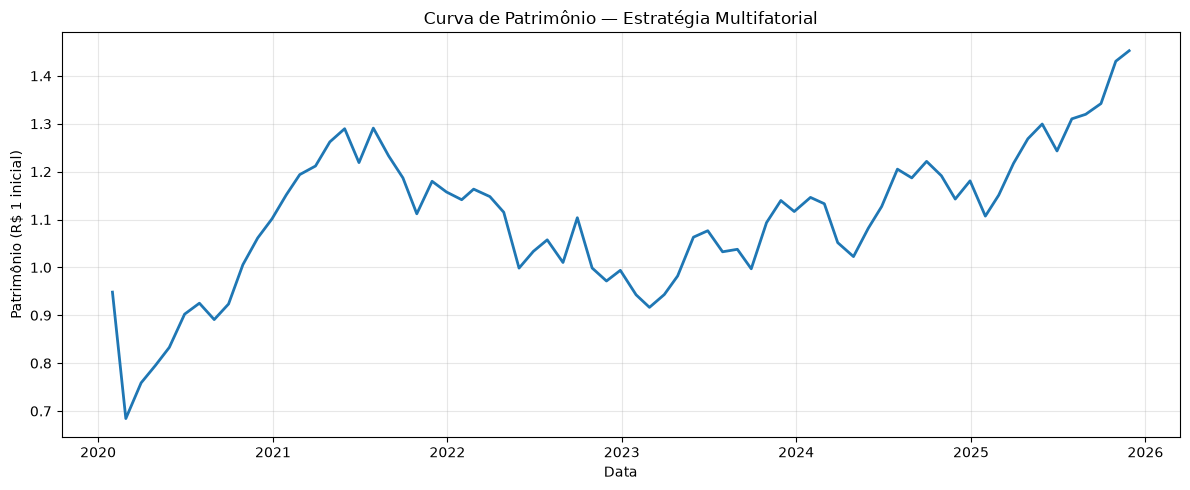

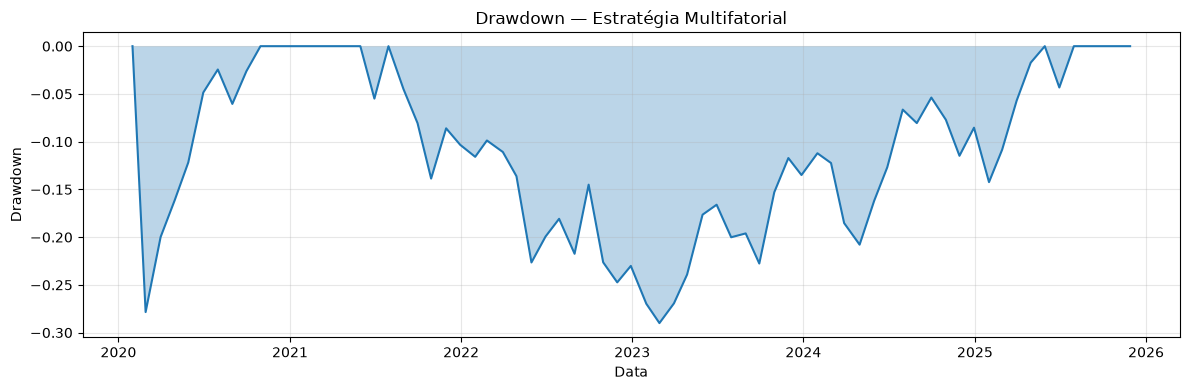

=== ETAPA 12 — VALIDAÇÃO DOS GRÁFICOS ===
Patrimônio inicial: 0.9484
Patrimônio final:   1.4526
Drawdown mínimo:    -29.00%
Drawdown final:     0.00%


In [ ]:
import matplotlib.pyplot as plt

# curva de patrimonio
plt.figure(figsize=(12, 5))

plt.plot(
    ret["date"],
    ret["patrimonio"],
    linewidth=2
)

plt.title("Curva de Patrimônio — Estratégia Multifatorial")
plt.xlabel("Data")
plt.ylabel("Patrimônio (R$ 1 inicial)")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# drawdown
plt.figure(figsize=(12, 4))

plt.fill_between(
    ret["date"],
    ret["drawdown"],
    0,
    alpha=0.3
)

plt.plot(
    ret["date"],
    ret["drawdown"],
    linewidth=1.5
)

plt.title("Drawdown — Estratégia Multifatorial")
plt.xlabel("Data")
plt.ylabel("Drawdown")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# validacao final
print("=== VALIDAÇÃO DOS GRÁFICOS ===")

print(f"Patrimônio inicial: {ret['patrimonio'].iloc[0]:.4f}")
print(f"Patrimônio final:   {ret['patrimonio'].iloc[-1]:.4f}")
print(f"Drawdown mínimo:    {ret['drawdown'].min():.2%}")
print(f"Drawdown final:     {ret['drawdown'].iloc[-1]:.2%}")

In [ ]:
# verificacao IBOV
print("=== PROCURANDO DADOS DO IBOV ===\n")

encontrados = []

for nome, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        cols = set(obj.columns)

        # Possíveis estruturas de preços
        if {"date", "close"}.issubset(cols):
            encontrados.append(
                (nome, obj.shape, list(obj.columns))
            )

print(f"DataFrames com date + close: {len(encontrados)}\n")

for item in encontrados:
    print(item)

=== PROCURANDO DADOS DO IBOV ===

DataFrames com date + close: 4

('prices', (14047860, 12), ['date', 'ticker', 'market', 'name', 'security', 'open', 'high', 'low', 'average', 'close', 'trades', 'volume'])
('px', (58690, 9), ['date', 'ticker', 'close', 'ret', 'close_lag_21', 'close_lag_252', 'momentum_12_1', 'vol_60', 'month'])
('monthly_px', (2833, 7), ['ticker', 'date', 'close', 'momentum_12_1', 'vol_60', 'retorno', 'retorno_proximo_mes'])
('panel', (2833, 14), ['ticker', 'date', 'close', 'momentum_12_1', 'vol_60', 'quality_score', 'leverage_score', 'momentum_w', 'quality_w', 'risk_w', 'z_momentum', 'z_quality', 'z_risk', 'factor_score'])


In [ ]:
# validar serie IBOV
ibov11 = (
    prices[
        prices["ticker"].astype(str).str.strip().eq("IBOV11")
    ]
    .copy()
)

ibov11["date"] = pd.to_datetime(ibov11["date"])

print("=== IBOV11 ===")

print("Observações:", len(ibov11))
print("Período:", ibov11["date"].min(), "até", ibov11["date"].max())

print("\nColunas:")
print(ibov11.columns.tolist())

print("\nPrimeiras observações:")
print(
    ibov11[
        ["date", "ticker", "name", "close"]
    ].head(10)
)

print("\nÚltimas observações:")
print(
    ibov11[
        ["date", "ticker", "name", "close"]
    ].tail(10)
)

=== IBOV11 ===
Observações: 137
Período: 2019-01-16 00:00:00 até 2025-12-30 00:00:00

Colunas:
['date', 'ticker', 'market', 'name', 'security', 'open', 'high', 'low', 'average', 'close', 'trades', 'volume']

Primeiras observações:
             date  ticker      name     close
9013   2019-01-16  IBOV11  IBOVESPA   94133.0
25643  2019-02-13  IBOV11  IBOVESPA   96082.0
41192  2019-03-13  IBOV11  IBOVESPA   98557.0
63184  2019-04-17  IBOV11  IBOVESPA   92985.0
79488  2019-05-15  IBOV11  IBOVESPA   91419.0
97295  2019-06-12  IBOV11  IBOVESPA   98359.0
118436 2019-07-17  IBOV11  IBOVESPA  103993.0
137278 2019-08-14  IBOV11  IBOVESPA  100330.0
161276 2019-09-18  IBOV11  IBOVESPA  104198.0
180708 2019-10-16  IBOV11  IBOVESPA  104921.0

Últimas observações:
               date  ticker      name     close
12549131 2025-12-15  IBOV11  IBOVESPA  162401.0
12551051 2025-12-16  IBOV11  IBOVESPA  159612.0
12552841 2025-12-17  IBOV11  IBOVESPA  157148.0
12554567 2025-12-18  IBOV11  IBOVESPA  158126.0
1

In [ ]:
# IBOV mensal
ibov_diario = prices[
    prices["ticker"] == "IBOV11"
].copy()

ibov_diario["date"] = pd.to_datetime(
    ibov_diario["date"]
)

ibov_diario = ibov_diario[
    ["date", "close"]
].sort_values("date").reset_index(drop=True)

# ultimo pregao de cada mes
ibov_mensal = (
    ibov_diario
    .set_index("date")
    .resample("ME")
    .last()
    .dropna()
    .reset_index()
)

ibov_mensal["retorno"] = (
    ibov_mensal["close"].pct_change()
)

# remove primeiro mes sem retorno
ibov_mensal = ibov_mensal.dropna(
    subset=["retorno"]
).reset_index(drop=True)

# validacao
print("=== IBOV MENSAL ===\n")

print(
    f"Observações: {len(ibov_mensal)}"
)

print(
    f"Período: "
    f"{ibov_mensal['date'].min()} até "
    f"{ibov_mensal['date'].max()}"
)

print(
    f"\nRetornos válidos: "
    f"{ibov_mensal['retorno'].notna().sum()}"
)

print(
    f"Retornos NaN: "
    f"{ibov_mensal['retorno'].isna().sum()}"
)

print("\nPrimeiras observações:")
print(
    ibov_mensal.head(10)
)

print("\nÚltimas observações:")
print(
    ibov_mensal.tail(10)
)

=== IBOV MENSAL ===

Observações: 83
Período: 2019-02-28 00:00:00 até 2025-12-31 00:00:00

Retornos válidos: 83
Retornos NaN: 0

Primeiras observações:
        date     close   retorno
0 2019-02-28   96082.0  0.020705
1 2019-03-31   98557.0  0.025759
2 2019-04-30   92985.0 -0.056536
3 2019-05-31   91419.0 -0.016841
4 2019-06-30   98359.0  0.075914
5 2019-07-31  103993.0  0.057280
6 2019-08-31  100330.0 -0.035224
7 2019-09-30  104198.0  0.038553
8 2019-10-31  104921.0  0.006939
9 2019-11-30  105712.0  0.007539

Últimas observações:
         date     close   retorno
73 2025-03-31  132426.0  0.063321
74 2025-04-30  134845.0  0.018267
75 2025-05-31  138966.0  0.030561
76 2025-06-30  135897.0 -0.022085
77 2025-07-31  133015.0 -0.021207
78 2025-08-31  138656.0  0.042409
79 2025-09-30  146403.0  0.055872
80 2025-10-31  148759.0  0.016093
81 2025-11-30  159414.0  0.071626
82 2025-12-31  161669.0  0.014146


In [ ]:
# identificar series do IBOVESPA
ibov_candidatos = (
    prices[
        prices["name"]
        .astype(str)
        .str.strip()
        .str.upper()
        .eq("IBOVESPA")
    ]
    [["ticker", "name", "date", "close"]]
    .copy()
)

print("=== TICKERS COM NOME EXATO IBOVESPA ===\n")

print(
    ibov_candidatos[
        ["ticker", "name"]
    ]
    .drop_duplicates()
    .sort_values("ticker")
    .to_string(index=False)
)

print("\nQuantidade de tickers:", 
      ibov_candidatos["ticker"].nunique())

=== TICKERS COM NOME EXATO IBOVESPA ===

ticker     name
IBOV11 IBOVESPA

Quantidade de tickers: 1


In [ ]:
# metricas do IBOV
ibov_bench = ibov_mensal.copy()

ibov_bench["patrimonio"] = (1 + ibov_bench["retorno"]).cumprod()

ibov_bench["max_patrimonio"] = ibov_bench["patrimonio"].cummax()

ibov_bench["drawdown"] = (
    ibov_bench["patrimonio"] / ibov_bench["max_patrimonio"]
) - 1

# metricas
n_meses = len(ibov_bench)

retorno_acumulado_ibov = ibov_bench["patrimonio"].iloc[-1] - 1

cagr_ibov = (
    ibov_bench["patrimonio"].iloc[-1] ** (12 / n_meses)
) - 1

vol_anual_ibov = (
    ibov_bench["retorno"].std() * (12 ** 0.5)
)

sharpe_ibov = (
    ibov_bench["retorno"].mean()
    / ibov_bench["retorno"].std()
) * (12 ** 0.5)

max_drawdown_ibov = ibov_bench["drawdown"].min()

meses_positivos_ibov = (
    ibov_bench["retorno"] > 0
).sum()

meses_negativos_ibov = (
    ibov_bench["retorno"] < 0
).sum()

hit_rate_ibov = (
    meses_positivos_ibov / n_meses
)

# resultado
print("=== MÉTRICAS DO IBOV ===\n")

print(
    f"Período: "
    f"{ibov_bench['date'].min()} até "
    f"{ibov_bench['date'].max()}"
)

print(f"Meses: {n_meses}")

print(f"\nRetorno acumulado: {retorno_acumulado_ibov:.2%}")
print(f"Retorno anualizado (CAGR): {cagr_ibov:.2%}")
print(f"Volatilidade anualizada: {vol_anual_ibov:.2%}")
print(f"Sharpe anualizado: {sharpe_ibov:.2f}")
print(f"Maximum Drawdown: {max_drawdown_ibov:.2%}")

print(f"\nMeses positivos: {meses_positivos_ibov}")
print(f"Meses negativos: {meses_negativos_ibov}")
print(f"Hit rate: {hit_rate_ibov:.2%}")

print(
    f"\nMelhor mês: "
    f"{ibov_bench['retorno'].max():.2%} "
    f"({ibov_bench.loc[ibov_bench['retorno'].idxmax(), 'date']})"
)

print(
    f"Pior mês: "
    f"{ibov_bench['retorno'].min():.2%} "
    f"({ibov_bench.loc[ibov_bench['retorno'].idxmin(), 'date']})")

=== MÉTRICAS DO IBOV ===

Período: 2019-02-28 00:00:00 até 2025-12-31 00:00:00
Meses: 83

Retorno acumulado: 71.75%
Retorno anualizado (CAGR): 8.13%
Volatilidade anualizada: 26.96%
Sharpe anualizado: 0.44
Maximum Drawdown: -44.80%

Meses positivos: 46
Meses negativos: 37
Hit rate: 55.42%

Melhor mês: 23.57% (2020-06-30 00:00:00)
Pior mês: -44.80% (2020-03-31 00:00:00)


In [ ]:
# estrategia x IBOV
estrat_comp = retorno_estrategia.copy()

estrat_comp["date"] = pd.to_datetime(
    estrat_comp["date"]
)

estrat_comp["month"] = (
    estrat_comp["date"].dt.to_period("M")
)

estrat_comp = estrat_comp[
    ["date", "month", "retorno"]
].rename(
    columns={
        "retorno": "retorno_estrategia"
    }
)

ibov_comp = ibov_mensal.copy()

ibov_comp["date"] = pd.to_datetime(
    ibov_comp["date"]
)

ibov_comp["month"] = (
    ibov_comp["date"].dt.to_period("M")
)

ibov_comp = ibov_comp[
    ["date", "month", "retorno"]
].rename(
    columns={
        "retorno": "retorno_ibov"
    }
)

# alinha pelo mes
comparacao = pd.merge(
    estrat_comp,
    ibov_comp,
    on="month",
    how="inner",
    suffixes=("_estrategia", "_ibov")
)

comparacao = (
    comparacao
    .sort_values("month")
    .reset_index(drop=True)
)

# patrimonio
comparacao["patrimonio_estrategia"] = (
    1 + comparacao["retorno_estrategia"]
).cumprod()

comparacao["patrimonio_ibov"] = (
    1 + comparacao["retorno_ibov"]
).cumprod()

# drawdown
comparacao["max_estrategia"] = (
    comparacao["patrimonio_estrategia"]
    .cummax()
)

comparacao["max_ibov"] = (
    comparacao["patrimonio_ibov"]
    .cummax()
)

comparacao["drawdown_estrategia"] = (
    comparacao["patrimonio_estrategia"]
    / comparacao["max_estrategia"]
    - 1
)

comparacao["drawdown_ibov"] = (
    comparacao["patrimonio_ibov"]
    / comparacao["max_ibov"]
    - 1
)

# metricas
n = len(comparacao)

ret_estrat = (
    comparacao["patrimonio_estrategia"].iloc[-1] - 1
)

ret_ibov = (
    comparacao["patrimonio_ibov"].iloc[-1] - 1
)

cagr_estrat = (
    comparacao["patrimonio_estrategia"].iloc[-1]
    ** (12 / n)
    - 1
)

cagr_ibov = (
    comparacao["patrimonio_ibov"].iloc[-1]
    ** (12 / n)
    - 1
)

vol_estrat = (
    comparacao["retorno_estrategia"].std()
    * (12 ** 0.5)
)

vol_ibov = (
    comparacao["retorno_ibov"].std()
    * (12 ** 0.5)
)

sharpe_estrat = (
    comparacao["retorno_estrategia"].mean()
    / comparacao["retorno_estrategia"].std()
    * (12 ** 0.5)
)

sharpe_ibov = (
    comparacao["retorno_ibov"].mean()
    / comparacao["retorno_ibov"].std()
    * (12 ** 0.5)
)

dd_estrat = (
    comparacao["drawdown_estrategia"].min()
)

dd_ibov = (
    comparacao["drawdown_ibov"].min()
)

# resultado
print("=== ESTRATÉGIA × IBOV ===\n")

print(
    f"Período comum: "
    f"{comparacao['month'].min()} até "
    f"{comparacao['month'].max()}"
)

print(f"Meses comparáveis: {n}")

print("\n                    Estratégia       IBOV")

print(
    f"Retorno acumulado:   "
    f"{ret_estrat:>8.2%}   "
    f"{ret_ibov:>8.2%}"
)

print(
    f"CAGR:                "
    f"{cagr_estrat:>8.2%}   "
    f"{cagr_ibov:>8.2%}"
)

print(
    f"Volatilidade:        "
    f"{vol_estrat:>8.2%}   "
    f"{vol_ibov:>8.2%}"
)

print(
    f"Sharpe:              "
    f"{sharpe_estrat:>8.2f}   "
    f"{sharpe_ibov:>8.2f}"
)

print(
    f"Maximum Drawdown:    "
    f"{dd_estrat:>8.2%}   "
    f"{dd_ibov:>8.2%}"
)

print(
    f"\nDiferença de retorno acumulado: "
    f"{ret_estrat - ret_ibov:.2%}"
)

# validacao
print("\n=== VALIDAÇÃO ===")

print(f"Observações: {len(comparacao)}")

print(
    f"Retornos estratégia NaN: "
    f"{comparacao['retorno_estrategia'].isna().sum()}"
)

print(
    f"Retornos IBOV NaN: "
    f"{comparacao['retorno_ibov'].isna().sum()}"
)

print("\nPrimeiras observações:")
print(
    comparacao[
        [
            "month",
            "date_estrategia",
            "date_ibov",
            "retorno_estrategia",
            "retorno_ibov"
        ]
    ].head()
)

print("\nÚltimas observações:")
print(
    comparacao[
        [
            "month",
            "date_estrategia",
            "date_ibov",
            "retorno_estrategia",
            "retorno_ibov"
        ]
    ].tail()
)

=== ESTRATÉGIA × IBOV ===

Período comum: 2020-01 até 2025-11
Meses comparáveis: 71

                    Estratégia       IBOV
Retorno acumulado:     45.26%     39.81%
CAGR:                   6.51%      5.83%
Volatilidade:          20.47%     28.59%
Sharpe:                  0.42       0.36
Maximum Drawdown:     -29.00%    -44.80%

Diferença de retorno acumulado: 5.45%

=== VALIDAÇÃO ===
Observações: 71
Retornos estratégia NaN: 0
Retornos IBOV NaN: 0

Primeiras observações:
     month date_estrategia  date_ibov  retorno_estrategia  retorno_ibov
0  2020-01      2020-01-31 2020-01-31           -0.051613      0.020873
1  2020-02      2020-02-28 2020-02-29           -0.278460      0.004708
2  2020-03      2020-03-31 2020-03-31            0.108986     -0.448042
3  2020-04      2020-04-30 2020-04-30            0.048038      0.229970
4  2020-05      2020-05-29 2020-05-31            0.047253     -0.020706

Últimas observações:
      month date_estrategia  date_ibov  retorno_estrategia  retorno_

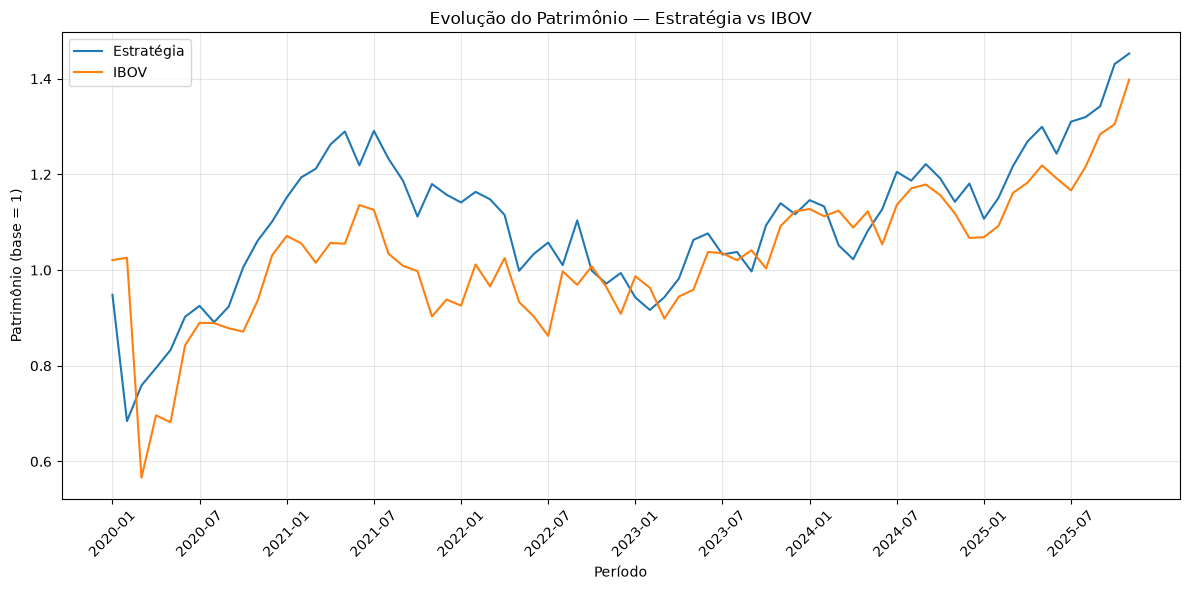

In [ ]:
# curva de patrimonio comparativa
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    comparacao["month"].astype(str),
    comparacao["patrimonio_estrategia"],
    label="Estratégia"
)

plt.plot(
    comparacao["month"].astype(str),
    comparacao["patrimonio_ibov"],
    label="IBOV"
)

plt.title("Evolução do Patrimônio — Estratégia vs IBOV")

plt.xlabel("Período")
plt.ylabel("Patrimônio (base = 1)")

plt.legend()

plt.xticks(
    rotation=45,
    ticks=range(0, len(comparacao), 6),
    labels=comparacao["month"].astype(str).iloc[::6]
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

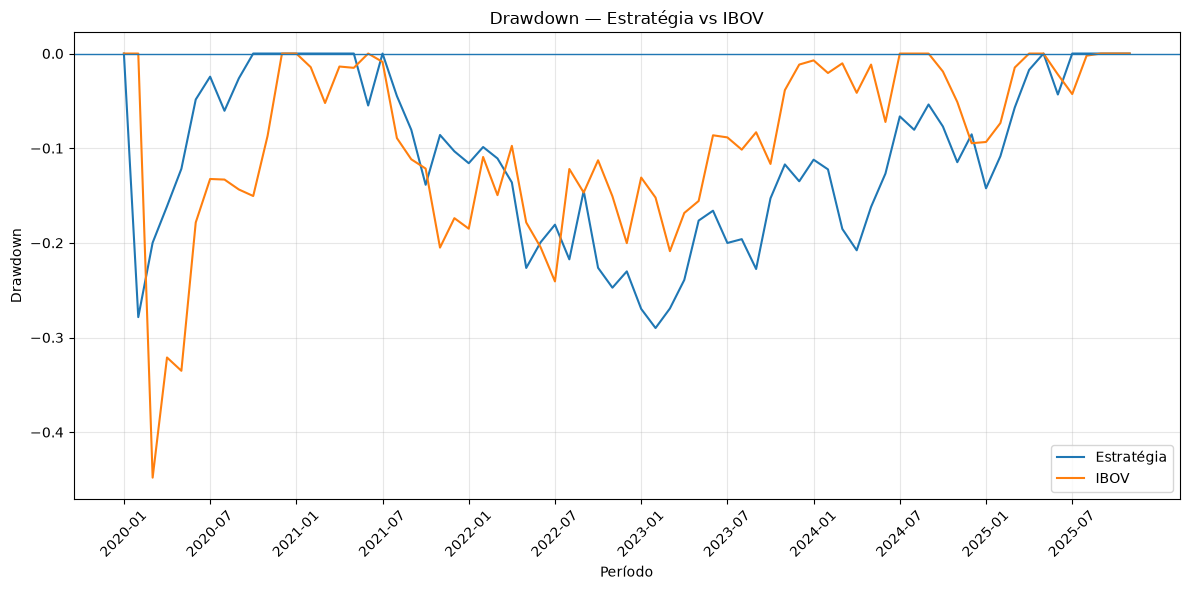

In [ ]:
# drawdown comparativo
plt.figure(figsize=(12, 6))

plt.plot(
    comparacao["month"].astype(str),
    comparacao["drawdown_estrategia"],
    label="Estratégia"
)

plt.plot(
    comparacao["month"].astype(str),
    comparacao["drawdown_ibov"],
    label="IBOV"
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Drawdown — Estratégia vs IBOV")

plt.xlabel("Período")
plt.ylabel("Drawdown")

plt.legend()

plt.xticks(
    ticks=range(0, len(comparacao), 6),
    labels=comparacao["month"].astype(str).iloc[::6],
    rotation=45
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# validacao de look-ahead bias
import pandas as pd
import numpy as np

print("=== VALIDAÇÃO DE LOOK-AHEAD BIAS ===")

objetos_necessarios = [
    "top10",
    "panel",
    "fundamentals",
    "universo_fund"
]

print("\n=== OBJETOS ===")

for nome in objetos_necessarios:

    if nome in globals():
        obj = globals()[nome]
        print(f"{nome}: {obj.shape}")
    else:
        print(f"{nome}: NÃO ENCONTRADO")


top_check = top10.copy()
panel_check = panel.copy()
fund_check = fundamentals.copy()
universo_check = universo_fund.copy()

print("\n=== COLUNAS ===")

print("\nTOP10:")
print(list(top_check.columns))

print("\nPANEL:")
print(list(panel_check.columns))

print("\nFUNDAMENTALS:")
print(list(fund_check.columns))

print("\nUNIVERSO_FUND:")
print(list(universo_check.columns))


colunas_cvm = [
    col for col in fund_check.columns
    if "CD_CVM" in str(col).upper()
]

if not colunas_cvm:
    raise KeyError(
        "Nenhuma coluna CD_CVM foi encontrada em fundamentals."
    )

col_cvm = colunas_cvm[0]

print("\nColuna CD_CVM utilizada:", col_cvm)

# mapa CD_CVM -> ticker
if "CD_CVM" not in universo_check.columns:
    raise KeyError(
        "A coluna CD_CVM não existe em universo_fund."
    )

if "ticker" not in universo_check.columns:
    raise KeyError(
        "A coluna ticker não existe em universo_fund."
    )

mapa_cvm = (
    universo_check[
        ["CD_CVM", "ticker"]
    ]
    .dropna()
    .drop_duplicates()
)

mapa_cvm = dict(
    zip(
        mapa_cvm["CD_CVM"],
        mapa_cvm["ticker"]
    )
)

print("\n=== MAPA CD_CVM → TICKER ===")
print("Empresas no mapa:", len(mapa_cvm))

# copia dos fundamentals com ticker
fund_check["ticker"] = fund_check[col_cvm].map(mapa_cvm)

print("\n=== FUNDAMENTALS COM TICKER ===")

print(
    "Total de fundamentos:",
    len(fund_check)
)

print(
    "Fundamentos com ticker:",
    fund_check["ticker"].notna().sum()
)

print(
    "Fundamentos sem ticker:",
    fund_check["ticker"].isna().sum()
)

# periodo dos fundamentos
fund_check["DT_FIM_EXERC"] = pd.to_datetime(
    fund_check["DT_FIM_EXERC"],
    errors="coerce"
)

top_check["date"] = pd.to_datetime(
    top_check["date"],
    errors="coerce"
)

panel_check["date"] = pd.to_datetime(
    panel_check["date"],
    errors="coerce"
)

print("\n=== PERÍODO DOS FUNDAMENTOS ===")

print(
    "Data inicial:",
    fund_check["DT_FIM_EXERC"].min()
)

print(
    "Data final:",
    fund_check["DT_FIM_EXERC"].max()
)

print(
    "Datas únicas:",
    fund_check["DT_FIM_EXERC"].nunique()
)

print("\n=== PERÍODO DO TOP10 ===")

print(
    "Data inicial:",
    top_check["date"].min()
)

print(
    "Data final:",
    top_check["date"].max()
)

print(
    "Datas únicas:",
    top_check["date"].nunique()
)

# quality score no painel
print("\n=== QUALITY NO PANEL ===")

if "quality_score" not in panel_check.columns:
    raise KeyError(
        "quality_score não existe no panel."
    )

print(
    "Observações totais:",
    len(panel_check)
)

print(
    "Quality válido:",
    panel_check["quality_score"].notna().sum()
)

print(
    "Quality NaN:",
    panel_check["quality_score"].isna().sum()
)

# quality por ano
panel_check["ano"] = panel_check["date"].dt.year

quality_ano = (
    panel_check
    .groupby("ano")
    .agg(
        observacoes=("quality_score", "size"),
        quality_validos=("quality_score", "count")
    )
)

quality_ano["quality_nan"] = (
    quality_ano["observacoes"]
    - quality_ano["quality_validos"]
)

print("\n=== QUALITY POR ANO ===")
print(quality_ano)

# quality score no top10
print("\n=== QUALITY DENTRO DO TOP10 ===")

top_check["ano"] = top_check["date"].dt.year

quality_top = (
    top_check
    .groupby("ano")
    .agg(
        observacoes=("quality_score", "size"),
        quality_validos=("quality_score", "count")
    )
)

quality_top["quality_nan"] = (
    quality_top["observacoes"]
    - quality_top["quality_validos"]
)

print(quality_top)

# verifica fundamentos disponiveis para o top10
print("\n=== FUNDAMENTOS DISPONÍVEIS PARA O TOP10 ===")

tickers_top = (
    top_check["ticker"]
    .dropna()
    .unique()
)

fund_top = fund_check[
    fund_check["ticker"].isin(tickers_top)
].copy()

print(
    "Tickers do Top10:",
    len(tickers_top)
)

print(
    "Tickers com fundamentos:",
    fund_top["ticker"].nunique()
)

if len(fund_top) > 0:

    print(
        fund_top[
            [
                "ticker",
                "DT_FIM_EXERC",
                "quality_score",
                "leverage_score"
            ]
        ]
        .sort_values(
            ["ticker", "DT_FIM_EXERC"]
        )
        .to_string(index=False)
    )


# apenas observaçoes do Top10 para as quais conseguimos encontrar fundamentos pelo ticker.

ranking_fund = top_check[
    ["ticker", "date"]
].merge(
    fund_check[
        [
            "ticker",
            "DT_FIM_EXERC",
            "quality_score",
            "leverage_score"
        ]
    ],
    on="ticker",
    how="left"
)

# fundamentos efetivamente encontrados
com_fundamento = ranking_fund[
    ranking_fund["DT_FIM_EXERC"].notna()
].copy()

print(
    "\nObservações Top10 com fundamento:",
    len(com_fundamento)
)

# fundamento encerrado depois da data do ranking
posterior = com_fundamento[
    com_fundamento["DT_FIM_EXERC"]
    > com_fundamento["date"]
].copy()

print(
    "Observações com DT_FIM_EXERC posterior ao ranking:",
    len(posterior)
)

if len(com_fundamento) > 0:

    percentual = (
        len(posterior)
        / len(com_fundamento)
        * 100
    )

else:

    percentual = 0

print(
    f"Percentual:",
    f"{percentual:.2f}%"
)

# exemplos de fundamentos posteriores
if len(posterior) > 0:

    print(
        "\n=== EXEMPLOS DE FUNDAMENTOS POSTERIORES ==="
    )

    print(
        posterior[
            [
                "ticker",
                "date",
                "DT_FIM_EXERC",
                "quality_score"
            ]
        ]
        .sort_values(
            ["date", "ticker", "DT_FIM_EXERC"]
        )
        .head(30)
        .to_string(index=False)
    )


# auditoria espc ITSA4
itsa_top = top_check[
    top_check["ticker"] == "ITSA4"
][
    [
        "ticker",
        "date",
        "quality_score",
        "leverage_score",
        "z_quality",
        "score",
        "rank"
    ]
]

print("\nITSA4 no TOP10:")
print(
    itsa_top.head(20).to_string(index=False)
)

itsa_fund = fund_check[
    fund_check["ticker"] == "ITSA4"
][
    [
        "ticker",
        "DT_FIM_EXERC",
        "quality_score",
        "leverage_score"
    ]
]

print("\nITSA4 nos fundamentos:")
print(
    itsa_fund.to_string(index=False)
)

print("=== DATA DE DIVULGAÇÃO ===")

termos_divulgacao = [
    "DIVULG",
    "ENTREGA",
    "ENVIO",
    "PUBLIC",
    "APRESENT",
    "RECEP",
    "PROTOCOLO"
]

colunas_divulgacao = []

for col in fund_check.columns:

    col_upper = str(col).upper()

    if any(
        termo in col_upper
        for termo in termos_divulgacao
    ):
        colunas_divulgacao.append(col)

print(
    "\nColunas relacionadas a divulgação/entrega:"
)

if colunas_divulgacao:

    print(colunas_divulgacao)

else:

    print(
        "NENHUMA encontrada."
    )


print("\n=== STATUS ===")
print("BACKTEST ATUAL: NÃO VALIDADO")
print("QUALITY: LOOK-AHEAD BIAS DETECTADO")
print("MÉTRICAS ATUAIS: PRELIMINARES")

=== VALIDAÇÃO DE LOOK-AHEAD BIAS ===

=== OBJETOS ===
top10: (720, 13)
panel: (2833, 14)
fundamentals: (914, 30)
universo_fund: (40, 5)

=== COLUNAS ===

TOP10:
['ticker', 'date', 'momentum_12_1', 'vol_60', 'CD_CVM', 'quality_score', 'leverage_score', 'z_momentum', 'z_quality', 'z_vol', 'score', 'rank', 'peso']

PANEL:
['ticker', 'date', 'close', 'momentum_12_1', 'vol_60', 'quality_score', 'leverage_score', 'momentum_w', 'quality_w', 'risk_w', 'z_momentum', 'z_quality', 'z_risk', 'factor_score']

FUNDAMENTALS:
['CNPJ_CIA', 'DENOM_CIA', 'DT_FIM_EXERC', 'ebit', 'lucro_antes_tributos', 'lucro_liquido', 'receita', 'resultado_bruto', 'resultado_financeiro', 'divida_curto_prazo', 'divida_longo_prazo', 'patrimonio_liquido', 'caixa', 'capex', 'cfo', 'depreciacao_amortizacao', 'margem_ebit', 'margem_liquida', 'roe', 'divida_total', 'divida_liquida', 'divida_liquida_pl', 'z_margem_ebit', 'z_margem_liquida', 'z_roe', 'z_divida_liquida_pl', 'quality_score', 'leverage_score', 'CD_CVM_x', 'CD_CVM_y'

In [ ]:
# fundamentals point-in-time
import pandas as pd
import numpy as np

print("CONSTRUÇÃO DOS FUNDAMENTOS POINT-IN-TIME")

objetos = {
    "fundamentals": fundamentals,
    "universo_fund": universo_fund,
}

for nome, obj in objetos.items():
    print(f"{nome}: {obj.shape}")


print("\n=== COLUNAS FUNDAMENTALS ===")
print(fundamentals.columns.tolist())

print("\n=== COLUNAS UNIVERSO_FUND ===")
print(universo_fund.columns.tolist())

# id col cvm
candidatas_cvm = [
    "CD_CVM_x",
    "CD_CVM",
    "CD_CVM_y"
]

col_cvm = next(
    (c for c in candidatas_cvm if c in fundamentals.columns),
    None
)

if col_cvm is None:
    raise KeyError(
        "Nenhuma coluna CD_CVM encontrada em fundamentals."
    )

print(f"\nColuna CD_CVM utilizada: {col_cvm}")


mapa_cvm = (
    universo_fund[
        ["ticker", "CD_CVM"]
    ]
    .dropna(subset=["ticker", "CD_CVM"])
    .drop_duplicates(subset=["CD_CVM"])
    .copy()
)

mapa_cvm["CD_CVM"] = pd.to_numeric(
    mapa_cvm["CD_CVM"],
    errors="coerce"
)

print("\n=== MAPA CD_CVM → TICKER ===")
print(f"Empresas no mapa: {len(mapa_cvm)}")


fund_pti = fundamentals.copy()

fund_pti[col_cvm] = pd.to_numeric(
    fund_pti[col_cvm],
    errors="coerce"
)

fund_pti = fund_pti.merge(
    mapa_cvm,
    left_on=col_cvm,
    right_on="CD_CVM",
    how="left",
    suffixes=("", "_map")
)

if "ticker_map" in fund_pti.columns:
    fund_pti["ticker"] = fund_pti["ticker_map"]

fund_pti["ticker"] = (
    fund_pti["ticker"]
    .astype("string")
    .str.strip()
)


if "DT_FIM_EXERC" not in fund_pti.columns:
    raise KeyError(
        "A coluna DT_FIM_EXERC não existe em fundamentals."
    )

fund_pti["DT_FIM_EXERC"] = pd.to_datetime(
    fund_pti["DT_FIM_EXERC"],
    errors="coerce"
)

print("\n=== BUSCA POR DATA DE ENTREGA/DIVULGAÇÃO ===")

palavras_data = [
    "data",
    "dt_",
    "dt",
    "entrega",
    "receb",
    "public",
    "apres",
    "protoc",
    "emissao"
]

colunas_data = []

for col in fundamentals.columns:

    col_lower = col.lower()

    if any(p in col_lower for p in palavras_data):
        colunas_data.append(col)

print("Colunas potencialmente relacionadas:")
print(colunas_data)


if len(colunas_data) == 1 and colunas_data[0] == "DT_FIM_EXERC":

    print("\n⚠️ ATENÇÃO")
    print(
        "fundamentals não possui uma coluna explícita de "
        "data de entrega/divulgação."
    )

    print(
        "\nNão vamos fabricar uma data de divulgação."
    )

    print(
        "A base será marcada como NÃO POINT-IN-TIME "
        "até incorporarmos os metadados de entrega da CVM."
    )

    fund_pti["data_disponibilidade"] = pd.NaT

    fund_pti["pti_validado"] = False

else:

    candidatos_entrega = [
        c for c in colunas_data
        if c != "DT_FIM_EXERC"
        and any(
            palavra in c.lower()
            for palavra in [
                "entrega",
                "receb",
                "public",
                "apres",
                "protoc"
            ]
        )
    ]

    if candidatos_entrega:

        col_entrega = candidatos_entrega[0]

        print(
            f"\nColuna de disponibilidade encontrada: "
            f"{col_entrega}"
        )

        fund_pti["data_disponibilidade"] = pd.to_datetime(
            fund_pti[col_entrega],
            errors="coerce"
        )

        fund_pti["pti_validado"] = (
            fund_pti["data_disponibilidade"].notna()
        )

    else:

        print(
            "\n Nenhuma data de divulgação/entrega "
            "foi identificada automaticamente."
        )

        fund_pti["data_disponibilidade"] = pd.NaT

        fund_pti["pti_validado"] = False


print("RESUMO DA BASE POINT-IN-TIME")

print(
    f"Fundamentos totais: {len(fund_pti):,}"
)

print(
    f"Fundamentos com ticker: "
    f"{fund_pti['ticker'].notna().sum():,}"
)

print(
    f"Fundamentos sem ticker: "
    f"{fund_pti['ticker'].isna().sum():,}"
)

print(
    f"Data de disponibilidade válida: "
    f"{fund_pti['data_disponibilidade'].notna().sum():,}"
)

print(
    f"Observações PTI validadas: "
    f"{fund_pti['pti_validado'].sum():,}"
)


print("\n=== PERÍODO CONTÁBIL ===")

print(
    "Inicial:",
    fund_pti["DT_FIM_EXERC"].min()
)

print(
    "Final:",
    fund_pti["DT_FIM_EXERC"].max()
)

print("\n=== DATA DE DISPONIBILIDADE ===")

print(
    "Inicial:",
    fund_pti["data_disponibilidade"].min()
)

print(
    "Final:",
    fund_pti["data_disponibilidade"].max()
)


print("\n=== DUPLICIDADES ===")

duplicidades = (
    fund_pti
    .duplicated(
        subset=["ticker", "DT_FIM_EXERC"],
        keep=False
    )
)

print(
    "Duplicidades ticker × exercício:",
    duplicidades.sum()
)


fundamentals_pti = fund_pti.copy()

print("\n=== OBJETO CRIADO ===")
print(
    "fundamentals_pti:",
    fundamentals_pti.shape
)

print(
    "\nfundamentals original NÃO foi alterado."
)

CONSTRUÇÃO DOS FUNDAMENTOS POINT-IN-TIME
fundamentals: (914, 30)
universo_fund: (40, 5)

=== COLUNAS FUNDAMENTALS ===
['CNPJ_CIA', 'DENOM_CIA', 'DT_FIM_EXERC', 'ebit', 'lucro_antes_tributos', 'lucro_liquido', 'receita', 'resultado_bruto', 'resultado_financeiro', 'divida_curto_prazo', 'divida_longo_prazo', 'patrimonio_liquido', 'caixa', 'capex', 'cfo', 'depreciacao_amortizacao', 'margem_ebit', 'margem_liquida', 'roe', 'divida_total', 'divida_liquida', 'divida_liquida_pl', 'z_margem_ebit', 'z_margem_liquida', 'z_roe', 'z_divida_liquida_pl', 'quality_score', 'leverage_score', 'CD_CVM_x', 'CD_CVM_y']

=== COLUNAS UNIVERSO_FUND ===
['ticker', 'name', 'CD_CVM', 'DENOM_CIA', 'CNPJ_CIA']

Coluna CD_CVM utilizada: CD_CVM_x

=== MAPA CD_CVM → TICKER ===
Empresas no mapa: 38

=== BUSCA POR DATA DE ENTREGA/DIVULGAÇÃO ===
Colunas potencialmente relacionadas:
['DT_FIM_EXERC']

⚠️ ATENÇÃO
fundamentals não possui uma coluna explícita de data de entrega/divulgação.

Não vamos fabricar uma data de divul

In [ ]:
import pandas as pd
import numpy as np


print("AUDITORIA DO VÍNCULO CD_CVM → TICKER")

print("\n=== OBJETOS ===")

print("fundamentals:", fundamentals.shape)
print("universo_fund:", universo_fund.shape)

if "fundamentals_pti" in globals():
    print("fundamentals_pti:", fundamentals_pti.shape)
else:
    print("fundamentals_pti: não encontrado")


print("\n=== COLUNAS ===")

print("\nfundamentals:")
print(fundamentals.columns.tolist())

print("\nuniverso_fund:")
print(universo_fund.columns.tolist())


candidatas_cvm_fund = [
    "CD_CVM_x",
    "CD_CVM",
    "CD_CVM_y"
]

col_cvm_fund = next(
    (
        col
        for col in candidatas_cvm_fund
        if col in fundamentals.columns
    ),
    None
)

if col_cvm_fund is None:
    raise KeyError(
        "Nenhuma coluna CD_CVM encontrada em fundamentals."
    )

if "CD_CVM" not in universo_fund.columns:
    raise KeyError(
        "A coluna CD_CVM não existe em universo_fund."
    )

print("\nColuna CVM em fundamentals:", col_cvm_fund)
print("Coluna CVM em universo_fund: CD_CVM")


fund_check = fundamentals.copy()

univ_check = universo_fund.copy()

fund_check["_CD_CVM_CHECK"] = pd.to_numeric(
    fund_check[col_cvm_fund],
    errors="coerce"
)

univ_check["_CD_CVM_CHECK"] = pd.to_numeric(
    univ_check["CD_CVM"],
    errors="coerce"
)

univ_check["_TICKER_CHECK"] = (
    univ_check["ticker"]
    .astype("string")
    .str.strip()
)


print("ESTATÍSTICAS DOS CÓDIGOS CD_CVM")

print(
    "\nFundamentals:"
)

print(
    "Total de linhas:",
    len(fund_check)
)

print(
    "CD_CVM preenchido:",
    fund_check["_CD_CVM_CHECK"].notna().sum()
)

print(
    "CD_CVM NaN:",
    fund_check["_CD_CVM_CHECK"].isna().sum()
)

print(
    "CD_CVM únicos:",
    fund_check["_CD_CVM_CHECK"].nunique()
)

print(
    "\nUniverso:"
)

print(
    "Total de linhas:",
    len(univ_check)
)

print(
    "CD_CVM preenchido:",
    univ_check["_CD_CVM_CHECK"].notna().sum()
)

print(
    "CD_CVM NaN:",
    univ_check["_CD_CVM_CHECK"].isna().sum()
)

print(
    "CD_CVM únicos:",
    univ_check["_CD_CVM_CHECK"].nunique()
)


cvm_fund = set(
    fund_check["_CD_CVM_CHECK"]
    .dropna()
    .unique()
)

cvm_univ = set(
    univ_check["_CD_CVM_CHECK"]
    .dropna()
    .unique()
)

cvm_intersecao = cvm_fund.intersection(cvm_univ)
cvm_sem_mapa = cvm_fund.difference(cvm_univ)

print("\n=== COMPARAÇÃO DOS CÓDIGOS ===")

print(
    "CD_CVM nos fundamentos:",
    len(cvm_fund)
)

print(
    "CD_CVM no universo:",
    len(cvm_univ)
)

print(
    "CD_CVM presentes nos dois:",
    len(cvm_intersecao)
)

print(
    "CD_CVM sem correspondência:",
    len(cvm_sem_mapa)
)


sem_mapa_df = (
    fund_check[
        fund_check["_CD_CVM_CHECK"].isin(cvm_sem_mapa)
    ]
    [
        [
            "CNPJ_CIA",
            "DENOM_CIA",
            "DT_FIM_EXERC",
            col_cvm_fund
        ]
    ]
    .drop_duplicates()
    .sort_values(
        ["DENOM_CIA", "DT_FIM_EXERC"]
    )
)

print("\n=== EXEMPLOS DE CD_CVM SEM CORRESPONDÊNCIA ===")

if len(sem_mapa_df) > 0:
    print(
        sem_mapa_df.head(30).to_string(index=False)
    )
else:
    print("Nenhum código sem correspondência.")


print("\n=== EXEMPLOS DOS CÓDIGOS ===")

print("\nFundamentals:")
print(
    fund_check[
        [col_cvm_fund, "_CD_CVM_CHECK"]
    ]
    .drop_duplicates()
    .head(20)
    .to_string(index=False)
)

print("\nUniverso:")
print(
    univ_check[
        ["CD_CVM", "_CD_CVM_CHECK", "ticker", "DENOM_CIA"]
    ]
    .drop_duplicates()
    .head(20)
    .to_string(index=False)
)


print("DUPLICIDADES NO UNIVERSO")

dup_cvm_univ = (
    univ_check[
        univ_check["_CD_CVM_CHECK"].duplicated(
            keep=False
        )
    ]
    .sort_values("_CD_CVM_CHECK")
)

print(
    "Linhas envolvidas:",
    len(dup_cvm_univ)
)

if len(dup_cvm_univ) > 0:

    print(
        dup_cvm_univ[
            [
                "ticker",
                "name",
                "CD_CVM",
                "DENOM_CIA",
                "CNPJ_CIA"
            ]
        ]
        .head(50)
        .to_string(index=False)
    )



print("TESTE DIRETO DO MERGE")

teste_merge = fund_check.merge(
    univ_check[
        [
            "_CD_CVM_CHECK",
            "_TICKER_CHECK"
        ]
    ]
    .drop_duplicates(
        subset=["_CD_CVM_CHECK"]
    ),
    on="_CD_CVM_CHECK",
    how="left"
)

teste_merge["tem_ticker"] = (
    teste_merge["_TICKER_CHECK"].notna()
)

print(
    "Fundamentos totais:",
    len(teste_merge)
)

print(
    "Com ticker:",
    teste_merge["tem_ticker"].sum()
)

print(
    "Sem ticker:",
    (~teste_merge["tem_ticker"]).sum()
)


fund_com_ticker = (
    teste_merge[
        teste_merge["tem_ticker"]
    ]
    .copy()
)

print("\n=== FUNDAMENTOS COM TICKER ===")

print(
    fund_com_ticker[
        [
            "DENOM_CIA",
            "DT_FIM_EXERC",
            col_cvm_fund,
            "_TICKER_CHECK"
        ]
    ]
    .drop_duplicates()
    .head(50)
    .to_string(index=False)
)


fund_sem_ticker = (
    teste_merge[
        ~teste_merge["tem_ticker"]
    ]
    .copy()
)

print("\n=== FUNDAMENTOS SEM TICKER ===")

print(
    "Quantidade:",
    len(fund_sem_ticker)
)

print(
    fund_sem_ticker[
        [
            "CNPJ_CIA",
            "DENOM_CIA",
            "DT_FIM_EXERC",
            col_cvm_fund,
            "_CD_CVM_CHECK"
        ]
    ]
    .drop_duplicates()
    .head(50)
    .to_string(index=False)
)


print("AUDITORIA POR CNPJ")

fund_check["_CNPJ_CHECK"] = (
    fund_check["CNPJ_CIA"]
    .astype("string")
    .str.replace(
        r"\D",
        "",
        regex=True
    )
    .str.strip()
)

univ_check["_CNPJ_CHECK"] = (
    univ_check["CNPJ_CIA"]
    .astype("string")
    .str.replace(
        r"\D",
        "",
        regex=True
    )
    .str.strip()
)

cnpj_fund = set(
    fund_check[
        fund_check["_CNPJ_CHECK"].notna()
        & (fund_check["_CNPJ_CHECK"] != "")
    ]["_CNPJ_CHECK"]
    .unique()
)

cnpj_univ = set(
    univ_check[
        univ_check["_CNPJ_CHECK"].notna()
        & (univ_check["_CNPJ_CHECK"] != "")
    ]["_CNPJ_CHECK"]
    .unique()
)

print(
    "CNPJs nos fundamentos:",
    len(cnpj_fund)
)

print(
    "CNPJs no universo:",
    len(cnpj_univ)
)

print(
    "CNPJs em comum:",
    len(cnpj_fund.intersection(cnpj_univ))
)

print(
    "CNPJs sem correspondência:",
    len(cnpj_fund.difference(cnpj_univ))
)


cnpj_mapa = (
    univ_check[
        [
            "_CNPJ_CHECK",
            "_TICKER_CHECK"
        ]
    ]
    .dropna(subset=["_CNPJ_CHECK"])
    .drop_duplicates(
        subset=["_CNPJ_CHECK"]
    )
)

teste_cnpj = fund_check.merge(
    cnpj_mapa,
    on="_CNPJ_CHECK",
    how="left"
)

teste_cnpj["ticker_por_cnpj"] = (
    teste_cnpj["_TICKER_CHECK"].notna()
)

print("\n=== TESTE POR CNPJ ===")

print(
    "Fundamentos com ticker via CNPJ:",
    teste_cnpj["ticker_por_cnpj"].sum()
)

print(
    "Fundamentos sem ticker via CNPJ:",
    (~teste_cnpj["ticker_por_cnpj"]).sum()
)

casos_cnpj = teste_merge.copy()

casos_cnpj["_CNPJ_CHECK"] = (
    casos_cnpj["CNPJ_CIA"]
    .astype("string")
    .str.replace(
        r"\D",
        "",
        regex=True
    )
)

casos_cnpj = casos_cnpj.merge(
    cnpj_mapa.rename(
        columns={
            "_TICKER_CHECK": "ticker_por_cnpj"
        }
    ),
    on="_CNPJ_CHECK",
    how="left"
)

casos_cnpj["cvm_sem_ticker"] = (
    casos_cnpj["_TICKER_CHECK"].isna()
)

casos_cnpj["cnpj_com_ticker"] = (
    casos_cnpj["ticker_por_cnpj"].notna()
)

casos_recuperaveis = casos_cnpj[
    casos_cnpj["cvm_sem_ticker"]
    & casos_cnpj["cnpj_com_ticker"]
].copy()

print(
    "\n=== CASOS POTENCIALMENTE RECUPERÁVEIS POR CNPJ ==="
)

print(
    "Quantidade:",
    len(casos_recuperaveis)
)

if len(casos_recuperaveis) > 0:

    print(
        casos_recuperaveis[
            [
                "DENOM_CIA",
                "CNPJ_CIA",
                col_cvm_fund,
                "ticker_por_cnpj"
            ]
        ]
        .drop_duplicates()
        .head(50)
        .to_string(index=False)
    )


print(
    f"Fundamentos totais: {len(fund_check):,}"
)

print(
    f"CD_CVM únicos nos fundamentos: {len(cvm_fund):,}"
)

print(
    f"CD_CVM com correspondência direta: "
    f"{len(cvm_intersecao):,}"
)

print(
    f"CD_CVM sem correspondência: "
    f"{len(cvm_sem_mapa):,}"
)

print(
    f"Fundamentos com ticker por CD_CVM: "
    f"{teste_merge['tem_ticker'].sum():,}"
)

print(
    f"Fundamentos sem ticker por CD_CVM: "
    f"{(~teste_merge['tem_ticker']).sum():,}"
)

print(
    f"CNPJs em comum: "
    f"{len(cnpj_fund.intersection(cnpj_univ)):,}"
)

print(
    f"Casos que podem ser investigados por CNPJ: "
    f"{len(casos_recuperaveis):,}"
)

AUDITORIA DO VÍNCULO CD_CVM → TICKER

=== OBJETOS ===
fundamentals: (914, 30)
universo_fund: (40, 5)
fundamentals_pti: (914, 34)

=== COLUNAS ===

fundamentals:
['CNPJ_CIA', 'DENOM_CIA', 'DT_FIM_EXERC', 'ebit', 'lucro_antes_tributos', 'lucro_liquido', 'receita', 'resultado_bruto', 'resultado_financeiro', 'divida_curto_prazo', 'divida_longo_prazo', 'patrimonio_liquido', 'caixa', 'capex', 'cfo', 'depreciacao_amortizacao', 'margem_ebit', 'margem_liquida', 'roe', 'divida_total', 'divida_liquida', 'divida_liquida_pl', 'z_margem_ebit', 'z_margem_liquida', 'z_roe', 'z_divida_liquida_pl', 'quality_score', 'leverage_score', 'CD_CVM_x', 'CD_CVM_y']

universo_fund:
['ticker', 'name', 'CD_CVM', 'DENOM_CIA', 'CNPJ_CIA']

Coluna CVM em fundamentals: CD_CVM_x
Coluna CVM em universo_fund: CD_CVM
ESTATÍSTICAS DOS CÓDIGOS CD_CVM

Fundamentals:
Total de linhas: 914
CD_CVM preenchido: 914
CD_CVM NaN: 0
CD_CVM únicos: 477

Universo:
Total de linhas: 40
CD_CVM preenchido: 40
CD_CVM NaN: 0
CD_CVM únicos: 38


In [ ]:
# fund limpos pra point-in-time
import pandas as pd
import numpy as np

print("=== FUNDAMENTOS PARA POINT-IN-TIME ===")

objetos = ["fundamentals", "universo_fund", "fundamentals_pti"]

for obj in objetos:
    if obj not in globals():
        raise NameError(f"Objeto '{obj}' não encontrado.")

print("\n=== OBJETOS ===")
print("fundamentals:", fundamentals.shape)
print("universo_fund:", universo_fund.shape)
print("fundamentals_pti:", fundamentals_pti.shape)

fund_base = fundamentals.copy()
universo_base = universo_fund.copy()

fund_base["_CD_CVM"] = pd.to_numeric(
    fund_base["CD_CVM_x"],
    errors="coerce"
)

universo_base["_CD_CVM"] = pd.to_numeric(
    universo_base["CD_CVM"],
    errors="coerce"
)

print("\n=== CD_CVM ===")
print("Fundamentos:", fund_base["_CD_CVM"].nunique())
print("Universo:", universo_base["_CD_CVM"].nunique())


mapa_cvm = (
    universo_base[
        ["_CD_CVM", "ticker", "name", "DENOM_CIA", "CNPJ_CIA"]
    ]
    .dropna(subset=["_CD_CVM"])
    .drop_duplicates(subset=["_CD_CVM"])
)

print("\n=== MAPA CD_CVM ===")
print("Empresas no mapa:", len(mapa_cvm))


fund_pti_base = fund_base.merge(
    mapa_cvm,
    on="_CD_CVM",
    how="inner",
    suffixes=("", "_universo")
)

print("\n=== FUNDAMENTOS NO UNIVERSO ===")
print("Linhas:", len(fund_pti_base))
print("Tickers:", fund_pti_base["ticker"].nunique())


mapa_cnpj = (
    universo_base[
        ["CNPJ_CIA", "ticker", "name"]
    ]
    .dropna(subset=["CNPJ_CIA"])
    .drop_duplicates(subset=["CNPJ_CIA"])
)

fund_cnpj = fund_base.merge(
    mapa_cnpj,
    on="CNPJ_CIA",
    how="inner",
    suffixes=("", "_cnpj")
)

print("\n=== RECUPERAÇÃO POR CNPJ ===")
print("Fundamentos recuperáveis por CNPJ:", len(fund_cnpj))

cnpj_extra = fund_cnpj[
    ~fund_cnpj["CNPJ_CIA"].isin(
        fund_pti_base["CNPJ_CIA"]
    )
].copy()

if len(cnpj_extra) > 0:

    # Renomear ticker proveniente do CNPJ
    if "ticker_cnpj" in cnpj_extra.columns:
        cnpj_extra["ticker"] = cnpj_extra["ticker_cnpj"]

    if "name_cnpj" in cnpj_extra.columns:
        cnpj_extra["name"] = cnpj_extra["name_cnpj"]

    # Manter somente colunas compatíveis
    colunas_comuns = [
        c for c in fund_pti_base.columns
        if c in cnpj_extra.columns
    ]

    cnpj_extra = cnpj_extra[colunas_comuns]

    fund_pti_base = pd.concat(
        [fund_pti_base, cnpj_extra],
        ignore_index=True
    )

print("\n=== APÓS RECUPERAÇÃO POR CNPJ ===")
print("Fundamentos:", len(fund_pti_base))
print("Tickers:", fund_pti_base["ticker"].nunique())


colunas_auxiliares = [
    "_CD_CVM",
    "ticker_cnpj",
    "name_cnpj"
]

fund_pti_base = fund_pti_base.drop(
    columns=[
        c for c in colunas_auxiliares
        if c in fund_pti_base.columns
    ],
    errors="ignore"
)


fund_pti_base["DT_FIM_EXERC"] = pd.to_datetime(
    fund_pti_base["DT_FIM_EXERC"],
    errors="coerce"
)

fund_pti_base["data_disponibilidade"] = pd.NaT

fund_pti_base["pti_validado"] = False

fund_pti_base = fund_pti_base.sort_values(
    ["ticker", "DT_FIM_EXERC"]
).reset_index(drop=True)

fundamentals_universe_pti = fund_pti_base.copy()


print("Fundamentos totais:", len(fundamentals_universe_pti))
print(
    "Tickers únicos:",
    fundamentals_universe_pti["ticker"].nunique()
)

print(
    "Datas contábeis:",
    fundamentals_universe_pti["DT_FIM_EXERC"]
    .dropna()
    .nunique()
)

print(
    "Data disponibilidade preenchida:",
    fundamentals_universe_pti["data_disponibilidade"]
    .notna()
    .sum()
)

print(
    "Observações PTI validadas:",
    fundamentals_universe_pti["pti_validado"]
    .sum()
)


print("\n=== FUNDAMENTOS FINAIS ===")

print(
    fundamentals_universe_pti[
        [
            "ticker",
            "DENOM_CIA",
            "DT_FIM_EXERC",
            "data_disponibilidade",
            "quality_score",
            "leverage_score",
            "pti_validado"
        ]
    ].head(20).to_string(index=False)
)

=== FUNDAMENTOS PARA POINT-IN-TIME ===

=== OBJETOS ===
fundamentals: (914, 30)
universo_fund: (40, 5)
fundamentals_pti: (914, 34)

=== CD_CVM ===
Fundamentos: 477
Universo: 38

=== MAPA CD_CVM ===
Empresas no mapa: 38

=== FUNDAMENTOS NO UNIVERSO ===
Linhas: 76
Tickers: 38

=== RECUPERAÇÃO POR CNPJ ===
Fundamentos recuperáveis por CNPJ: 76

=== APÓS RECUPERAÇÃO POR CNPJ ===
Fundamentos: 78
Tickers: 38
Fundamentos totais: 78
Tickers únicos: 38
Datas contábeis: 4
Data disponibilidade preenchida: 0
Observações PTI validadas: 0

=== FUNDAMENTOS FINAIS ===
ticker         DENOM_CIA DT_FIM_EXERC data_disponibilidade  quality_score  leverage_score  pti_validado
 ABEV3        AMBEV S.A.   2024-12-31                  NaT       0.161006        0.208464         False
 ABEV3        AMBEV S.A.   2025-12-31                  NaT       0.194062        0.222457         False
 ALOS3        ALLOS S.A.   2024-12-31                  NaT       0.347668        0.173798         False
 ALOS3        ALLOS S.A. 

In [ ]:
# panel point-in-time
import pandas as pd
import numpy as np

print("=== PANEL POINT-IN-TIME ===")

panel_pti = panel.copy()
fund_pti = fundamentals_pti.copy()


panel_pti["date"] = pd.to_datetime(panel_pti["date"])
fund_pti["DT_FIM_EXERC"] = pd.to_datetime(fund_pti["DT_FIM_EXERC"])

if "data_disponibilidade" in fund_pti.columns:
    fund_pti["data_disponibilidade"] = pd.to_datetime(
        fund_pti["data_disponibilidade"],
        errors="coerce"
    )
else:
    fund_pti["data_disponibilidade"] = pd.NaT

# garante ticker
if "ticker" not in fund_pti.columns:
    raise ValueError("fundamentals_pti não possui coluna 'ticker'.")

fund_pti["ticker"] = fund_pti["ticker"].astype(str).str.strip()
panel_pti["ticker"] = panel_pti["ticker"].astype(str).str.strip()

fund_validos = fund_pti[
    fund_pti["data_disponibilidade"].notna()
].copy()

print("Fundamentos totais:", len(fund_pti))
print("Fundamentos com data de disponibilidade:", len(fund_validos))

# merge point-in-time
if len(fund_validos) == 0:

    print("\n NENHUM FUNDAMENTO POSSUI DATA DE DISPONIBILIDADE.")
    print("Não será realizado preenchimento artificial.")
    print("panel_pti será criado com quality/leverage como NaN.")

    panel_pti["quality_score"] = np.nan
    panel_pti["leverage_score"] = np.nan

else:

    fund_validos = fund_validos.sort_values(
        ["ticker", "data_disponibilidade"]
    )

    panel_pti = panel_pti.sort_values(
        ["ticker", "date"]
    )

    # remove colunas que serao reconstruidas
    for col in ["quality_score", "leverage_score"]:
        if col in panel_pti.columns:
            panel_pti = panel_pti.drop(columns=col)

    # merge_asof exige nomes distintos para a data
    fund_validos = fund_validos.rename(
        columns={"data_disponibilidade": "_data_disponibilidade"}
    )

    panel_pti = pd.merge_asof(
        panel_pti,
        fund_validos[
            [
                "ticker",
                "_data_disponibilidade",
                "quality_score",
                "leverage_score"
            ]
        ].sort_values(["ticker", "_data_disponibilidade"]),
        left_on="date",
        right_on="_data_disponibilidade",
        by="ticker",
        direction="backward"
    )

    panel_pti = panel_pti.drop(
        columns=["_data_disponibilidade"],
        errors="ignore"
    )

# recalcular z_quality
if "quality_score" in panel_pti.columns:

    panel_pti["z_quality"] = (
        panel_pti.groupby("date")["quality_score"]
        .transform(
            lambda x: (
                (x - x.mean()) / x.std(ddof=0)
                if x.notna().sum() > 1 and x.std(ddof=0) != 0
                else 0.0
            )
        )
    )

# recalcular z_risk
if all(
    c in panel_pti.columns
    for c in ["z_momentum", "z_quality", "z_risk"]
):

    panel_pti["factor_score"] = (
        0.4 * panel_pti["z_momentum"]
        + 0.4 * panel_pti["z_quality"]
        - 0.2 * panel_pti["z_risk"]
    )


panel_pti = panel_pti.sort_values(
    ["date", "ticker"]
).reset_index(drop=True)


print("\n=== RESULTADO ===")
print("panel original:", panel.shape)
print("panel_pti:", panel_pti.shape)

print("\n=== QUALITY ===")

if "quality_score" in panel_pti.columns:
    print(
        "Quality válido:",
        panel_pti["quality_score"].notna().sum()
    )
    print(
        "Quality NaN:",
        panel_pti["quality_score"].isna().sum()
    )

print("\n=== PERÍODO ===")
print("Inicial:", panel_pti["date"].min())
print("Final:", panel_pti["date"].max())

print("\n=== AMOSTRA ===")
print(
    panel_pti[
        [
            "ticker",
            "date",
            "quality_score",
            "leverage_score",
            "z_quality",
            "factor_score"
        ]
    ].head(20).to_string(index=False)
)

=== PANEL POINT-IN-TIME ===
Fundamentos totais: 914
Fundamentos com data de disponibilidade: 0

 NENHUM FUNDAMENTO POSSUI DATA DE DISPONIBILIDADE.
Não será realizado preenchimento artificial.
panel_pti será criado com quality/leverage como NaN.

=== RESULTADO ===
panel original: (2833, 14)
panel_pti: (2833, 14)

=== QUALITY ===
Quality válido: 0
Quality NaN: 2833

=== PERÍODO ===
Inicial: 2019-01-31 00:00:00
Final: 2025-12-30 00:00:00

=== AMOSTRA ===
ticker       date  quality_score  leverage_score  z_quality  factor_score
 ABEV3 2019-01-31            NaN             NaN        0.0           0.0
 ALPA4 2019-01-31            NaN             NaN        0.0           0.0
 AZUL4 2019-01-31            NaN             NaN        0.0           0.0
 BEEF3 2019-01-31            NaN             NaN        0.0           0.0
 BRFS3 2019-01-31            NaN             NaN        0.0           0.0
 BRKM5 2019-01-31            NaN             NaN        0.0           0.0
 CPFE3 2019-01-31         

In [ ]:
print("=== STATUS POINT-IN-TIME ===")

assert "panel_pti" in globals()
assert "fundamentals_pti" in globals()

n_fund = len(fundamentals_pti)

if "data_disponibilidade" in fundamentals_pti.columns:
    n_data = fundamentals_pti["data_disponibilidade"].notna().sum()
else:
    n_data = 0

n_quality_pti = panel_pti["quality_score"].notna().sum()

# stats
pti_validado = (
    n_fund > 0
    and n_data > 0
    and n_quality_pti > 0
)

print("\n=== RESUMO ===")
print(f"Fundamentos: {n_fund}")
print(f"Fundamentos com data de disponibilidade: {n_data}")
print(f"Quality válido no panel_pti: {n_quality_pti}")

print("\n=== CONCLUSÃO ===")

if pti_validado:
    print("POINT-IN-TIME VALIDADO")

else:
    print("POINT-IN-TIME NÃO VALIDADO")
    
# flags formais
pti_status = {
    "pti_validado": pti_validado,
    "fundamentos_com_data": n_data,
    "quality_pti_validos": n_quality_pti,
    "lookahead_controlado": not pti_validado
}

print("\n=== FLAGS ===")
print(pti_status)

=== STATUS POINT-IN-TIME ===

=== RESUMO ===
Fundamentos: 914
Fundamentos com data de disponibilidade: 0
Quality válido no panel_pti: 0

=== CONCLUSÃO ===
POINT-IN-TIME NÃO VALIDADO

=== FLAGS ===
{'pti_validado': np.False_, 'fundamentos_com_data': np.int64(0), 'quality_pti_validos': np.int64(0), 'lookahead_controlado': True}


In [ ]:
print("=== BACKTEST FINAL CORRIGIDO ===")

panel_final = panel.copy()

panel_final["date"] = pd.to_datetime(panel_final["date"])
panel_final["ticker"] = panel_final["ticker"].astype(str).str.strip()

required_cols = [
    "ticker",
    "date",
    "close",
    "momentum_12_1",
    "vol_60",
    "z_momentum",
    "z_risk"
]

missing = [c for c in required_cols if c not in panel_final.columns]

if missing:
    raise ValueError(f"Colunas ausentes: {missing}")

panel_final["valid_factor"] = (
    panel_final["z_momentum"].notna()
    & panel_final["z_risk"].notna()
    & panel_final["momentum_12_1"].notna()
    & panel_final["vol_60"].notna()
)

print("\nObservações válidas para ranking:",
      panel_final["valid_factor"].sum())

# score momentum + risk
panel_final["factor_score_final"] = np.nan

panel_final.loc[
    panel_final["valid_factor"],
    "factor_score_final"
] = (
    0.50 * panel_final.loc[
        panel_final["valid_factor"],
        "z_momentum"
    ]
    -
    0.50 * panel_final.loc[
        panel_final["valid_factor"],
        "z_risk"
    ]
)


panel_final["rank_final"] = np.nan

valid_mask = panel_final["valid_factor"]

panel_final.loc[valid_mask, "rank_final"] = (
    panel_final.loc[valid_mask]
    .groupby("date")["factor_score_final"]
    .rank(
        ascending=False,
        method="first"
    )
)

top10_final = panel_final[
    panel_final["rank_final"].notna()
    & (panel_final["rank_final"] <= 10)
].copy()


top10_final["n_acoes"] = (
    top10_final.groupby("date")["ticker"]
    .transform("count")
)

top10_final["peso"] = 1 / top10_final["n_acoes"]


panel_final = panel_final.sort_values(
    ["ticker", "date"]
).reset_index(drop=True)

panel_final["ret_next"] = (
    panel_final.groupby("ticker")["close"]
    .shift(-1)
    / panel_final["close"]
    - 1
)

# retorno de carteira
top10_final = top10_final.merge(
    panel_final[
        [
            "ticker",
            "date",
            "ret_next"
        ]
    ],
    on=["ticker", "date"],
    how="left"
)

# remove datas sem nenhum retorno disponivel
top10_final = top10_final[
    top10_final["ret_next"].notna()
].copy()

portfolio_returns = (
    top10_final
    .groupby("date")
    .apply(
        lambda x: np.sum(
            x["peso"] * x["ret_next"]
        ),
        include_groups=False
    )
    .rename("portfolio_return")
    .reset_index()
)

# retorno acum
portfolio_returns["wealth"] = (
    1 + portfolio_returns["portfolio_return"]
).cumprod()

portfolio_returns["cumulative_return"] = (
    portfolio_returns["wealth"] - 1
)


n_por_mes = (
    top10_final
    .groupby("date")["ticker"]
    .count()
)

print("\n=== OBJETOS ===")
print("panel_final:", panel_final.shape)
print("top10_final:", top10_final.shape)
print("portfolio_returns:", portfolio_returns.shape)

print("\n=== DATAS DE RANKING ===")
print("Inicial:", top10_final["date"].min())
print("Final:", top10_final["date"].max())
print("Meses:", top10_final["date"].nunique())

print("\n=== AÇÕES POR MÊS ===")
print(n_por_mes.value_counts().sort_index())

print("\n=== RETORNO ACUMULADO ===")

if len(portfolio_returns) > 0:
    print(
        f"{portfolio_returns['cumulative_return'].iloc[-1]:.2%}"
    )
else:
    print("Sem retornos disponíveis.")

print("\n=== PRIMEIRO RANKING VÁLIDO ===")

primeira_data = top10_final["date"].min()

print(
    top10_final[
        top10_final["date"] == primeira_data
    ][
        [
            "ticker",
            "date",
            "momentum_12_1",
            "vol_60",
            "z_momentum",
            "z_risk",
            "factor_score_final",
            "rank_final",
            "peso"
        ]
    ]
    .sort_values("rank_final")
    .to_string(index=False)
)

=== BACKTEST FINAL CORRIGIDO ===

Observações válidas para ranking: 2383

=== OBJETOS ===
panel_final: (2833, 18)
top10_final: (709, 20)
portfolio_returns: (71, 4)

=== DATAS DE RANKING ===
Inicial: 2020-01-31 00:00:00
Final: 2025-11-28 00:00:00
Meses: 71

=== AÇÕES POR MÊS ===
ticker
9      1
10    70
Name: count, dtype: int64

=== RETORNO ACUMULADO ===
-40.76%

=== PRIMEIRO RANKING VÁLIDO ===
ticker       date  momentum_12_1   vol_60  z_momentum    z_risk  factor_score_final  rank_final  peso
 BEEF3 2020-01-31       1.268953 0.567055    1.985593 -2.359168            2.172381         1.0   0.1
 JBSS3 2020-01-31       0.837838 0.415525    1.135773 -1.315943            1.225858         2.0   0.1
 ENEV3 2020-01-31       1.396721 0.286345    1.985593  0.145957            0.919818         3.0   0.1
 TOTS3 2020-01-31       1.134259 0.299414    1.791823 -0.001939            0.896881         4.0   0.1
 AZUL4 2020-01-31       0.677125 0.379087    0.780078 -0.903584            0.841831         

In [ ]:
import numpy as np
import pandas as pd

print("===  MÉTRICAS FINAIS DO BACKTEST ===")

returns = portfolio_returns.copy()

returns["date"] = pd.to_datetime(returns["date"])
returns = returns.sort_values("date").reset_index(drop=True)

# localiza automaticamente a col de retorno
return_candidates = [
    "portfolio_return",
    "return",
    "retorno",
    "monthly_return"
]

return_col = next(
    (c for c in return_candidates if c in returns.columns),
    None
)

if return_col is None:
    raise ValueError(
        f"Coluna de retorno não encontrada. "
        f"Colunas disponíveis: {returns.columns.tolist()}"
    )

r = pd.to_numeric(
    returns[return_col],
    errors="coerce"
).dropna()

if len(r) < 2:
    raise ValueError("Retornos insuficientes para calcular as métricas.")


retorno_acumulado = (1 + r).prod() - 1

# cagr
n_meses = len(r)
anos = n_meses / 12

cagr = (
    (1 + retorno_acumulado) ** (1 / anos) - 1
    if anos > 0 and (1 + retorno_acumulado) > 0
    else np.nan
)

vol_anualizada = r.std(ddof=1) * np.sqrt(12)

sharpe = (
    r.mean() / r.std(ddof=1) * np.sqrt(12)
    if r.std(ddof=1) > 0
    else np.nan
)

# curva de capital
equity = (1 + r).cumprod()

# max drawdown
max_equity = equity.cummax()

drawdown = equity / max_equity - 1

max_drawdown = drawdown.min()

melhor_mes = r.max()
pior_mes = r.min()

# % meses positivos
pct_meses_positivos = (r > 0).mean()


metricas_backtest = pd.DataFrame({
    "metrica": [
        "Meses",
        "Retorno acumulado",
        "CAGR",
        "Volatilidade anualizada",
        "Sharpe",
        "Max Drawdown",
        "Melhor mês",
        "Pior mês",
        "% meses positivos"
    ],
    "valor": [
        n_meses,
        retorno_acumulado,
        cagr,
        vol_anualizada,
        sharpe,
        max_drawdown,
        melhor_mes,
        pior_mes,
        pct_meses_positivos
    ]
})

print("\n=== RESULTADOS ===")

print(f"Meses: {n_meses}")
print(f"Retorno acumulado: {retorno_acumulado:.2%}")
print(f"CAGR: {cagr:.2%}")
print(f"Volatilidade anualizada: {vol_anualizada:.2%}")
print(f"Sharpe: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")
print(f"Melhor mês: {melhor_mes:.2%}")
print(f"Pior mês: {pior_mes:.2%}")
print(f"% meses positivos: {pct_meses_positivos:.2%}")

===  MÉTRICAS FINAIS DO BACKTEST ===

=== RESULTADOS ===
Meses: 71
Retorno acumulado: -40.76%
CAGR: -8.47%
Volatilidade anualizada: 29.46%
Sharpe: -0.15
Max Drawdown: -52.20%
Melhor mês: 20.46%
Pior mês: -32.10%
% meses positivos: 52.11%


In [ ]:
import numpy as np
import pandas as pd

print("=== BENCHMARK IBOVESPA ===")

strategy = portfolio_returns.copy()

strategy["date"] = pd.to_datetime(strategy["date"])

strategy = (
    strategy
    .sort_values("date")
    .reset_index(drop=True)
)

return_candidates = [
    "portfolio_return",
    "return",
    "retorno",
    "monthly_return"
]

strategy_return_col = next(
    (c for c in return_candidates if c in strategy.columns),
    None
)

if strategy_return_col is None:
    raise ValueError(
        f"Coluna de retorno não encontrada. "
        f"Colunas: {strategy.columns.tolist()}"
    )

strategy_returns = strategy[
    ["date", strategy_return_col]
].rename(
    columns={strategy_return_col: "strategy_return"}
)

strategy_returns["strategy_return"] = pd.to_numeric(
    strategy_returns["strategy_return"],
    errors="coerce"
)

benchmark = ibov.copy()

benchmark["date"] = pd.to_datetime(
    benchmark["date"]
)

benchmark["close"] = pd.to_numeric(
    benchmark["close"],
    errors="coerce"
)

benchmark = (
    benchmark[
        ["date", "close"]
    ]
    .dropna(subset=["date", "close"])
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

# retorno mensal do IBOV
benchmark["month"] = benchmark["date"].dt.to_period("M")

ibov_monthly = (
    benchmark
    .groupby("month", as_index=False)
    .agg(
        ibov_close=("close", "last")
    )
)

ibov_monthly["date"] = (
    ibov_monthly["month"]
    .dt.to_timestamp("M")
)

ibov_monthly["ibov_return"] = (
    ibov_monthly["ibov_close"]
    .pct_change()
)

ibov_monthly = ibov_monthly[
    ["date", "ibov_return"]
]


comparison = strategy_returns.merge(
    ibov_monthly,
    on="date",
    how="inner"
)

comparison = (
    comparison
    .dropna(
        subset=[
            "strategy_return",
            "ibov_return"
        ]
    )
    .sort_values("date")
    .reset_index(drop=True)
)

if comparison.empty:
    raise ValueError(
        "Nenhuma data em comum entre estratégia e Ibovespa."
    )

# metricas
def calculate_metrics(returns):

    returns = pd.Series(returns).dropna()

    cumulative = (1 + returns).prod() - 1

    months = len(returns)

    years = months / 12

    cagr = (
        (1 + cumulative) ** (1 / years) - 1
        if years > 0 and (1 + cumulative) > 0
        else np.nan
    )

    volatility = (
        returns.std(ddof=1) * np.sqrt(12)
    )

    sharpe = (
        returns.mean()
        / returns.std(ddof=1)
        * np.sqrt(12)
        if returns.std(ddof=1) > 0
        else np.nan
    )

    equity = (1 + returns).cumprod()

    drawdown = (
        equity / equity.cummax()
    ) - 1

    max_drawdown = drawdown.min()

    positive_months = (
        returns > 0
    ).mean()

    return {
        "Meses": months,
        "Retorno acumulado": cumulative,
        "CAGR": cagr,
        "Volatilidade anualizada": volatility,
        "Sharpe": sharpe,
        "Max Drawdown": max_drawdown,
        "% meses positivos": positive_months
    }

# calc metricas
strategy_metrics = calculate_metrics(
    comparison["strategy_return"]
)

ibov_metrics = calculate_metrics(
    comparison["ibov_return"]
)


benchmark_comparison = pd.DataFrame({
    "Estratégia": strategy_metrics,
    "Ibovespa": ibov_metrics
})


print("\n=== PERÍODO COMUM ===")

print(
    f"{comparison['date'].min().date()} "
    f"até "
    f"{comparison['date'].max().date()}"
)

print(
    f"Observações: {len(comparison)}"
)

print("\n=== COMPARAÇÃO ===")

print(
    benchmark_comparison.to_string(
        float_format=lambda x: f"{x:.4f}"
    )
)

print("\n=== PRINCIPAIS MÉTRICAS ===")

print(
    f"Estratégia — Retorno acumulado: "
    f"{strategy_metrics['Retorno acumulado']:.2%}"
)

print(
    f"Ibovespa — Retorno acumulado: "
    f"{ibov_metrics['Retorno acumulado']:.2%}"
)

print(
    f"Estratégia — CAGR: "
    f"{strategy_metrics['CAGR']:.2%}"
)

print(
    f"Ibovespa — CAGR: "
    f"{ibov_metrics['CAGR']:.2%}"
)

print(
    f"Estratégia — Volatilidade: "
    f"{strategy_metrics['Volatilidade anualizada']:.2%}"
)

print(
    f"Ibovespa — Volatilidade: "
    f"{ibov_metrics['Volatilidade anualizada']:.2%}"
)

print(
    f"Estratégia — Sharpe: "
    f"{strategy_metrics['Sharpe']:.2f}"
)

print(
    f"Ibovespa — Sharpe: "
    f"{ibov_metrics['Sharpe']:.2f}"
)

print(
    f"Estratégia — Max Drawdown: "
    f"{strategy_metrics['Max Drawdown']:.2%}"
)

print(
    f"Ibovespa — Max Drawdown: "
    f"{ibov_metrics['Max Drawdown']:.2%}"
)

=== BENCHMARK IBOVESPA ===

=== PERÍODO COMUM ===
2020-01-31 até 2025-10-31
Observações: 47

=== COMPARAÇÃO ===
                         Estratégia  Ibovespa
Meses                       47.0000   47.0000
Retorno acumulado           -0.1748    0.0447
CAGR                        -0.0479    0.0112
Volatilidade anualizada      0.2555    0.3344
Sharpe                      -0.0662    0.2262
Max Drawdown                -0.4998   -0.4480
% meses positivos            0.4894    0.4894

=== PRINCIPAIS MÉTRICAS ===
Estratégia — Retorno acumulado: -17.48%
Ibovespa — Retorno acumulado: 4.47%
Estratégia — CAGR: -4.79%
Ibovespa — CAGR: 1.12%
Estratégia — Volatilidade: 25.55%
Ibovespa — Volatilidade: 33.44%
Estratégia — Sharpe: -0.07
Ibovespa — Sharpe: 0.23
Estratégia — Max Drawdown: -49.98%
Ibovespa — Max Drawdown: -44.80%


In [ ]:
import pandas as pd
import numpy as np

print("=== PERFORMANCE RELATIVA ===")

estrategia = portfolio_returns.copy()
benchmark = ibov.copy()

estrategia["date"] = pd.to_datetime(estrategia["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values("date").copy()

benchmark["ibov_return"] = benchmark["close"].pct_change()


estrategia["ano_mes"] = estrategia["date"].dt.to_period("M")
benchmark["ano_mes"] = benchmark["date"].dt.to_period("M")


benchmark_mensal = (
    benchmark
    .dropna(subset=["ibov_return"])
    .sort_values("date")
    .groupby("ano_mes", as_index=False)
    .last()
)

# merge ano/mes
comparacao = estrategia[
    ["date", "ano_mes", "portfolio_return"]
].merge(
    benchmark_mensal[
        ["ano_mes", "date", "ibov_return"]
    ],
    on="ano_mes",
    how="inner",
    suffixes=("_estrategia", "_ibov")
)

comparacao = (
    comparacao
    .dropna(subset=["portfolio_return", "ibov_return"])
    .sort_values("ano_mes")
    .reset_index(drop=True)
)

if len(comparacao) < 12:
    raise ValueError(
        f"Poucos meses em comum encontrados: {len(comparacao)}. "
        f"Verifique as datas das bases."
    )


comparacao["date"] = comparacao["date_estrategia"]

# retorno excedente
comparacao["excess_return"] = (
    comparacao["portfolio_return"]
    - comparacao["ibov_return"]
)

# retornos acum
comparacao["estrategia_acum"] = (
    (1 + comparacao["portfolio_return"]).cumprod() - 1
)

comparacao["ibov_acum"] = (
    (1 + comparacao["ibov_return"]).cumprod() - 1
)

comparacao["excess_acum"] = (
    (1 + comparacao["excess_return"]).cumprod() - 1
)

# metricas
n = len(comparacao)

ret_estrategia = comparacao["portfolio_return"]
ret_ibov = comparacao["ibov_return"]
ret_excesso = comparacao["excess_return"]

cagr_estrategia = (
    (1 + ret_estrategia).prod() ** (12 / n) - 1
)

cagr_ibov = (
    (1 + ret_ibov).prod() ** (12 / n) - 1
)

alpha_mensal = ret_excesso.mean()

tracking_error = (
    ret_excesso.std(ddof=1) * np.sqrt(12)
)

information_ratio = (
    (alpha_mensal * 12) / tracking_error
    if tracking_error != 0 else np.nan
)

correlacao = ret_estrategia.corr(ret_ibov)


print("\n=== PERÍODO COMUM ===")
print(f"{comparacao['ano_mes'].min()} até "
      f"{comparacao['ano_mes'].max()}")
print(f"Observações: {n}")

print("\n=== PERFORMANCE ===")

print(
    f"Estratégia — Retorno acumulado: "
    f"{comparacao['estrategia_acum'].iloc[-1]:.2%}"
)

print(
    f"Ibovespa — Retorno acumulado: "
    f"{comparacao['ibov_acum'].iloc[-1]:.2%}"
)

print(f"\nEstratégia — CAGR: {cagr_estrategia:.2%}")
print(f"Ibovespa — CAGR: {cagr_ibov:.2%}")

print(f"\nAlpha mensal médio: {alpha_mensal:.4%}")
print(f"Tracking Error anualizado: {tracking_error:.2%}")
print(f"Information Ratio: {information_ratio:.2f}")
print(f"Correlação com Ibovespa: {correlacao:.2f}")

print("\n=== RETORNO EXCEDENTE ===")

print(
    f"Excesso acumulado vs Ibovespa: "
    f"{comparacao['excess_acum'].iloc[-1]:.2%}"
)

print("\n=== AUDITORIA DOS MESES ===")

print(
    comparacao[
        [
            "ano_mes",
            "date_estrategia",
            "date_ibov",
            "portfolio_return",
            "ibov_return",
            "excess_return"
        ]
    ].head(10).to_string(index=False)
)

print("\n=== ÚLTIMOS MESES ===")

print(
    comparacao[
        [
            "ano_mes",
            "portfolio_return",
            "ibov_return",
            "excess_return"
        ]
    ].tail(10).to_string(index=False)
)

=== PERFORMANCE RELATIVA ===

=== PERÍODO COMUM ===
2020-01 até 2025-11
Observações: 71

=== PERFORMANCE ===
Estratégia — Retorno acumulado: -40.76%
Ibovespa — Retorno acumulado: 15.22%

Estratégia — CAGR: -8.47%
Ibovespa — CAGR: 2.42%

Alpha mensal médio: -0.9427%
Tracking Error anualizado: 43.77%
Information Ratio: -0.26
Correlação com Ibovespa: -0.15

=== RETORNO EXCEDENTE ===
Excesso acumulado vs Ibovespa: -69.91%

=== AUDITORIA DOS MESES ===
ano_mes date_estrategia  date_ibov  portfolio_return  ibov_return  excess_return
2020-01      2020-01-31 2020-01-15         -0.078537     0.020873      -0.099410
2020-02      2020-02-28 2020-02-12         -0.320993     0.004708      -0.325701
2020-03      2020-03-31 2020-03-18          0.195317    -0.448042       0.643360
2020-04      2020-04-30 2020-04-15         -0.034324     0.229970      -0.264293
2020-05      2020-05-29 2020-05-13          0.111231    -0.020706       0.131937
2020-06      2020-06-30 2020-06-17          0.101304     0.2357

In [ ]:
import numpy as np
import pandas as pd

print("=== ALPHA E BETA ===")

df = comparacao.copy()

required = [
    "portfolio_return",
    "ibov_return"
]

missing = [c for c in required if c not in df.columns]

if missing:
    raise ValueError(
        f"Colunas ausentes em comparacao: {missing}"
    )

df = df.dropna(
    subset=["portfolio_return", "ibov_return"]
).copy()

# covariancia e variancia
cov = np.cov(
    df["portfolio_return"],
    df["ibov_return"],
    ddof=1
)[0, 1]

var_ibov = np.var(
    df["ibov_return"],
    ddof=1
)

if var_ibov == 0:
    raise ValueError(
        "Variância do Ibovespa é zero."
    )

# beta
beta = cov / var_ibov

# aplha mensal
alpha_mensal = (
    df["portfolio_return"].mean()
    - beta * df["ibov_return"].mean()
)

alpha_anualizado = (
    (1 + alpha_mensal) ** 12 - 1
)

# correlacao
correlacao = df[
    "portfolio_return"
].corr(
    df["ibov_return"]
)

r2 = correlacao ** 2

# retorno medio
edia_estrategia = df[
    "portfolio_return"
].mean()

media_ibov = df[
    "ibov_return"
].mean()


tracking_error = (
    (
        df["portfolio_return"]
        - df["ibov_return"]
    ).std(ddof=1)
    * np.sqrt(12)
)

# info ratio
if tracking_error != 0:
    information_ratio = (
        (
            df["portfolio_return"]
            - df["ibov_return"]
        ).mean()
        * 12
        / tracking_error
    )
else:
    information_ratio = np.nan

print("\n=== RESULTADOS ===")

print(f"Observações: {len(df)}")

print(f"\nBeta: {beta:.4f}")

print(
    f"Alpha mensal: "
    f"{alpha_mensal:.4%}"
)

print(
    f"Alpha anualizado: "
    f"{alpha_anualizado:.2%}"
)

print(
    f"Correlação com Ibovespa: "
    f"{correlacao:.4f}"
)

print(
    f"R²: "
    f"{r2:.4f}"
)

print(
    f"\nRetorno médio mensal da estratégia: "
    f"{media_estrategia:.4%}"
)

print(
    f"Retorno médio mensal do Ibovespa: "
    f"{media_ibov:.4%}"
)

print(
    f"\nTracking Error anualizado: "
    f"{tracking_error:.2%}"
)

print(
    f"Information Ratio: "
    f"{information_ratio:.2f}"
)

print("\n=== INTERPRETAÇÃO ===")

if beta > 1:
    print("Estratégia possui beta superior a 1.")
elif beta > 0:
    print("Estratégia possui exposição positiva ao mercado, mas inferior a 1.")
elif beta < 0:
    print("Estratégia possui exposição negativa ao Ibovespa.")
else:
    print("Estratégia possui beta aproximadamente zero.")

if alpha_mensal > 0:
    print("Alpha mensal positivo.")
else:
    print("Alpha mensal negativo.")

print(
    f"R² indica que aproximadamente {r2:.1%} da variação mensal da estratégia é explicada linearmente pelo Ibovespa."
)


=== ALPHA E BETA ===

=== RESULTADOS ===
Observações: 71

Beta: -0.1561
Alpha mensal: -0.2704%
Alpha anualizado: -3.20%
Correlação com Ibovespa: -0.1498
R²: 0.0224

Retorno médio mensal da estratégia: -0.3612%
Retorno médio mensal do Ibovespa: 0.5815%

Tracking Error anualizado: 43.77%
Information Ratio: -0.26

=== INTERPRETAÇÃO ===
Estratégia possui exposição negativa ao Ibovespa.
Alpha mensal negativo.
R² indica que aproximadamente 2.2% da variação mensal da estratégia é explicada linearmente pelo Ibovespa.


In [ ]:
import pandas as pd
import numpy as np

print("=== DRAWDOWN ===")

df_dd = portfolio_returns.copy()

df_dd["date"] = pd.to_datetime(df_dd["date"])
df_dd = df_dd.sort_values("date").reset_index(drop=True)

if "portfolio_return" not in df_dd.columns:
    raise ValueError(
        f"Coluna 'portfolio_return' não encontrada. "
        f"Colunas disponíveis: {df_dd.columns.tolist()}"
    )

# curva de patrimonio
df_dd["wealth"] = (
    1 + df_dd["portfolio_return"]
).cumprod()

# max historico
df_dd["peak"] = df_dd["wealth"].cummax()


df_dd["drawdown"] = (
    df_dd["wealth"] / df_dd["peak"] - 1
)

# max drawdown
idx_max_dd = df_dd["drawdown"].idxmin()

max_drawdown = df_dd.loc[
    idx_max_dd, "drawdown"
]

max_dd_date = df_dd.loc[
    idx_max_dd, "date"
]

# pico anterior ao drawdown
peak_before = df_dd.loc[
    :idx_max_dd, "wealth"
].idxmax()

peak_date = df_dd.loc[
    peak_before, "date"
]

# recuperacao
recovery = df_dd.loc[
    idx_max_dd:
].loc[
    lambda x: x["wealth"] >= df_dd.loc[peak_before, "wealth"]
]

if len(recovery) > 0:
    recovery_date = recovery.iloc[0]["date"]

    recovery_months = (
        recovery_date.to_period("M")
        - peak_date.to_period("M")
    ).n
else:
    recovery_date = pd.NaT
    recovery_months = np.nan

# 5 maiores drawdowns
top_drawdowns = (
    df_dd[
        ["date", "drawdown"]
    ]
    .sort_values("drawdown")
    .head(5)
    .reset_index(drop=True)
)

print("\n=== RESUMO ===")

print(
    f"Período: "
    f"{df_dd['date'].min().date()} até "
    f"{df_dd['date'].max().date()}"
)

print(
    f"Observações: {len(df_dd)}"
)

print(
    f"\nMax Drawdown: "
    f"{max_drawdown:.2%}"
)

print(
    f"Data do pior drawdown: "
    f"{max_dd_date.date()}"
)

print(
    f"Pico anterior: "
    f"{peak_date.date()}"
)

if pd.notna(recovery_date):
    print(
        f"Recuperação: "
        f"{recovery_date.date()}"
    )

    print(
        f"Tempo até recuperação: "
        f"{recovery_months} meses"
    )
else:
    print(
        "Recuperação: NÃO OCORREU até o final do backtest."
    )

print("\n=== TOP 5 DRAWDOWNS ===")

print(
    top_drawdowns.to_string(index=False)
)


print("\n=== VERIFICAÇÃO ===")

if np.isclose(
    max_drawdown,
    df_dd["drawdown"].min()
):
    print("Max Drawdown corretamente identificado.")
else:
    print("Verificar cálculo do Max Drawdown.")

if (
    df_dd["wealth"].iloc[-1]
    == (1 + df_dd["portfolio_return"]).prod()
):
    print("Curva de patrimônio consistente.")
else:
    print("Curva de patrimônio inconsistente.")

=== DRAWDOWN ===

=== RESUMO ===
Período: 2020-01-31 até 2025-11-28
Observações: 71

Max Drawdown: -52.20%
Data do pior drawdown: 2023-03-31
Pico anterior: 2021-05-31
Recuperação: NÃO OCORREU até o final do backtest.

=== TOP 5 DRAWDOWNS ===
      date  drawdown
2023-03-31 -0.521955
2025-01-31 -0.521085
2023-02-28 -0.517685
2024-11-29 -0.516293
2023-01-31 -0.496277

=== VERIFICAÇÃO ===
Max Drawdown corretamente identificado.
Curva de patrimônio consistente.


In [ ]:
import pandas as pd
import numpy as np

print("=== TURNOVER E CUSTOS ===")

df = top10_final.copy()

df["date"] = pd.to_datetime(df["date"])

df = df.sort_values(
    ["date", "rank_final"]
).reset_index(drop=True)

# peso efetivo
if "peso" not in df.columns:
    raise ValueError(
        f"Coluna 'peso' não encontrada. "
        f"Colunas disponíveis: {df.columns.tolist()}"
    )

df["peso"] = pd.to_numeric(
    df["peso"],
    errors="coerce"
).fillna(0.0)

# tabela de pesos por mes
weights = (
    df.pivot_table(
        index="date",
        columns="ticker",
        values="peso",
        aggfunc="sum",
        fill_value=0.0
    )
    .sort_index()
)

# turnover mensal
turnover = (
    weights.diff()
    .abs()
    .sum(axis=1)
    / 2
)

turnover.iloc[0] = np.nan


# estatisticas de turnover
turnover_valid = turnover.dropna()

turnover_medio = turnover_valid.mean()
turnover_mediano = turnover_valid.median()
turnover_max = turnover_valid.max()

turnover_anualizado = turnover_medio * 12


# custos de transaçao
custo_base = 0.0010

df_turnover = pd.DataFrame({
    "date": turnover.index,
    "turnover": turnover.values
})

df_turnover["custo_transacao"] = (
    df_turnover["turnover"] * custo_base
)

# retorno liquido
retornos = portfolio_returns.copy()

retornos["date"] = pd.to_datetime(retornos["date"])

retornos = (
    retornos
    .sort_values("date")
    .reset_index(drop=True)
)

df_turnover = df_turnover.merge(
    retornos[
        ["date", "portfolio_return"]
    ],
    on="date",
    how="right"
)

df_turnover["custo_transacao"] = (
    df_turnover["custo_transacao"]
    .fillna(0.0)
)

df_turnover["net_return"] = (
    (1 + df_turnover["portfolio_return"])
    * (1 - df_turnover["custo_transacao"])
    - 1
)

# retorno acum liquido vs bruto
retorno_bruto = (
    (1 + df_turnover["portfolio_return"])
    .prod()
    - 1
)

retorno_liquido = (
    (1 + df_turnover["net_return"])
    .prod()
    - 1
)

# cagr liquido
n_meses = len(
    df_turnover[
        df_turnover["portfolio_return"].notna()
    ]
)

cagr_liquido = (
    (1 + retorno_liquido)
    ** (12 / n_meses)
    - 1
)

# resultado
print("\n=== TURNOVER ===")

print(
    f"Meses analisados: "
    f"{len(turnover_valid)}"
)

print(
    f"Turnover médio mensal: "
    f"{turnover_medio:.2%}"
)

print(
    f"Turnover mediano mensal: "
    f"{turnover_mediano:.2%}"
)

print(
    f"Turnover máximo mensal: "
    f"{turnover_max:.2%}"
)

print(
    f"Turnover anualizado aproximado: "
    f"{turnover_anualizado:.2%}"
)

print("\n=== CUSTOS ===")

print(
    f"Custo assumido por unidade de turnover: "
    f"{custo_base:.2%}"
)

print(
    f"Custo médio mensal: "
    f"{df_turnover['custo_transacao'].mean():.4%}"
)

print(
    f"Custo acumulado aproximado: "
    f"{df_turnover['custo_transacao'].sum():.2%}"
)

print("\n=== RETORNO ===")

print(
    f"Retorno bruto acumulado: "
    f"{retorno_bruto:.2%}"
)

print(
    f"Retorno líquido acumulado: "
    f"{retorno_liquido:.2%}"
)

print(
    f"CAGR líquido: "
    f"{cagr_liquido:.2%}"
)


print("\n=== AMOSTRA DE TURNOVER ===")

print(
    df_turnover[
        [
            "date",
            "turnover",
            "custo_transacao",
            "portfolio_return",
            "net_return"
        ]
    ].head(10).to_string(index=False)
)

print("\n=== ÚLTIMOS MESES ===")

print(
    df_turnover[
        [
            "date",
            "turnover",
            "custo_transacao",
            "portfolio_return",
            "net_return"
        ]
    ].tail(10).to_string(index=False)
)

=== TURNOVER E CUSTOS ===

=== TURNOVER ===
Meses analisados: 70
Turnover médio mensal: 22.14%
Turnover mediano mensal: 20.00%
Turnover máximo mensal: 50.00%
Turnover anualizado aproximado: 265.71%

=== CUSTOS ===
Custo assumido por unidade de turnover: 0.10%
Custo médio mensal: 0.0218%
Custo acumulado aproximado: 1.55%

=== RETORNO ===
Retorno bruto acumulado: -40.76%
Retorno líquido acumulado: -41.67%
CAGR líquido: -8.71%

=== AMOSTRA DE TURNOVER ===
      date  turnover  custo_transacao  portfolio_return  net_return
2020-01-31       NaN           0.0000         -0.078537   -0.078537
2020-02-28       0.2           0.0002         -0.320993   -0.321129
2020-03-31       0.1           0.0001          0.195317    0.195198
2020-04-30       0.2           0.0002         -0.034324   -0.034517
2020-05-29       0.1           0.0001          0.111231    0.111120
2020-06-30       0.2           0.0002          0.101304    0.101084
2020-07-31       0.2           0.0002          0.004319    0.004119

In [267]:
import numpy as np
import pandas as pd

returns_24 = portfolio_returns.copy()

returns_24["date"] = pd.to_datetime(returns_24["date"])
returns_24 = (
    returns_24[["date", "portfolio_return"]]
    .dropna(subset=["portfolio_return"])
    .sort_values("date")
    .reset_index(drop=True)
)

r = returns_24["portfolio_return"].astype(float)

# estatisticas descritivas
n_obs = len(r)

mean_monthly = r.mean()
median_monthly = r.median()
std_monthly = r.std(ddof=1)

min_return = r.min()
max_return = r.max()

q01 = r.quantile(0.01)
q05 = r.quantile(0.05)
q10 = r.quantile(0.10)
q25 = r.quantile(0.25)
q75 = r.quantile(0.75)
q90 = r.quantile(0.90)
q95 = r.quantile(0.95)
q99 = r.quantile(0.99)

skewness = r.skew()
kurtosis = r.kurt()

# var historico
var_95 = -q05
var_99 = -q01

# expected shortfall / conditional VaR (CVaR)
tail_95 = r[r <= q05]
tail_99 = r[r <= q01]

cvar_95 = -tail_95.mean() if len(tail_95) > 0 else np.nan
cvar_99 = -tail_99.mean() if len(tail_99) > 0 else np.nan

# semi-variance / downside deviation
negative_returns = r[r < 0]

downside_std_monthly = (
    negative_returns.std(ddof=1)
    if len(negative_returns) > 1
    else np.nan
)

downside_std_annualized = (
    downside_std_monthly * np.sqrt(12)
    if pd.notna(downside_std_monthly)
    else np.nan
)

# freq ganhos e perdas
positive_months = (r > 0).sum()
negative_months = (r < 0).sum()
zero_months = (r == 0).sum()

pct_positive = positive_months / n_obs
pct_negative = negative_months / n_obs


best_months = (
    returns_24.nlargest(5, "portfolio_return")
    [["date", "portfolio_return"]]
    .reset_index(drop=True)
)

worst_months = (
    returns_24.nsmallest(5, "portfolio_return")
    [["date", "portfolio_return"]]
    .reset_index(drop=True)
)

# concentracao das caudas
loss_5pct = r[r <= q05]

gain_95pct = r[r >= q95]

risk_stats_24 = pd.DataFrame({
    "metric": [
        "Observações",
        "Média mensal",
        "Mediana mensal",
        "Desvio padrão mensal",
        "Mínimo",
        "Máximo",
        "Percentil 1%",
        "Percentil 5%",
        "Percentil 10%",
        "Percentil 25%",
        "Percentil 75%",
        "Percentil 90%",
        "Percentil 95%",
        "Percentil 99%",
        "Assimetria (Skewness)",
        "Curtose",
        "VaR 95%",
        "VaR 99%",
        "CVaR 95%",
        "CVaR 99%",
        "Downside deviation mensal",
        "Downside deviation anualizada",
        "Meses positivos",
        "Meses negativos",
        "% meses positivos",
        "% meses negativos"
    ],
    "value": [
        n_obs,
        mean_monthly,
        median_monthly,
        std_monthly,
        min_return,
        max_return,
        q01,
        q05,
        q10,
        q25,
        q75,
        q90,
        q95,
        q99,
        skewness,
        kurtosis,
        var_95,
        var_99,
        cvar_95,
        cvar_99,
        downside_std_monthly,
        downside_std_annualized,
        positive_months,
        negative_months,
        pct_positive,
        pct_negative
    ]
})


print("\n=== ESTATÍSTICAS ===")
print(f"Observações: {n_obs}")
print(f"Média mensal: {mean_monthly:.4%}")
print(f"Mediana mensal: {median_monthly:.4%}")
print(f"Desvio padrão mensal: {std_monthly:.4%}")
print(f"Mínimo: {min_return:.4%}")
print(f"Máximo: {max_return:.4%}")

print("\n=== DISTRIBUIÇÃO ===")
print(f"Skewness: {skewness:.4f}")
print(f"Kurtosis: {kurtosis:.4f}")

print("\n=== VaR / CVaR ===")
print(f"VaR 95%: {var_95:.4%}")
print(f"VaR 99%: {var_99:.4%}")
print(f"CVaR 95%: {cvar_95:.4%}")
print(f"CVaR 99%: {cvar_99:.4%}")

print("\n=== DOWNSIDE RISK ===")
print(f"Downside deviation mensal: {downside_std_monthly:.4%}")
print(f"Downside deviation anualizada: {downside_std_annualized:.4%}")

print("\n=== FREQUÊNCIA ===")
print(f"Meses positivos: {positive_months}")
print(f"Meses negativos: {negative_months}")
print(f"% meses positivos: {pct_positive:.2%}")
print(f"% meses negativos: {pct_negative:.2%}")

print("\n=== 5 MELHORES MESES ===")
print(best_months.to_string(index=False))

print("\n=== 5 PIORES MESES ===")
print(worst_months.to_string(index=False))


=== ESTATÍSTICAS ===
Observações: 71
Média mensal: -0.3612%
Mediana mensal: 0.4319%
Desvio padrão mensal: 8.5030%
Mínimo: -32.0993%
Máximo: 20.4616%

=== DISTRIBUIÇÃO ===
Skewness: -0.4492
Kurtosis: 2.2197

=== VaR / CVaR ===
VaR 95%: 12.6244%
VaR 99%: 22.4461%
CVaR 95%: 19.6349%
CVaR 99%: 32.0993%

=== DOWNSIDE RISK ===
Downside deviation mensal: 6.1209%
Downside deviation anualizada: 21.2033%

=== FREQUÊNCIA ===
Meses positivos: 37
Meses negativos: 34
% meses positivos: 52.11%
% meses negativos: 47.89%

=== 5 MELHORES MESES ===
      date  portfolio_return
2023-04-28          0.204616
2020-03-31          0.195317
2023-10-31          0.154727
2020-10-30          0.139765
2020-05-29          0.111231

=== 5 PIORES MESES ===
      date  portfolio_return
2020-02-28         -0.320993
2022-05-31         -0.183090
2022-10-31         -0.154707
2024-03-28         -0.126606
2024-11-29         -0.125881


=== CURVA DE PATRIMÔNIO ===

=== PERÍODO COMUM ===
2020-01-31 até 2025-11-28
Observações mensais: 71

=== AUDITORIA ===
Meses duplicados: 0

=== PERFORMANCE ===
Estratégia — Retorno acumulado: -40.76%
Ibovespa — Retorno acumulado: 39.81%
Estratégia — CAGR: -8.47%
Ibovespa — CAGR: 5.83%

=== CURVA FINAL ===
Estratégia: 59.24
Ibovespa: 139.81

=== PRIMEIROS 10 MESES ===
ano_mes  portfolio_return  ibov_return  strategy_100   ibov_100
2020-01         -0.078537     0.020873     92.146333 102.087298
2020-02         -0.320993     0.004708     62.568022 102.567903
2020-03          0.195317    -0.448042     74.788635  56.613139
2020-04         -0.034324     0.229970     72.221619  69.632443
2020-05          0.111231    -0.020706     80.254875  68.190628
2020-06          0.101304     0.235734     88.385042  84.265455
2020-07          0.004319     0.055890     88.766821  88.975031
2020-08         -0.037328    -0.000710     85.453360  88.911886
2020-09          0.020801    -0.012083     87.230839 

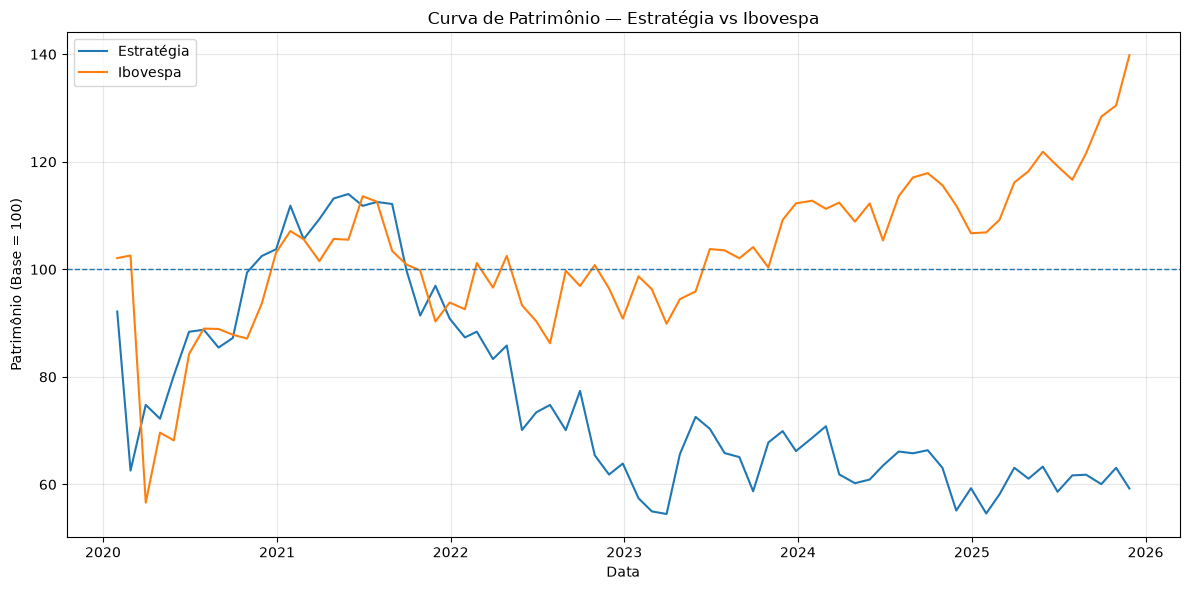

In [270]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

strategy_25 = portfolio_returns[
    ["date", "portfolio_return"]
].copy()

strategy_25["date"] = pd.to_datetime(strategy_25["date"])
strategy_25["portfolio_return"] = pd.to_numeric(
    strategy_25["portfolio_return"],
    errors="coerce"
)

strategy_25 = strategy_25.dropna(
    subset=["portfolio_return"]
).sort_values("date")

strategy_25["ano_mes"] = strategy_25["date"].dt.to_period("M")

strategy_25 = (
    strategy_25
    .drop_duplicates("ano_mes", keep="last")
    .reset_index(drop=True)
)

# diario -> mensal
ibov_25 = ibov[
    ["date", "close"]
].copy()

ibov_25["date"] = pd.to_datetime(ibov_25["date"])
ibov_25["close"] = pd.to_numeric(
    ibov_25["close"],
    errors="coerce"
)

ibov_25 = ibov_25.dropna(
    subset=["close"]
).sort_values("date")

ibov_25["ano_mes"] = ibov_25["date"].dt.to_period("M")

# ultimo fechamento disp de cada mes
ibov_monthly_25 = (
    ibov_25
    .groupby("ano_mes", as_index=False)
    .agg(
        date=("date", "last"),
        close=("close", "last")
    )
    .sort_values("ano_mes")
    .reset_index(drop=True)
)

# retorno mensal do Ibovespa
ibov_monthly_25["ibov_return"] = (
    ibov_monthly_25["close"].pct_change()
)

# merge - 1 linha por mes
comparison_25 = pd.merge(
    strategy_25[
        ["date", "ano_mes", "portfolio_return"]
    ],
    ibov_monthly_25[
        ["date", "ano_mes", "ibov_return"]
    ],
    on="ano_mes",
    how="inner",
    suffixes=("_strategy", "_ibov")
)

comparison_25 = (
    comparison_25
    .dropna(
        subset=[
            "portfolio_return",
            "ibov_return"
        ]
    )
    .sort_values("ano_mes")
    .reset_index(drop=True)
)

# curva de patrimonio
comparison_25["strategy_curve"] = (
    1 + comparison_25["portfolio_return"]
).cumprod()

comparison_25["ibov_curve"] = (
    1 + comparison_25["ibov_return"]
).cumprod()


comparison_25["strategy_100"] = (
    comparison_25["strategy_curve"] * 100
)

comparison_25["ibov_100"] = (
    comparison_25["ibov_curve"] * 100
)

strategy_cum = (
    comparison_25["strategy_curve"].iloc[-1] - 1
)

ibov_cum = (
    comparison_25["ibov_curve"].iloc[-1] - 1
)

n_months = len(comparison_25)

strategy_cagr = (
    (1 + strategy_cum) ** (12 / n_months) - 1
)

ibov_cagr = (
    (1 + ibov_cum) ** (12 / n_months) - 1
)

duplicated_months = (
    comparison_25["ano_mes"]
    .duplicated()
    .sum()
)


print("=== CURVA DE PATRIMÔNIO ===")

print("\n=== PERÍODO COMUM ===")
print(
    f"{comparison_25['date_strategy'].min().date()} "
    f"até "
    f"{comparison_25['date_strategy'].max().date()}"
)

print(f"Observações mensais: {n_months}")

print("\n=== AUDITORIA ===")
print(f"Meses duplicados: {duplicated_months}")

print("\n=== PERFORMANCE ===")
print(
    f"Estratégia — Retorno acumulado: "
    f"{strategy_cum:.2%}"
)

print(
    f"Ibovespa — Retorno acumulado: "
    f"{ibov_cum:.2%}"
)

print(
    f"Estratégia — CAGR: "
    f"{strategy_cagr:.2%}"
)

print(
    f"Ibovespa — CAGR: "
    f"{ibov_cagr:.2%}"
)

print("\n=== CURVA FINAL ===")
print(
    f"Estratégia: "
    f"{comparison_25['strategy_100'].iloc[-1]:.2f}"
)

print(
    f"Ibovespa: "
    f"{comparison_25['ibov_100'].iloc[-1]:.2f}"
)

print("\n=== PRIMEIROS 10 MESES ===")

print(
    comparison_25[
        [
            "ano_mes",
            "portfolio_return",
            "ibov_return",
            "strategy_100",
            "ibov_100"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n=== ÚLTIMOS 10 MESES ===")

print(
    comparison_25[
        [
            "ano_mes",
            "portfolio_return",
            "ibov_return",
            "strategy_100",
            "ibov_100"
        ]
    ]
    .tail(10)
    .to_string(index=False)
)

# plot
plt.figure(figsize=(12, 6))

plt.plot(
    comparison_25["date_strategy"],
    comparison_25["strategy_100"],
    label="Estratégia"
)

plt.plot(
    comparison_25["date_strategy"],
    comparison_25["ibov_100"],
    label="Ibovespa"
)

plt.axhline(
    100,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Curva de Patrimônio — Estratégia vs Ibovespa"
)

plt.xlabel("Data")
plt.ylabel("Patrimônio (Base = 100)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# stats
assert duplicated_months == 0, (
    "Erro: ainda existem meses duplicados."
)

assert n_months <= len(strategy_25), (
    "Erro: número de meses inconsistente."
)

=== DRAWDOWN ===

=== RESUMO ===
Período: 2020-01-31 até 2025-11-28
Observações: 71
Max Drawdown: -52.20%
Data do pior drawdown: 2023-03-31
Pico anterior: 2021-05-31
Recuperação: NÃO ocorreu até o final do backtest.

=== TOP 5 DRAWDOWNS ===
      date  drawdown
2023-03-31 -0.521955
2025-01-31 -0.521085
2023-02-28 -0.517685
2024-11-29 -0.516293
2023-01-31 -0.496277


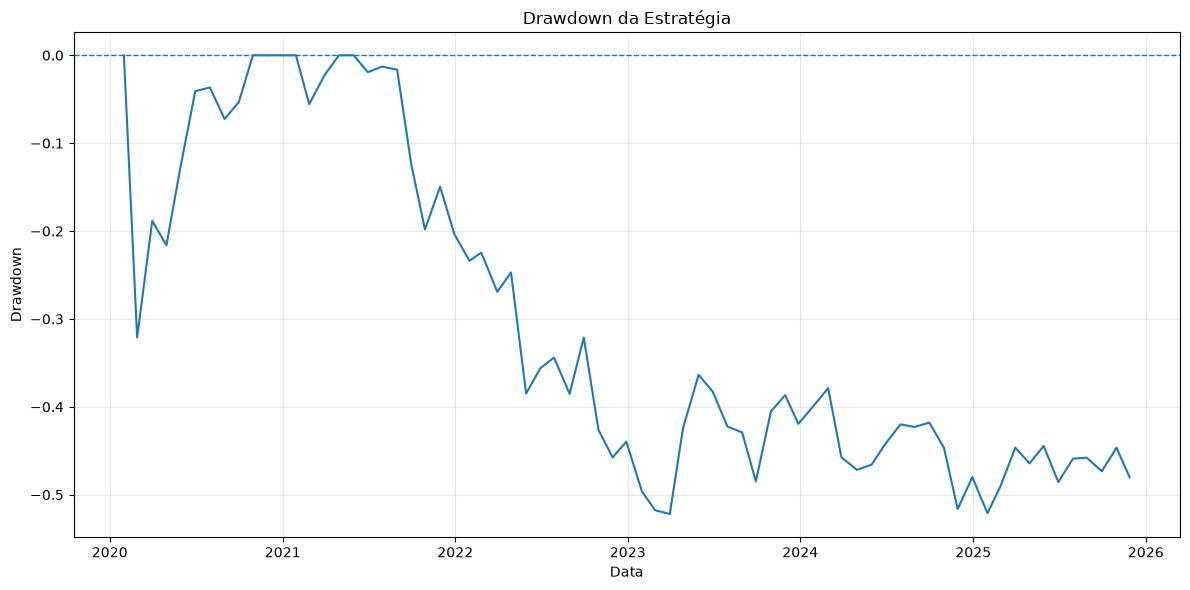

In [272]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

drawdown_26 = comparison_25[
    ["date_strategy", "strategy_curve"]
].copy()

drawdown_26 = drawdown_26.rename(
    columns={
        "date_strategy": "date",
        "strategy_curve": "equity"
    }
)

drawdown_26["date"] = pd.to_datetime(drawdown_26["date"])

# high water mark
drawdown_26["peak"] = (
    drawdown_26["equity"]
    .cummax()
)

drawdown_26["drawdown"] = (
    drawdown_26["equity"]
    / drawdown_26["peak"]
    - 1
)

# max drawdown
max_dd_idx = drawdown_26["drawdown"].idxmin()

max_dd = drawdown_26.loc[
    max_dd_idx,
    "drawdown"
]

max_dd_date = drawdown_26.loc[
    max_dd_idx,
    "date"
]

peak_before = drawdown_26.loc[
    :max_dd_idx,
    "peak"
].max()

peak_idx = drawdown_26.loc[
    :max_dd_idx,
    "equity"
].idxmax()

peak_date = drawdown_26.loc[
    peak_idx,
    "date"
]

# recuperacao
post_peak = drawdown_26.loc[
    max_dd_idx:
].copy()

recovery_rows = post_peak[
    post_peak["equity"] >= peak_before
]

if len(recovery_rows) > 0:
    recovery_date = recovery_rows.iloc[0]["date"]
    recovery_status = "SIM"
else:
    recovery_date = None
    recovery_status = "NÃO"

# top5 drawdowns
top5_dd = (
    drawdown_26[
        ["date", "drawdown"]
    ]
    .sort_values("drawdown")
    .head(5)
    .reset_index(drop=True)
)


print("=== DRAWDOWN ===")

print("\n=== RESUMO ===")

print(
    f"Período: "
    f"{drawdown_26['date'].min().date()} "
    f"até "
    f"{drawdown_26['date'].max().date()}"
)

print(
    f"Observações: {len(drawdown_26)}"
)

print(
    f"Max Drawdown: {max_dd:.2%}"
)

print(
    f"Data do pior drawdown: "
    f"{max_dd_date.date()}"
)

print(
    f"Pico anterior: "
    f"{peak_date.date()}"
)

if recovery_status == "SIM":

    print(
        f"Recuperação: SIM — "
        f"{recovery_date.date()}"
    )

else:

    print(
        "Recuperação: NÃO ocorreu até o final do backtest."
    )

print("\n=== TOP 5 DRAWDOWNS ===")

print(
    top5_dd.to_string(index=False)
)

# plot
plt.figure(figsize=(12, 6))

plt.plot(
    drawdown_26["date"],
    drawdown_26["drawdown"]
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "Drawdown da Estratégia"
)

plt.xlabel("Data")
plt.ylabel("Drawdown")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()
plt.show()

# verificacoes
assert max_dd <= 0
assert drawdown_26["drawdown"].max() <= 1e-12
assert drawdown_26["peak"].is_monotonic_increasing

In [275]:
import numpy as np
import pandas as pd

print("=== ROBUSTEZ DA ESTRATÉGIA ===")

robust_returns = portfolio_returns.copy()

robust_returns["date"] = pd.to_datetime(robust_returns["date"])
robust_returns = (
    robust_returns
    .sort_values("date")
    .drop_duplicates("date")
    .reset_index(drop=True)
)

r = robust_returns["portfolio_return"].dropna()

# func metricas
def calcular_metricas(retornos):
    retornos = pd.Series(retornos).dropna()

    if len(retornos) == 0:
        return {
            "observacoes": 0,
            "retorno_acumulado": np.nan,
            "cagr": np.nan,
            "volatilidade": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "pct_positivos": np.nan,
        }

    riqueza = (1 + retornos).cumprod()

    retorno_acumulado = riqueza.iloc[-1] - 1

    anos = len(retornos) / 12

    cagr = (
        riqueza.iloc[-1] ** (1 / anos) - 1
        if anos > 0 and riqueza.iloc[-1] > 0
        else np.nan
    )

    volatilidade = retornos.std(ddof=1) * np.sqrt(12)

    sharpe = (
        retornos.mean() / retornos.std(ddof=1) * np.sqrt(12)
        if retornos.std(ddof=1) > 0
        else np.nan
    )

    drawdown = riqueza / riqueza.cummax() - 1
    max_drawdown = drawdown.min()

    pct_positivos = (retornos > 0).mean()

    return {
        "observacoes": len(retornos),
        "retorno_acumulado": retorno_acumulado,
        "cagr": cagr,
        "volatilidade": volatilidade,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "pct_positivos": pct_positivos,
    }



metricas_base = calcular_metricas(r)

# sensibilidade a eventos extremos
cenarios = {
    "Base": r,
    "Sem 1 pior mês": r.drop(r.idxmin()),
    "Sem 1 melhor mês": r.drop(r.idxmax()),
    "Sem 1 pior e 1 melhor": r.drop(
        [r.idxmin(), r.idxmax()]
    ),
}

resultados = []

for nome, retornos in cenarios.items():

    m = calcular_metricas(retornos)

    resultados.append({
        "cenario": nome,
        **m
    })

robustez_df = pd.DataFrame(resultados)

# sensibilidade ao ano de 2020 (crise do COVID-19)
crise_2020 = robust_returns[
    robust_returns["date"].dt.year == 2020
]["portfolio_return"]

sem_2020 = robust_returns[
    robust_returns["date"].dt.year != 2020
]["portfolio_return"]

m_sem_2020 = calcular_metricas(sem_2020)

# sensibilidade aos últimos 24 meses
ultimos_24 = r.iloc[-24:]
m_ultimos_24 = calcular_metricas(ultimos_24)


print("\n=== CENÁRIOS DE ROBUSTEZ ===")

print(
    robustez_df[
        [
            "cenario",
            "observacoes",
            "retorno_acumulado",
            "cagr",
            "volatilidade",
            "sharpe",
            "max_drawdown",
            "pct_positivos",
        ]
    ].to_string(index=False)
)

print("\n=== SEM O ANO DE 2020 ===")

print(
    f"Observações: {m_sem_2020['observacoes']}"
)
print(
    f"Retorno acumulado: {m_sem_2020['retorno_acumulado']:.2%}"
)
print(
    f"CAGR: {m_sem_2020['cagr']:.2%}"
)
print(
    f"Volatilidade: {m_sem_2020['volatilidade']:.2%}"
)
print(
    f"Sharpe: {m_sem_2020['sharpe']:.4f}"
)
print(
    f"Max Drawdown: {m_sem_2020['max_drawdown']:.2%}"
)

print("\n=== ÚLTIMOS 24 MESES ===")

print(
    f"Retorno acumulado: {m_ultimos_24['retorno_acumulado']:.2%}"
)
print(
    f"CAGR: {m_ultimos_24['cagr']:.2%}"
)
print(
    f"Volatilidade: {m_ultimos_24['volatilidade']:.2%}"
)
print(
    f"Sharpe: {m_ultimos_24['sharpe']:.4f}"
)
print(
    f"Max Drawdown: {m_ultimos_24['max_drawdown']:.2%}"
)

=== ROBUSTEZ DA ESTRATÉGIA ===

=== CENÁRIOS DE ROBUSTEZ ===
              cenario  observacoes  retorno_acumulado      cagr  volatilidade    sharpe  max_drawdown  pct_positivos
                 Base           71          -0.407570 -0.084681      0.294554 -0.147156     -0.521955       0.521127
       Sem 1 pior mês           70          -0.127506 -0.023112      0.265048  0.041739     -0.521955       0.528571
     Sem 1 melhor mês           70          -0.508200 -0.114551      0.283497 -0.278809     -0.602433       0.514286
Sem 1 pior e 1 melhor           69          -0.275708 -0.054553      0.252697 -0.096409     -0.602433       0.521739

=== SEM O ANO DE 2020 ===
Observações: 59
Retorno acumulado: -42.89%
CAGR: -10.77%
Volatilidade: 25.35%
Sharpe: -0.3217
Max Drawdown: -52.20%

=== ÚLTIMOS 24 MESES ===
Retorno acumulado: -15.26%
CAGR: -7.95%
Volatilidade: 20.98%
Sharpe: -0.2900
Max Drawdown: -22.91%


In [277]:
import numpy as np
import pandas as pd

print("=== PERFORMANCE ANUAL ===")

annual_df = portfolio_returns.copy()

annual_df["date"] = pd.to_datetime(annual_df["date"])

annual_df = (
    annual_df[
        ["date", "portfolio_return"]
    ]
    .dropna(subset=["portfolio_return"])
    .sort_values("date")
    .drop_duplicates("date")
    .copy()
)

annual_df["year"] = annual_df["date"].dt.year

ibov_annual = ibov.copy()

ibov_annual["date"] = pd.to_datetime(ibov_annual["date"])

# recalcula o retorno mensal a partir do fechamento
ibov_annual = (
    ibov_annual
    .sort_values("date")
    .drop_duplicates("date")
    .copy()
)

ibov_annual["year"] = ibov_annual["date"].dt.year

# retorno mensal do ibovespa
ibov_annual["ibov_return"] = (
    ibov_annual["close"]
    .pct_change()
)

ibov_year = (
    ibov_annual
    .dropna(subset=["ibov_return"])
    .groupby("year")["ibov_return"]
    .apply(lambda x: (1 + x).prod() - 1)
    .rename("ibov_return")
    .reset_index()
)

strategy_year = (
    annual_df
    .groupby("year")["portfolio_return"]
    .apply(lambda x: (1 + x).prod() - 1)
    .rename("strategy_return")
    .reset_index()
)

# merge anual
performance_anual = (
    strategy_year
    .merge(
        ibov_year,
        on="year",
        how="inner"
    )
    .sort_values("year")
    .reset_index(drop=True)
)

# retorno exc
performance_anual["excess_return"] = (
    performance_anual["strategy_return"]
    - performance_anual["ibov_return"]
)

# classificacao
performance_anual["estrategia_positiva"] = (
    performance_anual["strategy_return"] > 0
)

performance_anual["ibov_positivo"] = (
    performance_anual["ibov_return"] > 0
)

performance_anual["outperformou_ibov"] = (
    performance_anual["strategy_return"]
    > performance_anual["ibov_return"]
)

# estatisticas
anos = len(performance_anual)

anos_positivos = (
    performance_anual["estrategia_positiva"].sum()
)

anos_negativos = (
    anos - anos_positivos
)

anos_outperform = (
    performance_anual["outperformou_ibov"].sum()
)


melhor_ano = performance_anual.loc[
    performance_anual["strategy_return"].idxmax()
]

pior_ano = performance_anual.loc[
    performance_anual["strategy_return"].idxmin()
]


print("\n=== PERFORMANCE POR ANO ===")

print(
    performance_anual[
        [
            "year",
            "strategy_return",
            "ibov_return",
            "excess_return"
        ]
    ].to_string(index=False)
)

print("\n=== RESUMO ===")

print(f"Anos analisados: {anos}")
print(f"Anos positivos da estratégia: {anos_positivos}")
print(f"Anos negativos da estratégia: {anos_negativos}")
print(
    f"% anos positivos: "
    f"{anos_positivos / anos:.2%}"
)
print(
    f"Anos em que superou o Ibovespa: "
    f"{anos_outperform}"
)
print(
    f"% anos superando o Ibovespa: "
    f"{anos_outperform / anos:.2%}"
)

print("\n=== MELHOR ANO ===")

print(
    f"{int(melhor_ano['year'])}: "
    f"{melhor_ano['strategy_return']:.2%}"
)

print("\n=== PIOR ANO ===")

print(
    f"{int(pior_ano['year'])}: "
    f"{pior_ano['strategy_return']:.2%}"
)

print("\n=== AUDITORIA ===")

print(
    f"Anos estratégia: "
    f"{performance_anual['year'].tolist()}"
)

print(
    f"Duplicidade de anos: "
    f"{performance_anual['year'].duplicated().sum()}"
)

=== PERFORMANCE ANUAL ===

=== PERFORMANCE POR ANO ===
 year  strategy_return  ibov_return  excess_return
 2020         0.037293     0.031169       0.006123
 2021        -0.124348    -0.090035      -0.034313
 2022        -0.296673    -0.031937      -0.264736
 2023         0.036203     0.235889      -0.199687
 2024        -0.104338    -0.049443      -0.054895
 2025        -0.000787     0.328673      -0.329461

=== RESUMO ===
Anos analisados: 6
Anos positivos da estratégia: 2
Anos negativos da estratégia: 4
% anos positivos: 33.33%
Anos em que superou o Ibovespa: 1
% anos superando o Ibovespa: 16.67%

=== MELHOR ANO ===
2020: 3.73%

=== PIOR ANO ===
2022: -29.67%

=== AUDITORIA ===
Anos estratégia: [2020, 2021, 2022, 2023, 2024, 2025]
Duplicidade de anos: 0


In [280]:
import numpy as np
import pandas as pd

print("=== CONTRIBUIÇÃO DOS FATORES ===")

factors_df = panel_final.copy()

factors_df["date"] = pd.to_datetime(factors_df["date"])

# id col fatores
colunas_fatores = [
    "z_momentum",
    "z_risk"
]

colunas_disponiveis = [
    c for c in colunas_fatores
    if c in factors_df.columns
]

print("\n=== FATORES DISPONÍVEIS ===")
print(colunas_disponiveis)

if len(colunas_disponiveis) == 0:
    raise ValueError(
        "Nenhuma coluna de fator encontrada em panel_final."
    )


print("\n=== ESTATÍSTICAS DOS FATORES ===")

for fator in colunas_disponiveis:

    serie = factors_df[fator].dropna()

    print(f"\n{fator}")
    print(f"Observações: {len(serie)}")
    print(f"Média: {serie.mean():.6f}")
    print(f"Mediana: {serie.median():.6f}")
    print(f"Desvio padrão: {serie.std():.6f}")
    print(f"Mínimo: {serie.min():.6f}")
    print(f"Máximo: {serie.max():.6f}")


print("\n=== CORRELAÇÃO ENTRE FATORES ===")

if len(colunas_disponiveis) >= 2:

    correlacao_fatores = (
        factors_df[colunas_disponiveis]
        .corr()
    )

    print(correlacao_fatores)

else:
    correlacao_fatores = pd.DataFrame()


print("\n=== CONTRIBUIÇÃO MÉDIA ===")

contribuicao = pd.DataFrame(index=colunas_disponiveis)

for fator in colunas_disponiveis:
    contribuicao.loc[fator, "media"] = (
        factors_df[fator].mean()
    )
    contribuicao.loc[fator, "media_abs"] = (
        factors_df[fator].abs().mean()
    )

print(contribuicao)

if "factor_score_final" in factors_df.columns:

    print("\n=== FACTOR SCORE FINAL ===")

    print(
        factors_df["factor_score_final"]
        .describe()
        .to_string()
    )


print("\n=== CORRELAÇÃO COM FACTOR SCORE ===")

if "factor_score_final" in factors_df.columns:

    correlacoes_score = {}

    for fator in colunas_disponiveis:

        temp = factors_df[
            [fator, "factor_score_final"]
        ].dropna()

        if len(temp) > 1:
            correlacoes_score[fator] = (
                temp[fator]
                .corr(temp["factor_score_final"])
            )

    correlacoes_score = pd.Series(
        correlacoes_score,
        name="correlacao"
    )

    print(correlacoes_score)


print("\n=== AUDITORIA ===")

if "z_momentum" in factors_df.columns:
    print(
        "Momentum disponível"
    )

if "z_risk" in factors_df.columns:
    print(
        "Risk disponível"
    )

if "factor_score_final" in factors_df.columns:
    print(
        "Factor score final disponível"
    )

print(
    f"Observações panel_final: {len(factors_df)}"
)

print(
    f"Datas únicas: {factors_df['date'].nunique()}"
)

print(
    f"Duplicidades ticker × date: "
    f"{factors_df.duplicated(['ticker', 'date']).sum()}"
)

=== CONTRIBUIÇÃO DOS FATORES ===

=== FATORES DISPONÍVEIS ===
['z_momentum', 'z_risk']

=== ESTATÍSTICAS DOS FATORES ===

z_momentum
Observações: 2725
Média: -0.000000
Mediana: 0.000000
Desvio padrão: 0.920480
Mínimo: -2.045726
Máximo: 2.877533

z_risk
Observações: 2802
Média: -0.000000
Mediana: 0.209871
Desvio padrão: 0.969731
Mínimo: -3.455826
Máximo: 1.604540

=== CORRELAÇÃO ENTRE FATORES ===
            z_momentum    z_risk
z_momentum    1.000000  0.252512
z_risk        0.252512  1.000000

=== CONTRIBUIÇÃO MÉDIA ===
                   media  media_abs
z_momentum  5.214993e-18   0.677575
z_risk     -4.057346e-17   0.777632

=== FACTOR SCORE FINAL ===
count    2383.000000
mean       -0.003100
std         0.596002
min        -1.461677
25%        -0.411843
50%        -0.091648
75%         0.323917
max         2.397458

=== CORRELAÇÃO COM FACTOR SCORE ===
z_momentum    0.606681
z_risk       -0.605161
Name: correlacao, dtype: float64

=== AUDITORIA ===
Momentum disponível
Risk disponível

In [282]:
import pandas as pd
import numpy as np

print("=== CONCENTRAÇÃO DO TOP 10 ===")

top10_audit = top10_final.copy()

top10_audit["date"] = pd.to_datetime(top10_audit["date"])

top10_audit = (
    top10_audit
    .sort_values(["date", "rank_final"])
    .reset_index(drop=True)
)

frequencia_tickers = (
    top10_audit
    .groupby("ticker")
    .agg(
        vezes_selecionado=("ticker", "size"),
        primeira_selecao=("date", "min"),
        ultima_selecao=("date", "max"),
        rank_medio=("rank_final", "mean")
    )
    .sort_values(
        ["vezes_selecionado", "rank_medio"],
        ascending=[False, True]
    )
    .reset_index()
)

# % participacao
total_selecoes = len(top10_audit)

frequencia_tickers["participacao_top10"] = (
    frequencia_tickers["vezes_selecionado"]
    / total_selecoes
)


print("\n=== TOP 20 ATIVOS MAIS SELECIONADOS ===")

print(
    frequencia_tickers
    .head(20)
    .to_string(index=False)
)


top5_selecoes = (
    frequencia_tickers
    .head(5)["vezes_selecionado"]
    .sum()
)

top10_selecoes = (
    frequencia_tickers
    .head(10)["vezes_selecionado"]
    .sum()
)

print("\n=== CONCENTRAÇÃO ===")

print(
    f"Seleções totais: {total_selecoes}"
)

print(
    f"Tickers únicos selecionados: "
    f"{frequencia_tickers['ticker'].nunique()}"
)

print(
    f"Participação dos 5 maiores: "
    f"{top5_selecoes / total_selecoes:.2%}"
)

print(
    f"Participação dos 10 maiores: "
    f"{top10_selecoes / total_selecoes:.2%}"
)


acoes_mes = (
    top10_audit
    .groupby("date")["ticker"]
    .nunique()
)

print("\n=== DIVERSIFICAÇÃO MENSAL ===")

print(
    f"Média de ações/mês: "
    f"{acoes_mes.mean():.2f}"
)

print(
    f"Mínimo de ações/mês: "
    f"{acoes_mes.min()}"
)

print(
    f"Máximo de ações/mês: "
    f"{acoes_mes.max()}"
)

print("\n=== PESOS ===")

if "peso" in top10_audit.columns:

    peso_medio = (
        top10_audit
        .groupby("ticker")["peso"]
        .mean()
        .sort_values(ascending=False)
    )

    print(
        peso_medio.head(10).to_string()
    )

print("\n=== AUDITORIA ===")

print(
    f"Observações top10_final: {len(top10_audit)}"
)

print(
    f"Datas únicas: {top10_audit['date'].nunique()}"
)

print(
    f"Duplicidades ticker × date: "
    f"{top10_audit.duplicated(['ticker', 'date']).sum()}"
)

=== CONCENTRAÇÃO DO TOP 10 ===

=== TOP 20 ATIVOS MAIS SELECIONADOS ===
ticker  vezes_selecionado primeira_selecao ultima_selecao  rank_medio  participacao_top10
 AZUL4                 56       2020-01-31     2025-07-31    5.285714            0.078984
 EMBR3                 50       2020-07-31     2025-09-30    3.100000            0.070522
 POMO4                 42       2020-02-28     2025-11-28    5.095238            0.059238
 BRFS3                 40       2020-01-31     2025-08-29    5.000000            0.056417
 BEEF3                 38       2020-01-31     2025-11-28    4.605263            0.053597
 BRKM5                 37       2020-04-30     2025-02-28    5.513514            0.052186
 WEGE3                 36       2020-01-31     2025-05-30    4.611111            0.050776
 LWSA3                 36       2021-02-26     2025-09-30    6.361111            0.050776
 TOTS3                 28       2020-01-31     2025-11-28    5.678571            0.039492
 ALPA4                 28   

In [285]:
import pandas as pd
import numpy as np

print("=== ATRIBUIÇAO DE PERFORMANCE ===")

attr = top10_final.copy()

# id retorno dos ativos
return_col = "ret_next"

if return_col not in attr.columns:
    raise ValueError(
        f"Coluna '{return_col}' não encontrada. "
        f"Colunas disponíveis: {attr.columns.tolist()}"
    )

# retorno ponderado de cada contribuicao
attr["contribuicao"] = (
    attr["peso"] * attr[return_col]
)

contrib_ticker = (
    attr.groupby("ticker")
        .agg(
            observacoes=("ticker", "size"),
            contribuicao_total=("contribuicao", "sum"),
            contribuicao_media=("contribuicao", "mean"),
            retorno_medio_ativo=(return_col, "mean"),
        )
        .sort_values(
            "contribuicao_total",
            ascending=False
        )
        .reset_index()
)


contrib_mensal = (
    attr.groupby("date")
        .agg(
            retorno_portfolio_atribuido=("contribuicao", "sum"),
            n_acoes=("ticker", "count"),
        )
        .reset_index()
        .sort_values("date")
)

# participacao na contribuicao absoluta
total_abs = contrib_ticker["contribuicao_total"].abs().sum()

if total_abs > 0:
    contrib_ticker["participacao_abs"] = (
        contrib_ticker["contribuicao_total"].abs()
        / total_abs
    )
else:
    contrib_ticker["participacao_abs"] = np.nan

# top 10 contribuidores de performance
top_contrib_positiva = (
    contrib_ticker[
        contrib_ticker["contribuicao_total"] > 0
    ]
    .sort_values(
        "contribuicao_total",
        ascending=False
    )
    .head(10)
)

# top 10 destruidores de performance
top_contrib_negativa = (
    contrib_ticker[
        contrib_ticker["contribuicao_total"] < 0
    ]
    .sort_values(
        "contribuicao_total",
        ascending=True
    )
    .head(10)
)


print("\n=== COLUNAS UTILIZADAS ===")
print(f"Retorno dos ativos: {return_col}")
print("Peso: peso")
print("Ticker: ticker")
print("Data: date")

print("\n=== CONTRIBUIÇÃO TOTAL ===")
print(
    f"{contrib_ticker['contribuicao_total'].sum():.6f}"
)

print("\n=== RETORNO DA ESTRATÉGIA ===")
print(
    f"{portfolio_returns['portfolio_return'].sum():.6f}"
)

print("\n=== TOP 10 CONTRIBUIDORES POSITIVOS ===")
print(top_contrib_positiva.to_string(index=False))

print("\n=== TOP 10 DESTRUIDORES DE PERFORMANCE ===")
print(top_contrib_negativa.to_string(index=False))

print("\n=== CONTRIBUIÇÃO POR TICKER ===")
print(contrib_ticker.head(20).to_string(index=False))

print("\n=== AUDITORIA ESTRUTURAL ===")
print(f"Observações top10_final: {len(attr)}")
print(f"Tickers únicos: {attr['ticker'].nunique()}")
print(f"Datas únicas: {attr['date'].nunique()}")
print(
    f"Duplicidades ticker × date: "
    f"{attr.duplicated(['ticker', 'date']).sum()}"
)

=== ATRIBUIÇAO DE PERFORMANCE ===

=== COLUNAS UTILIZADAS ===
Retorno dos ativos: ret_next
Peso: peso
Ticker: ticker
Data: date

=== CONTRIBUIÇÃO TOTAL ===
-0.256460

=== RETORNO DA ESTRATÉGIA ===
-0.256460

=== TOP 10 CONTRIBUIDORES POSITIVOS ===
ticker  observacoes  contribuicao_total  contribuicao_media  retorno_medio_ativo  participacao_abs
 EMBR3           50            0.152720            0.003054             0.030544          0.130335
 BRFS3           40            0.046311            0.001158             0.011578          0.039523
 CSAN3           17            0.045138            0.002655             0.026552          0.038522
 NEOE3           10            0.035695            0.003569             0.035695          0.030463
 POMO4           42            0.030056            0.000716             0.007156          0.025650
 SLCE3           25            0.029169            0.001167             0.011668          0.024894
 JBSS3           23            0.021397            0.000930

In [288]:
import pandas as pd
import numpy as np

print("=== PERFORMANCE POR REGIME DE MERCADO ===")

regime = portfolio_returns[
    ["date", "portfolio_return"]
].copy()

regime["date"] = pd.to_datetime(regime["date"])


# dataframe com ibov return
ibov_data = None

for nome, obj in globals().items():

    if isinstance(obj, pd.DataFrame):

        if "ibov_return" in obj.columns:

            if "date" in obj.columns:

                temp = obj[
                    ["date", "ibov_return"]
                ].copy()

                temp["date"] = pd.to_datetime(
                    temp["date"]
                )

                ibov_data = temp

                print(
                    f"Ibovespa encontrado no objeto: {nome}"
                )

                break


if ibov_data is None:

    raise ValueError(
        "Não encontrei nenhum DataFrame com 'ibov_return' e 'date'."
    )


ibov_data["ano_mes"] = (
    ibov_data["date"]
    .dt.to_period("M")
)

regime["ano_mes"] = (
    regime["date"]
    .dt.to_period("M")
)

ibov_data = (
    ibov_data
    .sort_values("date")
    .drop_duplicates("ano_mes", keep="last")
)


# merge ano/mes
regime = regime.merge(
    ibov_data[
        ["ano_mes", "ibov_return"]
    ],
    on="ano_mes",
    how="left"
)


if regime["ibov_return"].isna().any():

    print("\n⚠️ Meses sem retorno do Ibovespa:")

    print(
        regime[
            regime["ibov_return"].isna()
        ][
            ["date", "ano_mes"]
        ]
    )

    regime = regime.dropna(
        subset=["ibov_return"]
    )



regime["regime"] = np.where(
    regime["ibov_return"] >= 0,
    "Ibovespa positivo",
    "Ibovespa negativo"
)


regime["excess_return"] = (
    regime["portfolio_return"]
    - regime["ibov_return"]
)


# func metricas
def calcular_metricas(r):

    r = r.dropna()

    n = len(r)

    retorno_acum = (
        (1 + r).prod() - 1
    )

    anos = n / 12

    if anos > 0 and (1 + retorno_acum) > 0:

        cagr = (
            (1 + retorno_acum) ** (1 / anos)
            - 1
        )

    else:
        cagr = np.nan

    vol = (
        r.std(ddof=1) * np.sqrt(12)
        if len(r) > 1
        else np.nan
    )

    sharpe = (
        r.mean() / r.std(ddof=1) * np.sqrt(12)
        if len(r) > 1 and r.std(ddof=1) > 0
        else np.nan
    )

    patrimonio = (1 + r).cumprod()

    drawdown = (
        patrimonio /
        patrimonio.cummax()
        - 1
    )

    return pd.Series({

        "observacoes": n,

        "retorno_acumulado":
            retorno_acum,

        "cagr":
            cagr,

        "volatilidade":
            vol,

        "sharpe":
            sharpe,

        "max_drawdown":
            drawdown.min(),

        "pct_positivos":
            (r > 0).mean()
    })


# performance por regime
metricas_regime = (
    regime
    .groupby("regime")["portfolio_return"]
    .apply(calcular_metricas)
    .unstack()
    .reset_index()
)


# alpha medio por regime
alpha_regime = (
    regime
    .groupby("regime")["excess_return"]
    .mean()
    .reset_index(
        name="alpha_medio_mensal"
    )
)

metricas_regime = metricas_regime.merge(
    alpha_regime,
    on="regime",
    how="left"
)


# retorno medio ibov
ibov_regime = (
    regime
    .groupby("regime")["ibov_return"]
    .mean()
    .reset_index(
        name="ibov_retorno_medio"
    )
)

metricas_regime = metricas_regime.merge(
    ibov_regime,
    on="regime",
    how="left"
)


print("\n=== DISTRIBUIÇÃO DOS REGIMES ===")

print(
    regime["regime"]
    .value_counts()
    .sort_index()
)


print("\n=== PERFORMANCE POR REGIME ===")

print(
    metricas_regime.to_string(
        index=False
    )
)


print("\n=== AMOSTRA ===")

print(
    regime[
        [
            "date",
            "portfolio_return",
            "ibov_return",
            "regime",
            "excess_return"
        ]
    ]
    .head(10)
    .to_string(index=False)
)

print("\n=== AUDITORIA ===")

print(
    f"Observações estratégia: "
    f"{len(portfolio_returns)}"
)

print(
    f"Observações após merge: "
    f"{len(regime)}"
)

print(
    f"Datas únicas: "
    f"{regime['date'].nunique()}"
)

print(
    f"Duplicidades de data: "
    f"{regime.duplicated('date').sum()}"
)

print(
    f"Meses sem Ibovespa: "
    f"{regime['ibov_return'].isna().sum()}"
)

print(
    f"Regimes identificados: "
    f"{regime['regime'].nunique()}"
)

=== PERFORMANCE POR REGIME DE MERCADO ===
Ibovespa encontrado no objeto: comparacao

=== DISTRIBUIÇÃO DOS REGIMES ===
regime
Ibovespa negativo    35
Ibovespa positivo    36
Name: count, dtype: int64

=== PERFORMANCE POR REGIME ===
           regime  observacoes  retorno_acumulado      cagr  volatilidade    sharpe  max_drawdown  pct_positivos  alpha_medio_mensal  ibov_retorno_medio
Ibovespa negativo         35.0           0.084364  0.028158      0.282916  0.234912     -0.367823       0.514286            0.048631           -0.043093
Ibovespa positivo         36.0          -0.453661 -0.182501      0.306247 -0.490130     -0.423818       0.527778           -0.065872            0.053364

=== AMOSTRA ===
      date  portfolio_return  ibov_return            regime  excess_return
2020-01-31         -0.078537     0.020873 Ibovespa positivo      -0.099410
2020-02-28         -0.320993     0.004708 Ibovespa positivo      -0.325701
2020-03-31          0.195317    -0.448042 Ibovespa negativo       0.

In [290]:
import pandas as pd
import numpy as np

print("=== ESTABILIDADE DOS FATORES ===")

estabilidade = panel_final.copy()

estabilidade["date"] = pd.to_datetime(
    estabilidade["date"]
)

estabilidade["ano"] = (
    estabilidade["date"].dt.year
)


fatores = [
    col for col in [
        "z_momentum",
        "z_quality",
        "z_risk"
    ]
    if col in estabilidade.columns
]

print("\n=== FATORES ===")
print(fatores)


estatisticas_anuais = []

for fator in fatores:

    temp = (
        estabilidade[
            ["ano", fator]
        ]
        .dropna()
    )

    if temp.empty:
        continue

    grupo = (
        temp
        .groupby("ano")[fator]
        .agg(
            observacoes="count",
            media="mean",
            mediana="median",
            desvio_padrao="std",
            minimo="min",
            maximo="max"
        )
        .reset_index()
    )

    grupo["fator"] = fator

    estatisticas_anuais.append(
        grupo
    )

if estatisticas_anuais:

    estabilidade_fatores = pd.concat(
        estatisticas_anuais,
        ignore_index=True
    )

else:

    estabilidade_fatores = pd.DataFrame()


# correlacao factor vs factor score
correlacoes = []

if "factor_score_final" in estabilidade.columns:

    for fator in fatores:

        temp = estabilidade[
            [fator, "factor_score_final"]
        ].dropna()

        if len(temp) > 1:

            correlacao = temp[
                fator
            ].corr(
                temp["factor_score_final"]
            )

            correlacoes.append({
                "fator": fator,
                "correlacao_factor_score":
                    correlacao
            })

correlacoes = pd.DataFrame(
    correlacoes
)


# media absoluta dos fatores por ano
medias_abs = []

for fator in fatores:

    temp = (
        estabilidade[
            ["ano", fator]
        ]
        .dropna()
    )

    if temp.empty:
        continue

    grupo = (
        temp
        .groupby("ano")[fator]
        .apply(lambda x: x.abs().mean())
        .reset_index(
            name="media_absoluta"
        )
    )

    grupo["fator"] = fator

    medias_abs.append(
        grupo
    )

if medias_abs:

    estabilidade_abs = pd.concat(
        medias_abs,
        ignore_index=True
    )

else:

    estabilidade_abs = pd.DataFrame()


print("\n=== ESTATÍSTICAS ANUAIS ===")

if not estabilidade_fatores.empty:

    print(
        estabilidade_fatores.to_string(
            index=False
        )
    )

else:

    print("Nenhum fator disponível.")


print("\n=== CORRELAÇÃO COM FACTOR SCORE ===")

if not correlacoes.empty:

    print(
        correlacoes.to_string(
            index=False
        )
    )

else:

    print("Correlação não disponível.")


print("\n=== MÉDIA ABSOLUTA POR ANO ===")

if not estabilidade_abs.empty:

    print(
        estabilidade_abs.to_string(
            index=False
        )
    )


print("\n=== AUDITORIA ===")

print(
    f"Observações panel_final: "
    f"{len(estabilidade)}"
)

print(
    f"Datas únicas: "
    f"{estabilidade['date'].nunique()}"
)

print(
    f"Anos analisados: "
    f"{estabilidade['ano'].nunique()}"
)

print(
    f"Fatores analisados: "
    f"{len(fatores)}"
)

print(
    f"Duplicidades ticker × date: "
    f"{estabilidade.duplicated(['ticker', 'date']).sum()}"
)

=== ESTABILIDADE DOS FATORES ===

=== FATORES ===
['z_momentum', 'z_quality', 'z_risk']

=== ESTATÍSTICAS ANUAIS ===
 ano  observacoes         media   mediana  desvio_padrao    minimo   maximo      fator
2019          342  0.000000e+00  0.000000       0.000000  0.000000 0.000000 z_momentum
2020          342 -1.038805e-17 -0.153475       0.983739 -1.720679 2.275761 z_momentum
2021          369 -1.203494e-17 -0.173678       0.984941 -1.748267 2.474621 z_momentum
2022          403  1.542742e-17  0.078798       0.986224 -2.045726 2.515271 z_momentum
2023          420  2.643388e-19  0.020842       0.986786 -1.877009 2.251286 z_momentum
2024          423 -3.674497e-18 -0.094285       0.986881 -1.863286 2.877533 z_momentum
2025          426  9.382166e-18 -0.023740       0.983391 -2.018150 2.369120 z_momentum
2019          342  0.000000e+00  0.000000       0.000000  0.000000 0.000000  z_quality
2020          369  0.000000e+00  0.000000       0.000000  0.000000 0.000000  z_quality
2021         

In [292]:
import numpy as np
import pandas as pd

df = panel_final.copy()

df["date"] = pd.to_datetime(df["date"])

# garantir retorno no futuro disponivel
df = df.dropna(subset=["ret_next"]).copy()


cenarios = {
    "Momentum 100%": {"momentum": 1.0, "risk": 0.0},
    "Momentum 75% / Risk 25%": {"momentum": 0.75, "risk": 0.25},
    "Momentum 50% / Risk 50%": {"momentum": 0.50, "risk": 0.50},
    "Momentum 25% / Risk 75%": {"momentum": 0.25, "risk": 0.75},
    "Risk 100%": {"momentum": 0.0, "risk": 1.0},
}

resultados = []


def calcular_metricas(retornos):

    retornos = pd.Series(retornos).dropna()

    n = len(retornos)

    if n == 0:
        return {
            "observacoes": 0,
            "retorno_acumulado": np.nan,
            "cagr": np.nan,
            "volatilidade": np.nan,
            "sharpe": np.nan,
            "max_drawdown": np.nan,
            "pct_positivos": np.nan,
        }

    acumulado = (1 + retornos).prod() - 1

    anos = n / 12

    cagr = (1 + acumulado) ** (1 / anos) - 1 if anos > 0 else np.nan

    volatilidade = retornos.std(ddof=1) * np.sqrt(12)

    sharpe = (
        retornos.mean() / retornos.std(ddof=1) * np.sqrt(12)
        if retornos.std(ddof=1) != 0
        else np.nan
    )

    curva = (1 + retornos).cumprod()

    drawdown = curva / curva.cummax() - 1

    max_drawdown = drawdown.min()

    pct_positivos = (retornos > 0).mean()

    return {
        "observacoes": n,
        "retorno_acumulado": acumulado,
        "cagr": cagr,
        "volatilidade": volatilidade,
        "sharpe": sharpe,
        "max_drawdown": max_drawdown,
        "pct_positivos": pct_positivos,
    }

# calc score para cada cenario
for nome, pesos in cenarios.items():

    temp = df.copy()

    temp["score_sensibilidade"] = (
        pesos["momentum"] * temp["z_momentum"].fillna(0)
        - pesos["risk"] * temp["z_risk"].fillna(0)
    )

    #somente obs com fatores necessarios
    temp = temp[
        temp["z_momentum"].notna() &
        temp["z_risk"].notna()
    ].copy()

    # ranking mensal
    temp["rank"] = (
        temp.groupby("date")["score_sensibilidade"]
        .rank(method="first", ascending=False)
    )

    top = temp[temp["rank"] <= 10].copy()

    # retorno ponderado
    retornos_mensais = (
        top.groupby("date")
        .apply(
            lambda x: np.average(
                x["ret_next"],
                weights=np.ones(len(x)) / len(x)
            )
        )
        .rename("portfolio_return")
        .reset_index()
    )

    metricas = calcular_metricas(
        retornos_mensais["portfolio_return"]
    )

    metricas["cenario"] = nome
    metricas["peso_momentum"] = pesos["momentum"]
    metricas["peso_risk"] = pesos["risk"]

    resultados.append(metricas)


sensibilidade_pesos = pd.DataFrame(resultados)

sensibilidade_pesos = sensibilidade_pesos[
    [
        "cenario",
        "peso_momentum",
        "peso_risk",
        "observacoes",
        "retorno_acumulado",
        "cagr",
        "volatilidade",
        "sharpe",
        "max_drawdown",
        "pct_positivos",
    ]
].sort_values(
    "sharpe",
    ascending=False
).reset_index(drop=True)


print("=== SENSIBILIDADE DOS PESOS ===")

print("\n=== CENÁRIOS ===")

print(
    sensibilidade_pesos.to_string(
        index=False,
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)

print("\n=== MELHOR CENÁRIO POR SHARPE ===")

melhor = sensibilidade_pesos.iloc[0]

print(f"Cenário: {melhor['cenario']}")
print(f"Sharpe: {melhor['sharpe']:.4f}")
print(f"Retorno acumulado: {melhor['retorno_acumulado']:.2%}")
print(f"CAGR: {melhor['cagr']:.2%}")
print(f"Max Drawdown: {melhor['max_drawdown']:.2%}")

print("\n=== AUDITORIA ===")

print(
    f"Observações panel_final: {len(panel_final)}"
)

print(
    f"Datas únicas panel_final: {panel_final['date'].nunique()}"
)

print(
    f"Duplicidades ticker × date: "
    f"{panel_final.duplicated(['ticker', 'date']).sum()}"
)

=== SENSIBILIDADE DOS PESOS ===

=== CENÁRIOS ===
                cenario  peso_momentum  peso_risk  observacoes retorno_acumulado   cagr volatilidade  sharpe max_drawdown pct_positivos
          Momentum 100%           1.00       0.00           83            35.66%  4.51%       22.74%  0.3133      -38.22%        54.22%
Momentum 75% / Risk 25%           0.75       0.25           83            22.50%  2.98%       23.55%  0.2474      -39.45%        57.83%
Momentum 50% / Risk 50%           0.50       0.50           83           -20.15% -3.20%       28.18%  0.0303      -52.20%        54.22%
              Risk 100%           0.00       1.00           83           -33.55% -5.74%       30.70% -0.0382      -58.23%        53.01%
Momentum 25% / Risk 75%           0.25       0.75           83           -37.95% -6.67%       31.09% -0.0640      -60.52%        53.01%

=== MELHOR CENÁRIO POR SHARPE ===
Cenário: Momentum 100%
Sharpe: 0.3133
Retorno acumulado: 35.66%
CAGR: 4.51%
Max Drawdown: -38.22%



In [294]:
import numpy as np
import pandas as pd

print("=== COMPARAÇÃO COM BUY & HOLD ===")

estrategia = portfolio_returns.copy()

estrategia["date"] = pd.to_datetime(estrategia["date"])

estrategia = (
    estrategia[
        ["date", "portfolio_return"]
    ]
    .drop_duplicates("date")
    .sort_values("date")
    .copy()
)

# id retorno ibovespa
if "comparacao" in globals():

    ibov_base = comparacao.copy()

    ibov_base["date"] = pd.to_datetime(ibov_base["date"])

    if "ibov_return" in ibov_base.columns:
        ibov_col = "ibov_return"
    else:
        ibov_col = None

else:
    ibov_base = None
    ibov_col = None


if ibov_col is None:

    if "ibov" in globals():

        ibov_base = ibov.copy()

        ibov_base["date"] = pd.to_datetime(ibov_base["date"])

        ibov_base = ibov_base.sort_values("date").copy()

        ibov_base["ibov_return"] = (
            ibov_base["close"].pct_change()
        )

        ibov_base["ano_mes"] = (
            ibov_base["date"].dt.to_period("M")
        )

        ibov_base = (
            ibov_base
            .groupby("ano_mes", as_index=False)
            .agg(
                date=("date", "last"),
                ibov_return=("ibov_return", "last")
            )
        )

        ibov_col = "ibov_return"

    else:

        raise ValueError(
            "Não encontrei objeto 'comparacao' nem 'ibov' "
            "para calcular o benchmark."
        )

# norm ibovespa
ibov_base["date"] = pd.to_datetime(
    ibov_base["date"]
)

ibov_base["ano_mes"] = (
    ibov_base["date"].dt.to_period("M")
)

estrategia["ano_mes"] = (
    estrategia["date"].dt.to_period("M")
)

ibov_mensal = (
    ibov_base
    .groupby("ano_mes", as_index=False)
    .agg(
        ibov_return=(ibov_col, "last")
    )
)

# merge mensal
comparacao_bh = estrategia.merge(
    ibov_mensal,
    on="ano_mes",
    how="inner"
)

comparacao_bh = comparacao_bh.sort_values(
    "ano_mes"
).reset_index(drop=True)

# curvas de patrimonio
comparacao_bh["estrategia_100"] = (
    100 *
    (1 + comparacao_bh["portfolio_return"]).cumprod()
)

comparacao_bh["ibov_100"] = (
    100 *
    (1 + comparacao_bh["ibov_return"]).cumprod()
)

# metricas
def metricas_buy_hold(retornos):

    retornos = pd.Series(retornos).dropna()

    n = len(retornos)

    acumulado = (
        (1 + retornos).prod() - 1
    )

    anos = n / 12

    cagr = (
        (1 + acumulado) ** (1 / anos) - 1
        if anos > 0
        else np.nan
    )

    vol = (
        retornos.std(ddof=1) *
        np.sqrt(12)
    )

    sharpe = (
        retornos.mean() /
        retornos.std(ddof=1) *
        np.sqrt(12)
        if retornos.std(ddof=1) != 0
        else np.nan
    )

    curva = (1 + retornos).cumprod()

    drawdown = (
        curva / curva.cummax() - 1
    )

    return {
        "observacoes": n,
        "retorno_acumulado": acumulado,
        "cagr": cagr,
        "volatilidade": vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "pct_positivos": (retornos > 0).mean()
    }


m_estrategia = metricas_buy_hold(
    comparacao_bh["portfolio_return"]
)

m_ibov = metricas_buy_hold(
    comparacao_bh["ibov_return"]
)
# tabela final
comparacao_buy_hold = pd.DataFrame(
    [m_estrategia, m_ibov],
    index=["Estratégia", "Ibovespa"]
)


print("\n=== PERÍODO COMUM ===")

print(
    comparacao_bh["ano_mes"].min(),
    "até",
    comparacao_bh["ano_mes"].max()
)

print(
    f"Observações: {len(comparacao_bh)}"
)

print("\n=== COMPARAÇÃO ===")

print(
    comparacao_buy_hold.to_string(
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)

print("\n=== CURVA FINAL ===")

print(
    f"Estratégia: "
    f"{comparacao_bh['estrategia_100'].iloc[-1]:.2f}"
)

print(
    f"Ibovespa: "
    f"{comparacao_bh['ibov_100'].iloc[-1]:.2f}"
)

print("\n=== AMOSTRA ===")

print(
    comparacao_bh[
        [
            "ano_mes",
            "portfolio_return",
            "ibov_return",
            "estrategia_100",
            "ibov_100"
        ]
    ].head(10).to_string(index=False)
)

print("\n=== AUDITORIA ===")

print(
    f"Duplicidades mês: "
    f"{comparacao_bh['ano_mes'].duplicated().sum()}"
)

print(
    f"Meses estratégia: "
    f"{estrategia['ano_mes'].nunique()}"
)

print(
    f"Meses Ibovespa: "
    f"{ibov_mensal['ano_mes'].nunique()}"
)

=== COMPARAÇÃO COM BUY & HOLD ===

=== PERÍODO COMUM ===
2020-01 até 2025-11
Observações: 71

=== COMPARAÇÃO ===
            observacoes retorno_acumulado   cagr volatilidade  sharpe max_drawdown pct_positivos
Estratégia           71           -40.76% -8.47%       29.46% -0.1472      -52.20%        52.11%
Ibovespa             71            15.22%  2.42%       28.27%  0.2468      -44.80%        50.70%

=== CURVA FINAL ===
Estratégia: 59.24
Ibovespa: 115.22

=== AMOSTRA ===
ano_mes  portfolio_return  ibov_return  estrategia_100   ibov_100
2020-01         -0.078537     0.020873       92.146333 102.087298
2020-02         -0.320993     0.004708       62.568022 102.567903
2020-03          0.195317    -0.448042       74.788635  56.613139
2020-04         -0.034324     0.229970       72.221619  69.632443
2020-05          0.111231    -0.020706       80.254875  68.190628
2020-06          0.101304     0.235734       88.385042  84.265455
2020-07          0.004319     0.055890       88.766821  88.97

In [ ]:
import numpy as np
import pandas as pd

print("=== SENSIBILIDADE AO TAMANHO DO PORTFÓLIO ===")

df = panel_final.copy()

df["date"] = pd.to_datetime(df["date"])

df = df[
    df["z_momentum"].notna() &
    df["z_risk"].notna() &
    df["ret_next"].notna()
].copy()

# score original: 50%/50%
df["score_sensibilidade"] = (
    0.50 * df["z_momentum"]
    - 0.50 * df["z_risk"]
)


def metricas_portfolio(retornos):

    retornos = pd.Series(retornos).dropna()

    n = len(retornos)

    acumulado = (1 + retornos).prod() - 1

    anos = n / 12

    cagr = (
        (1 + acumulado) ** (1 / anos) - 1
        if anos > 0
        else np.nan
    )

    vol = (
        retornos.std(ddof=1) * np.sqrt(12)
        if n > 1
        else np.nan
    )

    sharpe = (
        retornos.mean() /
        retornos.std(ddof=1) *
        np.sqrt(12)
        if n > 1 and retornos.std(ddof=1) != 0
        else np.nan
    )

    curva = (1 + retornos).cumprod()

    drawdown = (
        curva / curva.cummax() - 1
    )

    return {
        "observacoes": n,
        "retorno_acumulado": acumulado,
        "cagr": cagr,
        "volatilidade": vol,
        "sharpe": sharpe,
        "max_drawdown": drawdown.min(),
        "pct_positivos": (retornos > 0).mean()
    }

# testar tamanhos
tamanhos = [5, 10, 15, 20]

resultados = []

portfolios_tamanho = {}

for tamanho in tamanhos:

    temp = df.copy()

    # ranking mensal
    temp["rank"] = (
        temp.groupby("date")["score_sensibilidade"]
        .rank(
            method="first",
            ascending=False
        )
    )

    top = temp[
        temp["rank"] <= tamanho
    ].copy()

    # peso igualmente dist
    top["peso_sensibilidade"] = 1 / tamanho

    # retorno mensal
    retornos = (
        top.groupby("date")
        .apply(
            lambda x: np.sum(
                x["ret_next"] *
                x["peso_sensibilidade"]
            )
        )
        .rename("portfolio_return")
        .reset_index()
        .sort_values("date")
    )

    portfolios_tamanho[tamanho] = retornos

    metricas = metricas_portfolio(
        retornos["portfolio_return"]
    )

    metricas["portfolio"] = f"Top {tamanho}"

    metricas["tamanho"] = tamanho

    resultados.append(metricas)


sensibilidade_tamanho = pd.DataFrame(
    resultados
)[
    [
        "portfolio",
        "tamanho",
        "observacoes",
        "retorno_acumulado",
        "cagr",
        "volatilidade",
        "sharpe",
        "max_drawdown",
        "pct_positivos"
    ]
].sort_values(
    "tamanho"
).reset_index(drop=True)


print("\n=== COMPARAÇÃO ===")

print(
    sensibilidade_tamanho.to_string(
        index=False,
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)



melhor = (
    sensibilidade_tamanho
    .sort_values("sharpe", ascending=False)
    .iloc[0]
)

print("\n=== MELHOR CENÁRIO POR SHARPE ===")

print(
    f"Portfólio: {melhor['portfolio']}"
)

print(
    f"Sharpe: {melhor['sharpe']:.4f}"
)

print(
    f"Retorno acumulado: "
    f"{melhor['retorno_acumulado']:.2%}"
)

print(
    f"CAGR: {melhor['cagr']:.2%}"
)

print(
    f"Max Drawdown: "
    f"{melhor['max_drawdown']:.2%}"
)

=== SENSIBILIDADE AO TAMANHO DO PORTFÓLIO ===

=== COMPARAÇÃO ===
portfolio  tamanho  observacoes retorno_acumulado   cagr volatilidade sharpe max_drawdown pct_positivos
    Top 5        5           83            -1.16% -0.17%       30.40% 0.1494      -58.00%        55.42%
   Top 10       10           83           -20.15% -3.20%       28.18% 0.0303      -52.20%        54.22%
   Top 15       15           83             7.07%  0.99%       26.31% 0.1747      -39.88%        55.42%
   Top 20       20           83            -8.87% -1.33%       23.24% 0.0617      -42.55%        56.63%

=== MELHOR CENÁRIO POR SHARPE ===
Portfólio: Top 15
Sharpe: 0.1747
Retorno acumulado: 7.07%
CAGR: 0.99%
Max Drawdown: -39.88%


In [ ]:
# ============================================================
# ETAPA 38 — CONSISTÊNCIA TEMPORAL
# ============================================================

import numpy as np
import pandas as pd

print("=== ETAPA 38 — CONSISTÊNCIA TEMPORAL ===")

# ------------------------------------------------------------
# 1. Base
# ------------------------------------------------------------

ret = portfolio_returns.copy()

ret["date"] = pd.to_datetime(ret["date"])

ret = (
    ret[
        ["date", "portfolio_return"]
    ]
    .drop_duplicates("date")
    .sort_values("date")
    .reset_index(drop=True)
)

ret["year"] = ret["date"].dt.year

# ------------------------------------------------------------
# 2. Função de métricas
# ------------------------------------------------------------

def metricas_periodo(x):

    x = pd.Series(x).dropna()

    n = len(x)

    acumulado = (1 + x).prod() - 1

    anos = n / 12

    cagr = (
        (1 + acumulado) ** (1 / anos) - 1
        if anos > 0
        else np.nan
    )

    vol = (
        x.std(ddof=1) * np.sqrt(12)
        if n > 1
        else np.nan
    )

    sharpe = (
        x.mean() / x.std(ddof=1) * np.sqrt(12)
        if n > 1 and x.std(ddof=1) != 0
        else np.nan
    )

    curva = (1 + x).cumprod()

    dd = curva / curva.cummax() - 1

    return pd.Series({
        "observacoes": n,
        "retorno_acumulado": acumulado,
        "cagr": cagr,
        "volatilidade": vol,
        "sharpe": sharpe,
        "max_drawdown": dd.min(),
        "pct_positivos": (x > 0).mean()
    })


# ------------------------------------------------------------
# 3. Performance anual
# ------------------------------------------------------------

anual = (
    ret.groupby("year")["portfolio_return"]
    .apply(metricas_periodo)
    .unstack()
    .reset_index()
)

print("\n=== PERFORMANCE ANUAL ===")

print(
    anual.to_string(
        index=False,
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)


# ------------------------------------------------------------
# 4. Primeiro vs segundo período
# ------------------------------------------------------------

n = len(ret)

meio = n // 2

primeira_metade = ret.iloc[:meio]["portfolio_return"]

segunda_metade = ret.iloc[meio:]["portfolio_return"]

m1 = metricas_periodo(primeira_metade)

m2 = metricas_periodo(segunda_metade)

comparacao_periodos = pd.DataFrame(
    [m1, m2],
    index=["Primeira metade", "Segunda metade"]
)

print("\n=== PRIMEIRA METADE VS SEGUNDA METADE ===")

print(
    comparacao_periodos.to_string(
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)


# ------------------------------------------------------------
# 5. Janelas móveis de 12 meses
# ------------------------------------------------------------

rolling_12m = (
    (1 + ret["portfolio_return"])
    .rolling(12)
    .apply(np.prod, raw=True) - 1
)

ret["rolling_12m"] = rolling_12m

print("\n=== JANELA MÓVEL DE 12 MESES ===")

print(
    f"Observações válidas: "
    f"{ret['rolling_12m'].notna().sum()}"
)

print(
    f"Melhor janela: "
    f"{ret['rolling_12m'].max():.2%}"
)

print(
    f"Pior janela: "
    f"{ret['rolling_12m'].min():.2%}"
)

print(
    f"Média: "
    f"{ret['rolling_12m'].mean():.2%}"
)

print(
    f"Mediana: "
    f"{ret['rolling_12m'].median():.2%}"
)

print(
    f"% janelas positivas: "
    f"{(ret['rolling_12m'].dropna() > 0).mean():.2%}"
)


# ------------------------------------------------------------
# 6. Auditoria
# ------------------------------------------------------------

print("\n=== AUDITORIA ===")

print(
    f"Observações: {len(ret)}"
)

print(
    f"Datas únicas: {ret['date'].nunique()}"
)

print(
    f"Duplicidades: "
    f"{ret['date'].duplicated().sum()}"
)

print(
    f"Primeira data: {ret['date'].min()}"
)

print(
    f"Última data: {ret['date'].max()}"
)

print("\n✓ ETAPA 38 CONCLUÍDA")
print("✓ Performance anual recalculada")
print("✓ Primeira e segunda metade comparadas")
print("✓ Janelas móveis de 12 meses analisadas")
print("✓ Nenhum objeto original alterado")
import numpy as np
import pandas as pd

print("=== ETAPA 38 — CONSISTÊNCIA TEMPORAL ===")

# ------------------------------------------------------------
# 1. Base
# ------------------------------------------------------------

ret = portfolio_returns.copy()

ret["date"] = pd.to_datetime(ret["date"])

ret = (
    ret[
        ["date", "portfolio_return"]
    ]
    .drop_duplicates("date")
    .sort_values("date")
    .reset_index(drop=True)
)

ret["year"] = ret["date"].dt.year

# ------------------------------------------------------------
# 2. Função de métricas
# ------------------------------------------------------------

def metricas_periodo(x):

    x = pd.Series(x).dropna()

    n = len(x)

    acumulado = (1 + x).prod() - 1

    anos = n / 12

    cagr = (
        (1 + acumulado) ** (1 / anos) - 1
        if anos > 0
        else np.nan
    )

    vol = (
        x.std(ddof=1) * np.sqrt(12)
        if n > 1
        else np.nan
    )

    sharpe = (
        x.mean() / x.std(ddof=1) * np.sqrt(12)
        if n > 1 and x.std(ddof=1) != 0
        else np.nan
    )

    curva = (1 + x).cumprod()

    dd = curva / curva.cummax() - 1

    return pd.Series({
        "observacoes": n,
        "retorno_acumulado": acumulado,
        "cagr": cagr,
        "volatilidade": vol,
        "sharpe": sharpe,
        "max_drawdown": dd.min(),
        "pct_positivos": (x > 0).mean()
    })


# ------------------------------------------------------------
# 3. Performance anual
# ------------------------------------------------------------

anual = (
    ret.groupby("year")["portfolio_return"]
    .apply(metricas_periodo)
    .unstack()
    .reset_index()
)

print("\n=== PERFORMANCE ANUAL ===")

print(
    anual.to_string(
        index=False,
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)


# ------------------------------------------------------------
# 4. Primeiro vs segundo período
# ------------------------------------------------------------

n = len(ret)

meio = n // 2

primeira_metade = ret.iloc[:meio]["portfolio_return"]

segunda_metade = ret.iloc[meio:]["portfolio_return"]

m1 = metricas_periodo(primeira_metade)

m2 = metricas_periodo(segunda_metade)

comparacao_periodos = pd.DataFrame(
    [m1, m2],
    index=["Primeira metade", "Segunda metade"]
)

print("\n=== PRIMEIRA METADE VS SEGUNDA METADE ===")

print(
    comparacao_periodos.to_string(
        formatters={
            "retorno_acumulado": "{:.2%}".format,
            "cagr": "{:.2%}".format,
            "volatilidade": "{:.2%}".format,
            "sharpe": "{:.4f}".format,
            "max_drawdown": "{:.2%}".format,
            "pct_positivos": "{:.2%}".format,
        }
    )
)


# ------------------------------------------------------------
# 5. Janelas móveis de 12 meses
# ------------------------------------------------------------

rolling_12m = (
    (1 + ret["portfolio_return"])
    .rolling(12)
    .apply(np.prod, raw=True) - 1
)

ret["rolling_12m"] = rolling_12m

print("\n=== JANELA MÓVEL DE 12 MESES ===")

print(
    f"Observações válidas: "
    f"{ret['rolling_12m'].notna().sum()}"
)

print(
    f"Melhor janela: "
    f"{ret['rolling_12m'].max():.2%}"
)

print(
    f"Pior janela: "
    f"{ret['rolling_12m'].min():.2%}"
)

print(
    f"Média: "
    f"{ret['rolling_12m'].mean():.2%}"
)

print(
    f"Mediana: "
    f"{ret['rolling_12m'].median():.2%}"
)

print(
    f"% janelas positivas: "
    f"{(ret['rolling_12m'].dropna() > 0).mean():.2%}"
)


# ------------------------------------------------------------
# 6. Auditoria
# ------------------------------------------------------------

print("\n=== AUDITORIA ===")

print(
    f"Observações: {len(ret)}"
)

print(
    f"Datas únicas: {ret['date'].nunique()}"
)

print(
    f"Duplicidades: "
    f"{ret['date'].duplicated().sum()}"
)

print(
    f"Primeira data: {ret['date'].min()}"
)

print(
    f"Última data: {ret['date'].max()}"
)

=== ETAPA 38 — CONSISTÊNCIA TEMPORAL ===

=== PERFORMANCE ANUAL ===
 year  observacoes retorno_acumulado    cagr volatilidade  sharpe max_drawdown pct_positivos
 2020         12.0             3.73%   3.73%       45.75%  0.3158      -32.10%        66.67%
 2021         12.0           -12.43% -12.43%       20.34% -0.5541      -20.32%        50.00%
 2022         12.0           -29.67% -29.67%       28.97% -1.0560      -30.05%        50.00%
 2023         12.0             3.62%   3.62%       34.15%  0.2526      -19.07%        33.33%
 2024         12.0           -10.43% -10.43%       22.44% -0.3809      -22.14%        58.33%
 2025         11.0            -0.08%  -0.09%       20.60%  0.0897       -7.40%        54.55%

=== PRIMEIRA METADE VS SEGUNDA METADE ===
                 observacoes retorno_acumulado    cagr volatilidade  sharpe max_drawdown pct_positivos
Primeira metade         35.0           -38.16% -15.19%       33.27% -0.3167      -45.76%        54.29%
Segunda metade          36.0    